# Mastercard Challenge 2026 — Análise Exploratória
## Priceless Bank | Diagnóstico de Perda de Market Share

**Contexto:** O Priceless Bank caiu de **33% para 19%** de market share em 4 trimestres de 2025.
O time de Advisors da Mastercard foi contratado para diagnosticar os pontos críticos e apresentar recomendações.

**Bases disponíveis:** Clientes · Cartões · Transações · PIX · Investimentos

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
import os
# Garante que o CWD é sempre a raiz do projeto, independente de onde o Jupyter foi aberto
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# CORRECAO CRITICA: notebook original carregava Base_clientes.csv para base_investimentos
base_cartoes       = pd.read_csv('data/Base_cartoes.csv')
base_clientes      = pd.read_csv('data/Base_clientes.csv')
base_investimentos = pd.read_csv('data/Base_investimentos.csv')  # FIX: era Base_clientes.csv
base_pix           = pd.read_csv('data/Base_pix.csv')
base_transacoes    = pd.read_csv('data/Base_transacoes.csv')

base_cartoes['Data_Emissao']        = pd.to_datetime(base_cartoes['Data_Emissao'])
base_cartoes['Data_Ativacao']       = pd.to_datetime(base_cartoes['Data_Ativacao'])
base_cartoes['Data_Validade']       = pd.to_datetime(base_cartoes['Data_Validade'], errors='coerce')
base_clientes['Data_Nascimento']    = pd.to_datetime(base_clientes['Data_Nascimento'], dayfirst=True)
base_clientes['Data_Criacao_Conta'] = pd.to_datetime(base_clientes['Data_Criacao_Conta'])
base_transacoes['Data']             = pd.to_datetime(base_transacoes['Data'])
base_pix['Data']                    = pd.to_datetime(base_pix['Data'], errors='coerce')

print('Bases carregadas:')
for nome, df in [('Clientes', base_clientes), ('Cartoes', base_cartoes),
                 ('Transacoes', base_transacoes), ('PIX', base_pix), ('Investimentos', base_investimentos)]:
    print(f'  {nome:15s}: {df.shape[0]:>7,} linhas x {df.shape[1]} colunas')

Bases carregadas:
  Clientes       :   1,960 linhas x 8 colunas
  Cartoes        :   4,006 linhas x 7 colunas
  Transacoes     : 156,826 linhas x 13 colunas
  PIX            : 278,940 linhas x 8 colunas
  Investimentos  :  21,200 linhas x 7 colunas


In [3]:
# ============================================================
# SEÇÃO 1.5 — LIMPEZA DE DADOS (plano-limpeza.md)
# Princípio: flag em vez de exclusão; raw inalterado; rastreabilidade
# ============================================================
hoje_limpeza = pd.Timestamp('2026-06-13')
log_limpeza = []

# ── CLIENTES ──────────────────────────────────────────────────────────────
# C1: Renda_Anual nulos → flag + coluna de imputação separada
base_clientes['Renda_Informada'] = base_clientes['Renda_Anual'].notna()
base_clientes['Renda_Anual_Imp'] = base_clientes['Renda_Anual'].fillna(base_clientes['Renda_Anual'].median())
n_c1 = (~base_clientes['Renda_Informada']).sum()
log_limpeza.append(('Clientes','C1','Renda_Anual nulo','flag', n_c1,'Renda_Informada=False; imputação em col separada'))

# C2: Idade e Faixa_Etaria derivadas (data ref = hoje_limpeza)
base_clientes['Idade'] = ((hoje_limpeza - base_clientes['Data_Nascimento']).dt.days / 365.25).astype(int)
BINS_IDADE   = [18, 30, 40, 50, 60, 70, 100]
LABELS_IDADE = ['18-29','30-39','40-49','50-59','60-69','70+']
base_clientes['Faixa_Etaria'] = pd.cut(base_clientes['Idade'], bins=BINS_IDADE, labels=LABELS_IDADE, right=False)
log_limpeza.append(('Clientes','C2','Derivar Idade/Faixa_Etaria','derivar', 0,'Ref: 2026-06-13'))

# C3: normalizar booleano Possui_Conta_Adicional
base_clientes['Possui_Conta_Adicional'] = (
    base_clientes['Possui_Conta_Adicional']
    .map({'Sim': True, 'Não': False, 'Nao': False, True: True, False: False})
)
log_limpeza.append(('Clientes','C3','Normalizar Possui_Conta_Adicional','normalizar', 0,'Sim/Não → True/False'))

# C4: assert PK única
assert base_clientes['Cliente_ID'].is_unique, "FALHA CRÍTICA: Cliente_ID não é único!"
log_limpeza.append(('Clientes','C4','PK Cliente_ID','assert', 0,'Única — OK'))

# ── CARTÕES ───────────────────────────────────────────────────────────────
# K1/K2: 450 com Data_Ativacao < Data_Emissao E Data_Validade nula
mask_data_inv = (base_cartoes['Data_Ativacao'] < base_cartoes['Data_Emissao']) & base_cartoes['Data_Validade'].isnull()
base_cartoes['data_invalida'] = mask_data_inv
n_k1 = mask_data_inv.sum()
log_limpeza.append(('Cartões','K1/K2','Ativacao < Emissao + Validade nula','flag', n_k1,'Excluir de análises temporais'))

# K3: cartões vencidos
base_cartoes['cartao_vencido'] = (
    base_cartoes['Data_Validade'].notna() & (base_cartoes['Data_Validade'] < hoje_limpeza)
)
n_k3 = base_cartoes['cartao_vencido'].sum()
log_limpeza.append(('Cartões','K3','Cartões vencidos','flag', n_k3,'Sinal de churn/não-renovação'))

# K4: cartões sem nenhuma transação (inativos)
ids_com_tx = set(base_transacoes['ID_Cartao'])
base_cartoes['cartao_inativo'] = ~base_cartoes['ID_Cartao'].isin(ids_com_tx)
n_k4 = base_cartoes['cartao_inativo'].sum()
log_limpeza.append(('Cartões','K4','Cartão sem transação','flag', n_k4,'Preditor de churn'))

# Subconjunto temporal válido (sem K1/K2)
cartoes_temporais = base_cartoes[~base_cartoes['data_invalida']].copy()

# ── TRANSAÇÕES ────────────────────────────────────────────────────────────
# T1: estornos (Valor_Compra < 0)
base_transacoes['is_estorno'] = base_transacoes['Valor_Compra'] < 0
n_t1 = base_transacoes['is_estorno'].sum()
log_limpeza.append(('Transações','T1','Estornos (Valor_Compra < 0)','flag', n_t1,'Excluir de somas de volume'))

# T2: outliers > R$10k
base_transacoes['outlier_valor'] = base_transacoes['Valor_Compra'] > 10_000
n_t2 = base_transacoes['outlier_valor'].sum()
log_limpeza.append(('Transações','T2','Outlier > R$10k','flag', n_t2,'Reportar mediana + média'))

# T6: is_parcelado + Qtd_Parcelas_norm (null = à vista)
base_transacoes['is_parcelado']     = base_transacoes['Qtd_Parcelas'].notna()
base_transacoes['Qtd_Parcelas_norm'] = base_transacoes['Qtd_Parcelas'].fillna(1)
n_t6 = base_transacoes['is_parcelado'].sum()
log_limpeza.append(('Transações','T6','Qtd_Parcelas nulo = à vista','derivar', n_t6,'is_parcelado + Qtd_Parcelas_norm(null→1)'))

# T9: derivar YQ
if 'YQ' not in base_transacoes.columns:
    base_transacoes['YQ'] = base_transacoes['Data'].dt.to_period('Q')

# T8: integridade referencial
ids_cli_validos  = set(base_clientes['Cliente_ID'])
ids_cart_validos = set(base_cartoes['ID_Cartao'])
orf_cli_tx  = (~base_transacoes['Cliente_ID'].isin(ids_cli_validos)).sum()
orf_cart_tx = (~base_transacoes['ID_Cartao'].isin(ids_cart_validos)).sum()
log_limpeza.append(('Transações','T8','Integridade referencial','assert', orf_cli_tx + orf_cart_tx,
                    f'Órfãos Cliente_ID={orf_cli_tx}, ID_Cartao={orf_cart_tx}'))

# DataFrame de transações limpas para volume
tx_clean = base_transacoes[base_transacoes['Valor_Compra'] > 0].copy()

# ── PIX ───────────────────────────────────────────────────────────────────
# P1: valores negativos
n_p1 = (base_pix['Valor'] < 0).sum()
base_pix['valor_invalido'] = (base_pix['Valor'] <= 0)
log_limpeza.append(('PIX','P1','Valor negativo','excluir+flag', n_p1,'PIX negativo incoerente operacionalmente'))

# P2: valores zero (mesma flag valor_invalido)
n_p2 = (base_pix['Valor'] == 0).sum()
log_limpeza.append(('PIX','P2','Valor zero','excluir+flag', n_p2,'PIX R$0,00 é operação vazia'))

# P3: Data e/ou Tipo_transacao nulos
base_pix['registro_incompleto'] = base_pix['Data'].isna() | base_pix['Tipo_transacao'].isna()
n_p3 = base_pix['registro_incompleto'].sum()
log_limpeza.append(('PIX','P3','Data/Tipo_transacao nulos','excluir de temporal', n_p3,'Não dá alocar no tempo'))

# P4/P5: não aprovados
base_pix['nao_aprovado'] = (base_pix['Aprovado'] == 0)
n_p45 = base_pix['nao_aprovado'].sum()
log_limpeza.append(('PIX','P4/P5','Não aprovados','flag', n_p45,'Mede fricção; excluir de volume efetivo'))

# P6: normalizar PF_PJ
base_pix['PF_PJ'] = base_pix['PF_PJ'].astype(str).str.strip().str.upper()
log_limpeza.append(('PIX','P6','Normalizar PF_PJ','normalizar', 0,'Strip + upper'))

# P8: deduplicação de linhas exatas
n_antes_pix = len(base_pix)
base_pix = base_pix.drop_duplicates().reset_index(drop=True)
n_dup = n_antes_pix - len(base_pix)
log_limpeza.append(('PIX','P8','Duplicatas exatas','excluir', n_dup,'Evita dupla contagem de volume'))

# pix_clean — volume efetivo para análises (Valor>0, Data notna, Aprovado=1)
pix_clean = base_pix[
    (base_pix['Valor'] > 0) &
    base_pix['Data'].notna() &
    (base_pix['Aprovado'] == 1)
].copy()
pix_clean['YQ'] = pix_clean['Data'].dt.to_period('Q')
n_excl_pix = len(base_pix) - len(pix_clean)
log_limpeza.append(('PIX','CLEAN',f'pix_clean (volume efetivo)','dataset limpo', n_excl_pix,
                    f'{len(pix_clean):,} linhas ({n_excl_pix:,} excluídas = {n_excl_pix/len(base_pix)*100:.1f}%)'))

# P7: documentar gap 2025 Q1/Q2
trims_pix = pix_clean['YQ'].astype(str).unique()
gap_q1 = '2025Q1' not in trims_pix
gap_q2 = '2025Q2' not in trims_pix
log_limpeza.append(('PIX','P7','Gap 2025Q1/Q2','documentar', 0,
                    f'2025Q1 ausente={gap_q1}, 2025Q2 ausente={gap_q2} — não imputar'))

# ── INVESTIMENTOS ─────────────────────────────────────────────────────────
# I1: YYYYMM → datetime
base_investimentos['Data_dt'] = pd.to_datetime(
    base_investimentos['Data'].astype(str), format='%Y%m', errors='coerce')
base_investimentos['Data_Abertura_dt'] = pd.to_datetime(
    base_investimentos['Data_Abertura_Conta_Inv'].astype(str), format='%Y%m', errors='coerce')
log_limpeza.append(('Investimentos','I1','YYYYMM → datetime','converter', 0,'Novas colunas *_dt'))

# I2: sentinela 299901 = sem vencimento (Reservinha)
base_investimentos['sem_vencimento'] = (base_investimentos['Data_de_vencimento'] == 299901)
n_i2 = base_investimentos['sem_vencimento'].sum()
log_limpeza.append(('Investimentos','I2','Sentinela 299901','flag', n_i2,'Reservinha: liquidez diária sem vencimento'))

# I3: Tipo_Operacao (Aporte / Resgate)
base_investimentos['Tipo_Operacao'] = base_investimentos['Valor_Aplicado'].apply(
    lambda x: 'Aporte' if x > 0 else ('Resgate' if x < 0 else 'Neutro'))
n_resg = (base_investimentos['Tipo_Operacao'] == 'Resgate').sum()
n_aport = (base_investimentos['Tipo_Operacao'] == 'Aporte').sum()
log_limpeza.append(('Investimentos','I3','Tipo_Operacao','derivar', n_resg,f'Aportes={n_aport}, Resgates={n_resg}'))

# I4: produto_encerrado (Saldo_Atual == 0)
base_investimentos['produto_encerrado'] = base_investimentos['Saldo_Atual'] == 0
n_i4 = base_investimentos['produto_encerrado'].sum()
log_limpeza.append(('Investimentos','I4','Saldo_Atual=0','flag', n_i4,'Produto vencido/resgatado'))

# I5: nulos em Valor_Aplicado / Saldo_Atual
n_i5 = base_investimentos[['Valor_Aplicado','Saldo_Atual']].isnull().any(axis=1).sum()
log_limpeza.append(('Investimentos','I5','Nulos Valor_Aplicado/Saldo_Atual','investigar', n_i5,'Volume pequeno'))

# I6: integridade referencial
orf_inv = (~base_investimentos['Cliente_ID'].isin(ids_cli_validos)).sum()
log_limpeza.append(('Investimentos','I6','Integridade referencial','assert', orf_inv,f'Órfãos={orf_inv}'))

# ── LOG DE LIMPEZA ─────────────────────────────────────────────────────────
print('=' * 82)
print('LOG DE LIMPEZA — plano-limpeza.md | Priceless Bank | 2026-06-13')
print('=' * 82)
print(f'{"Base":<14} {"Regra":<8} {"Item":<44} {"Ação":<16} {"Qtd":>7}')
print('-' * 82)
for base, regra, item, acao, qtd, obs in log_limpeza:
    print(f'{base:<14} {regra:<8} {item:<44} {acao:<16} {qtd:>7,}')
    print(f'               → {obs}')
print('=' * 82)
print(f'\nDataFrames limpos disponíveis:')
print(f'  pix_clean        : volume efetivo PIX  (Valor>0 + Data notna + Aprovado=1)')
print(f'  tx_clean         : transações sem estornos (Valor_Compra>0)')
print(f'  cartoes_temporais: cartões com datas válidas (exclui {n_k1} K1/K2)')
print(f'\nFlags adicionadas aos DataFrames raw (sem sobrescrever colunas originais):')
print(f'  base_clientes    : Renda_Informada, Renda_Anual_Imp, Idade, Faixa_Etaria')
print(f'  base_cartoes     : data_invalida, cartao_vencido, cartao_inativo')
print(f'  base_transacoes  : is_estorno, outlier_valor, is_parcelado, Qtd_Parcelas_norm, YQ')
print(f'  base_pix         : valor_invalido, registro_incompleto, nao_aprovado, PF_PJ normalizado')
print(f'  base_investimentos: sem_vencimento, Tipo_Operacao, produto_encerrado, Data_dt')



LOG DE LIMPEZA — plano-limpeza.md | Priceless Bank | 2026-06-13
Base           Regra    Item                                         Ação                 Qtd
----------------------------------------------------------------------------------
Clientes       C1       Renda_Anual nulo                             flag                 255
               → Renda_Informada=False; imputação em col separada
Clientes       C2       Derivar Idade/Faixa_Etaria                   derivar                0
               → Ref: 2026-06-13
Clientes       C3       Normalizar Possui_Conta_Adicional            normalizar             0
               → Sim/Não → True/False
Clientes       C4       PK Cliente_ID                                assert                 0
               → Única — OK
Cartões        K1/K2    Ativacao < Emissao + Validade nula           flag                 450
               → Excluir de análises temporais
Cartões        K3       Cartões vencidos                             flag    

---
## 1. Visão Geral das Bases

In [4]:
bases = {'Clientes': base_clientes, 'Cartoes': base_cartoes,
         'Transacoes': base_transacoes, 'PIX': base_pix, 'Investimentos': base_investimentos}

resumo = []
for nome, df in bases.items():
    nulos    = df.isnull().sum().sum()
    pct_nulo = nulos / (df.shape[0] * df.shape[1]) * 100
    resumo.append({'Base': nome, 'Linhas': f'{df.shape[0]:,}', 'Colunas': df.shape[1],
                   'Nulos': f'{nulos:,}', '% Nulos': f'{pct_nulo:.1f}%',
                   'Chave': 'Cliente_ID' if 'Cliente_ID' in df.columns else 'ID proprio'})

pd.DataFrame(resumo).set_index('Base')

,Linhas,Colunas,Nulos,% Nulos,Chave
Base,,,,,
Clientes,"1,960",12,255,1.1%,Cliente_ID
Cartoes,"4,006",10,450,1.1%,ID proprio
Transacoes,"156,826",18,"527,212",18.7%,Cliente_ID
PIX,"278,940",11,836,0.0%,Cliente_ID
Investimentos,"21,200",12,28,0.0%,Cliente_ID


---
## 2. Schema Visual — Relacionamento Entre as Bases

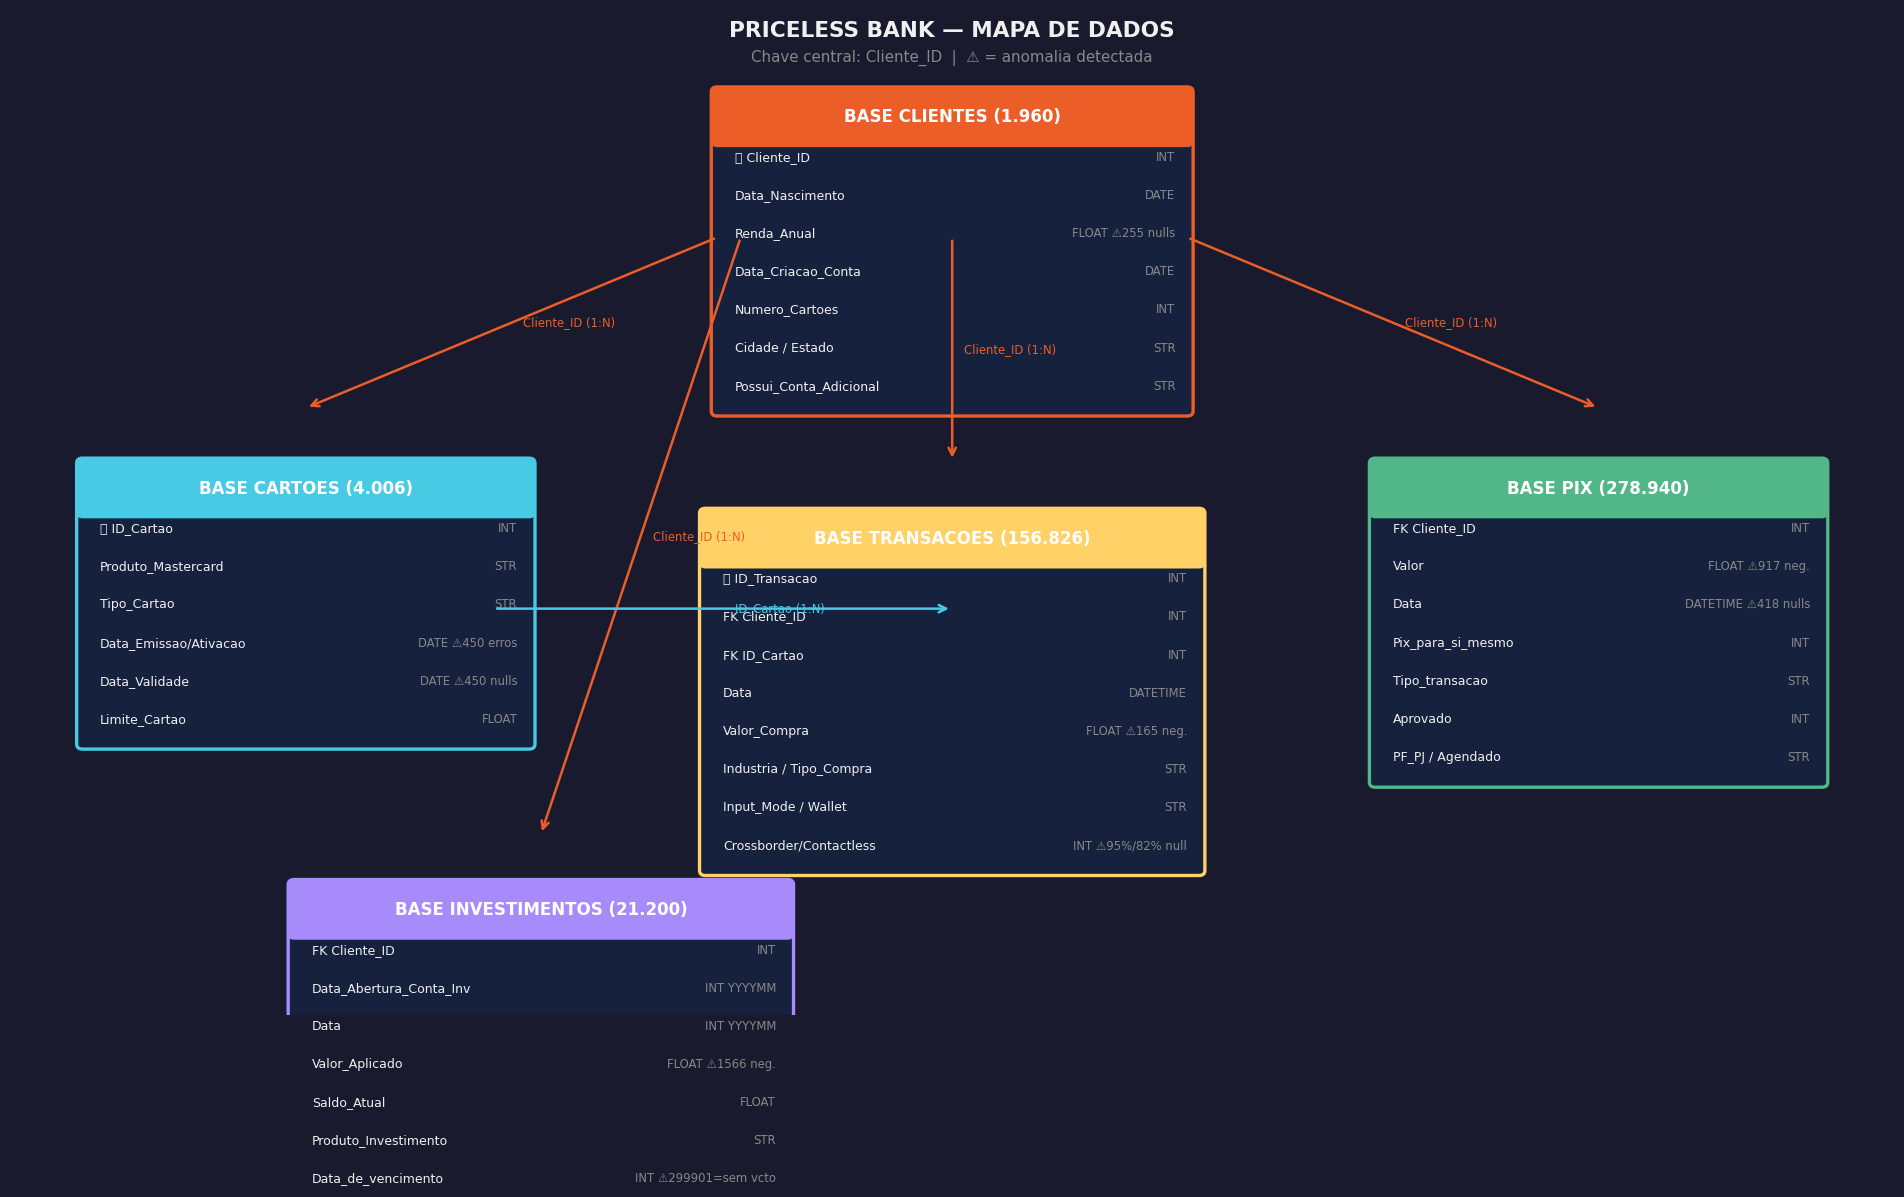

Schema salvo em docs/schema_banco_dados.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16); ax.set_ylim(0, 10); ax.axis('off')
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ORANGE='#eb5e28'; TEAL='#48cae4'; GREEN='#52b788'; YELLOW='#ffd166'; WHITE='#f0f0f0'; GRAY='#888888'

def draw_entity(ax, x, y, title, fields, color, width=3.2, row_h=0.38):
    h = 0.52 + len(fields) * row_h
    ax.add_patch(mpatches.FancyBboxPatch((x-width/2, y-h), width, h,
        boxstyle='round,pad=0.05', linewidth=2, edgecolor=color, facecolor='#16213e'))
    ax.add_patch(mpatches.FancyBboxPatch((x-width/2, y-0.5), width, 0.5,
        boxstyle='round,pad=0.05', linewidth=0, facecolor=color))
    ax.text(x, y-0.25, title, color='white', fontsize=10, fontweight='bold', ha='center', va='center')
    for i,(field,ftype) in enumerate(fields):
        yf = y - 0.65 - i*row_h
        ax.text(x-width/2+0.15, yf, field, color=WHITE, fontsize=7.5, va='center')
        ax.text(x+width/2-0.1,  yf, ftype, color=GRAY,  fontsize=7,   va='center', ha='right')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#aaaaaa'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1), arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label: ax.text((x1+x2)/2+0.1, (y1+y2)/2, label, color=color, fontsize=7, va='center')

draw_entity(ax, 8,    9.2, 'BASE CLIENTES (1.960)',
    [('🔑 Cliente_ID','INT'),('Data_Nascimento','DATE'),('Renda_Anual','FLOAT ⚠️255 nulls'),
     ('Data_Criacao_Conta','DATE'),('Numero_Cartoes','INT'),('Cidade / Estado','STR'),
     ('Possui_Conta_Adicional','STR')], ORANGE, width=4.0)

draw_entity(ax, 2.5,  5.5, 'BASE CARTOES (4.006)',
    [('🔑 ID_Cartao','INT'),('Produto_Mastercard','STR'),('Tipo_Cartao','STR'),
     ('Data_Emissao/Ativacao','DATE ⚠️450 erros'),('Data_Validade','DATE ⚠️450 nulls'),
     ('Limite_Cartao','FLOAT')], TEAL, width=3.8)

draw_entity(ax, 8,    5.0, 'BASE TRANSACOES (156.826)',
    [('🔑 ID_Transacao','INT'),('FK Cliente_ID','INT'),('FK ID_Cartao','INT'),('Data','DATETIME'),
     ('Valor_Compra','FLOAT ⚠️165 neg.'),('Industria / Tipo_Compra','STR'),
     ('Input_Mode / Wallet','STR'),('Crossborder/Contactless','INT ⚠️95%/82% null')], YELLOW, width=4.2)

draw_entity(ax, 13.5, 5.5, 'BASE PIX (278.940)',
    [('FK Cliente_ID','INT'),('Valor','FLOAT ⚠️917 neg.'),('Data','DATETIME ⚠️418 nulls'),
     ('Pix_para_si_mesmo','INT'),('Tipo_transacao','STR'),
     ('Aprovado','INT'),('PF_PJ / Agendado','STR')], GREEN, width=3.8)

draw_entity(ax, 4.5,  1.3, 'BASE INVESTIMENTOS (21.200)',
    [('FK Cliente_ID','INT'),('Data_Abertura_Conta_Inv','INT YYYYMM'),('Data','INT YYYYMM'),
     ('Valor_Aplicado','FLOAT ⚠️1566 neg.'),('Saldo_Atual','FLOAT'),
     ('Produto_Investimento','STR'),('Data_de_vencimento','INT ⚠️299901=sem vcto')], '#a78bfa', width=4.2)

draw_arrow(ax,  8,   7.75,  8,   5.52, 'Cliente_ID (1:N)', ORANGE)
draw_arrow(ax,  6.0, 7.75,  2.5, 6.05, 'Cliente_ID (1:N)', ORANGE)
draw_arrow(ax, 10.0, 7.75, 13.5, 6.05, 'Cliente_ID (1:N)', ORANGE)
draw_arrow(ax,  6.2, 7.75,  4.5, 1.8,  'Cliente_ID (1:N)', ORANGE)
draw_arrow(ax,  4.1, 4.05,  8.0, 4.05, 'ID_Cartao (1:N)',  TEAL)

ax.text(8, 9.75, 'PRICELESS BANK — MAPA DE DADOS', color=WHITE, fontsize=13, fontweight='bold', ha='center')
ax.text(8, 9.5,  'Chave central: Cliente_ID  |  ⚠️ = anomalia detectada', color=GRAY, fontsize=9, ha='center')
plt.tight_layout()
plt.savefig('docs/schema_banco_dados.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Schema salvo em docs/schema_banco_dados.png')

---
## 3. Cobertura dos Clientes por Base

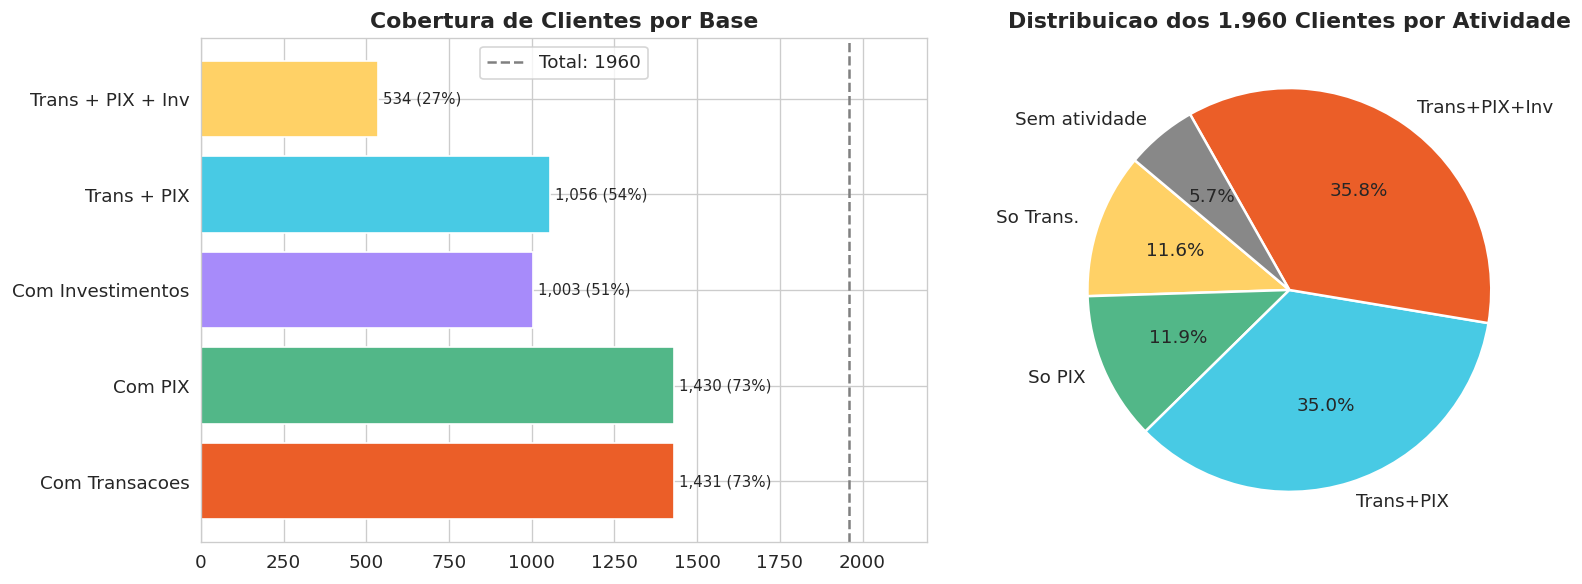

Clientes sem NENHUMA atividade: 85


In [6]:
total = base_clientes['Cliente_ID'].nunique()
s_tr  = set(base_transacoes['Cliente_ID'])
s_px  = set(base_pix['Cliente_ID'])
s_inv = set(base_investimentos['Cliente_ID'])
s_cli = set(base_clientes['Cliente_ID'])

cobertura = {'Com Transacoes': len(s_tr), 'Com PIX': len(s_px),
             'Com Investimentos': len(s_inv),
             'Trans + PIX': len(s_tr & s_px), 'Trans + PIX + Inv': len(s_tr & s_px & s_inv)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#eb5e28','#52b788','#a78bfa','#48cae4','#ffd166']
bars  = axes[0].barh(list(cobertura.keys()), list(cobertura.values()), color=cores, edgecolor='white')
axes[0].set_xlim(0, total * 1.12)
axes[0].axvline(total, color='gray', linestyle='--', label=f'Total: {total}')
for bar, v in zip(bars, cobertura.values()):
    axes[0].text(v+15, bar.get_y()+bar.get_height()/2, f'{v:,} ({v/total*100:.0f}%)', va='center', fontsize=9)
axes[0].set_title('Cobertura de Clientes por Base', fontweight='bold'); axes[0].legend()

sem_nada = len(s_cli - s_tr - s_px - s_inv)
vals_pie = [len(s_tr-s_px-s_inv), len(s_px-s_tr-s_inv), len((s_tr&s_px)-s_inv), len(s_tr&s_px&s_inv), sem_nada]
labs_pie = ['So Trans.','So PIX','Trans+PIX','Trans+PIX+Inv','Sem atividade']
axes[1].pie(vals_pie, labels=labs_pie, autopct='%1.1f%%', startangle=140,
            colors=['#ffd166','#52b788','#48cae4','#eb5e28','#888888'],
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Distribuicao dos 1.960 Clientes por Atividade', fontweight='bold')

plt.tight_layout(); plt.show()
print(f'Clientes sem NENHUMA atividade: {sem_nada}')

---
## 4. Base Clientes — Perfil Demográfico e Financeiro

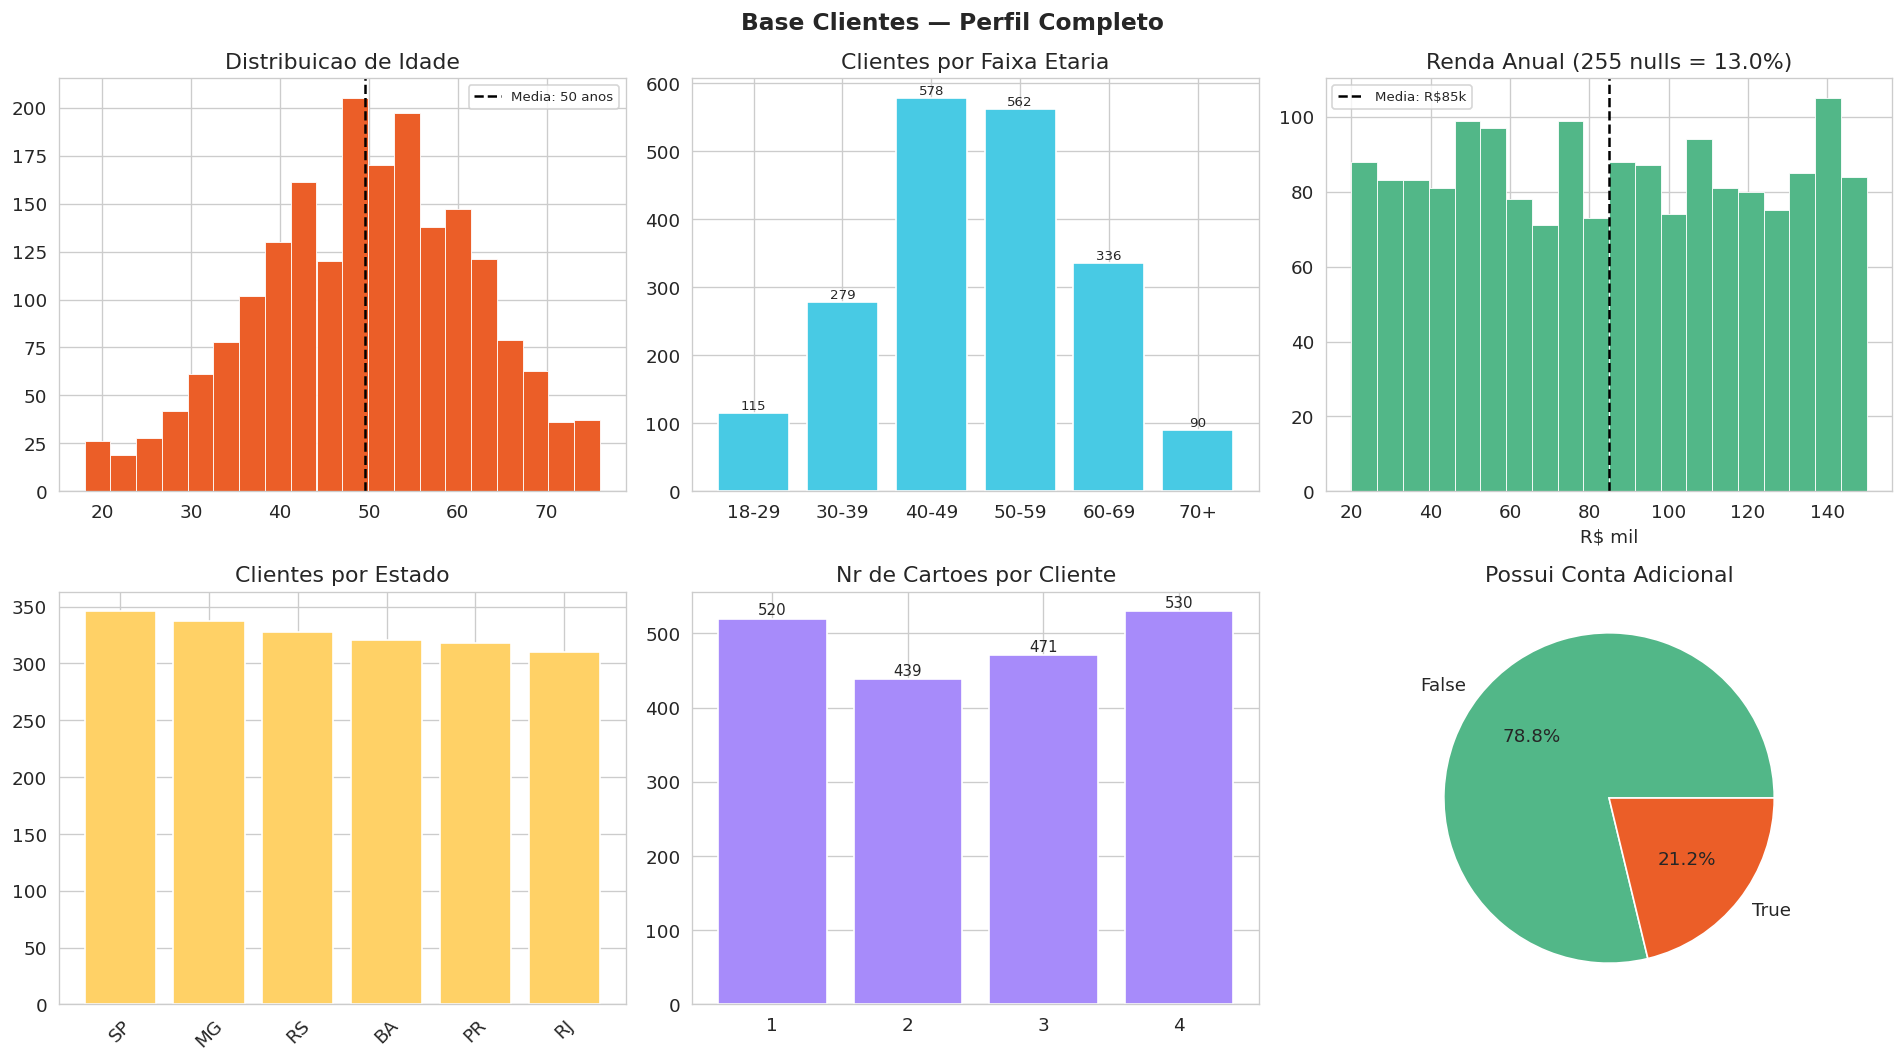

Idade media: 49.5 | Mediana: 50
Renda media: R$85,020 | Mediana: R$85,000


In [7]:
hoje = pd.Timestamp('2026-06-12')
base_clientes['Idade'] = ((hoje - base_clientes['Data_Nascimento']).dt.days / 365.25).astype(int)
base_clientes['Faixa_Etaria'] = pd.cut(base_clientes['Idade'],
    bins=[18,30,40,50,60,70,80], labels=['18-29','30-39','40-49','50-59','60-69','70+'], right=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Base Clientes — Perfil Completo', fontsize=14, fontweight='bold')

axes[0,0].hist(base_clientes['Idade'], bins=20, color='#eb5e28', edgecolor='white', linewidth=0.5)
axes[0,0].axvline(base_clientes['Idade'].mean(), color='black', linestyle='--',
                  label=f'Media: {base_clientes["Idade"].mean():.0f} anos')
axes[0,0].set_title('Distribuicao de Idade'); axes[0,0].legend(fontsize=8)

fc = base_clientes['Faixa_Etaria'].value_counts().sort_index()
axes[0,1].bar(fc.index, fc.values, color='#48cae4', edgecolor='white')
axes[0,1].set_title('Clientes por Faixa Etaria')
for i,v in enumerate(fc.values): axes[0,1].text(i, v+5, str(v), ha='center', fontsize=8)

renda = base_clientes['Renda_Anual'].dropna()
axes[0,2].hist(renda/1000, bins=20, color='#52b788', edgecolor='white', linewidth=0.5)
axes[0,2].axvline(renda.mean()/1000, color='black', linestyle='--', label=f'Media: R${renda.mean()/1000:.0f}k')
axes[0,2].set_title(f'Renda Anual (255 nulls = {255/1960*100:.1f}%)'); axes[0,2].legend(fontsize=8)
axes[0,2].set_xlabel('R$ mil')

ec = base_clientes['Estado'].value_counts()
axes[1,0].bar(ec.index, ec.values, color='#ffd166', edgecolor='white')
axes[1,0].set_title('Clientes por Estado'); axes[1,0].tick_params(axis='x', rotation=45)

nc = base_clientes['Numero_Cartoes'].value_counts().sort_index()
axes[1,1].bar(nc.index.astype(str), nc.values, color='#a78bfa', edgecolor='white')
axes[1,1].set_title('Nr de Cartoes por Cliente')
for i,v in enumerate(nc.values): axes[1,1].text(i, v+5, str(v), ha='center', fontsize=9)

ca = base_clientes['Possui_Conta_Adicional'].value_counts()
axes[1,2].pie(ca.values, labels=ca.index, autopct='%1.1f%%',
              colors=['#52b788','#eb5e28'], wedgeprops={'edgecolor':'white'})
axes[1,2].set_title('Possui Conta Adicional')

plt.tight_layout(); plt.show()
print(f'Idade media: {base_clientes["Idade"].mean():.1f} | Mediana: {base_clientes["Idade"].median():.0f}')
print(f'Renda media: R${renda.mean():,.0f} | Mediana: R${renda.median():,.0f}')

---
## 5. Base Cartões — Portfolio e Anomalias

=== ANOMALIAS ===
[!] Ativados ANTES da emissao: 450 (11.2%)
    Sao EXATAMENTE os mesmos sem Data_Validade: True
[!] Cartoes vencidos: 1017 de 3556
[!] Cartoes sem nenhuma transacao: 469 (11.7%) — baixo engajamento


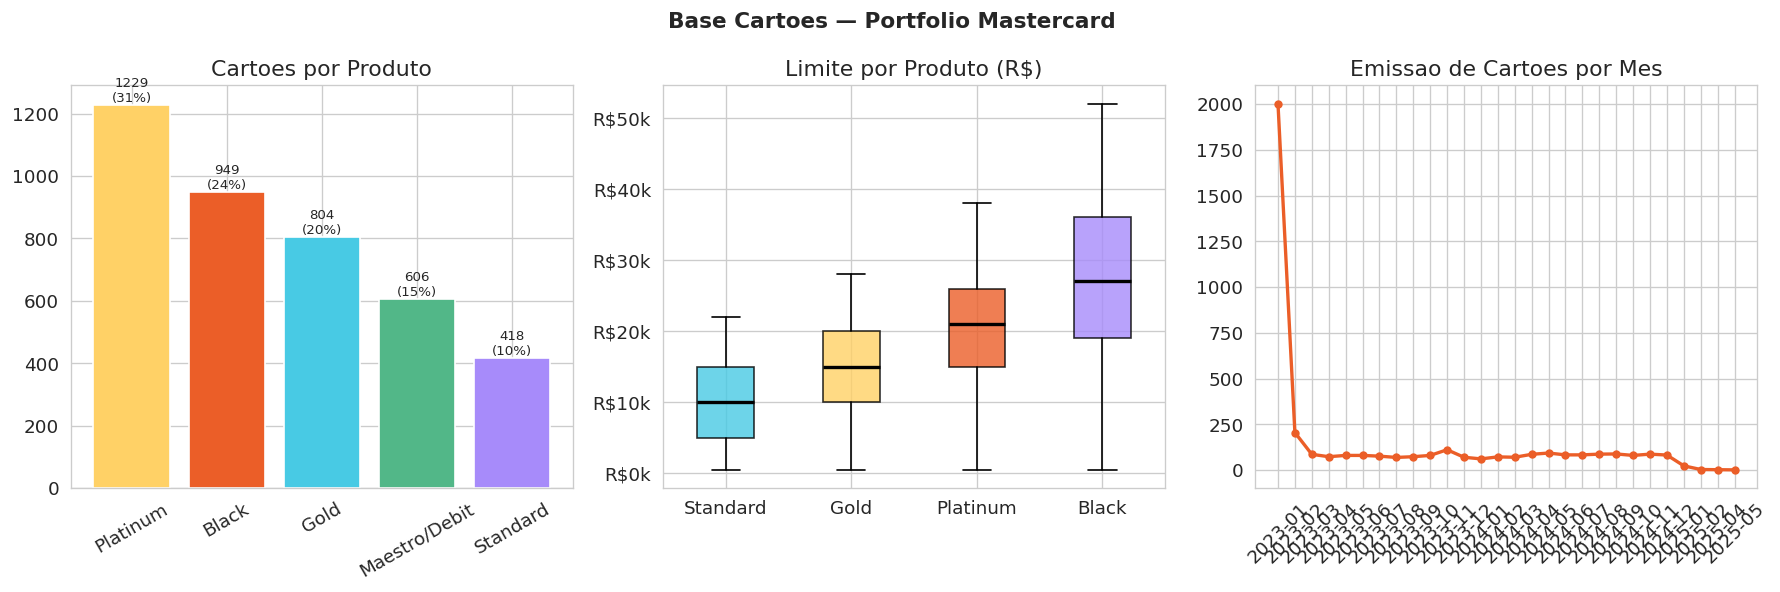

Limite medio: R$19,024 | Mediano: R$19,000


In [8]:
hoje = pd.Timestamp('2026-06-12')
ativ_antes = base_cartoes[base_cartoes['Data_Ativacao'] < base_cartoes['Data_Emissao']]
sem_val    = base_cartoes[base_cartoes['Data_Validade'].isnull()]
vencidos   = base_cartoes[base_cartoes['Data_Validade'].notna() & (base_cartoes['Data_Validade'] < hoje)]
inativos   = set(base_cartoes['ID_Cartao']) - set(base_transacoes['ID_Cartao'])

print('=== ANOMALIAS ===')
print(f'[!] Ativados ANTES da emissao: {len(ativ_antes)} ({len(ativ_antes)/len(base_cartoes)*100:.1f}%)')
print(f'    Sao EXATAMENTE os mesmos sem Data_Validade: {len(set(ativ_antes["ID_Cartao"]) & set(sem_val["ID_Cartao"])) == 450}')
print(f'[!] Cartoes vencidos: {len(vencidos)} de {base_cartoes["Data_Validade"].notna().sum()}')
print(f'[!] Cartoes sem nenhuma transacao: {len(inativos)} ({len(inativos)/len(base_cartoes)*100:.1f}%) — baixo engajamento')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Base Cartoes — Portfolio Mastercard', fontsize=13, fontweight='bold')

prod  = base_cartoes['Produto_Mastercard'].value_counts()
cores = ['#ffd166','#eb5e28','#48cae4','#52b788','#a78bfa']
bars  = axes[0].bar(prod.index, prod.values, color=cores, edgecolor='white')
axes[0].set_title('Cartoes por Produto'); axes[0].tick_params(axis='x', rotation=30)
for bar,v in zip(bars,prod.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+10, f'{v}\n({v/len(base_cartoes)*100:.0f}%)', ha='center', fontsize=8)

credito    = base_cartoes[base_cartoes['Limite_Cartao'] > 0]
ordem      = ['Standard','Gold','Platinum','Black']
dados_box  = [credito[credito['Produto_Mastercard']==p]['Limite_Cartao'].values for p in ordem]
bp = axes[1].boxplot(dados_box, labels=ordem, patch_artist=True, medianprops={'color':'black','linewidth':2})
for patch,cor in zip(bp['boxes'],['#48cae4','#ffd166','#eb5e28','#a78bfa']):
    patch.set_facecolor(cor); patch.set_alpha(0.8)
axes[1].set_title('Limite por Produto (R$)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))

base_cartoes['Mes_Emissao'] = base_cartoes['Data_Emissao'].dt.to_period('M')
em = base_cartoes.groupby('Mes_Emissao').size()
axes[2].plot(em.index.astype(str), em.values, color='#eb5e28', linewidth=2, marker='o', markersize=4)
axes[2].set_title('Emissao de Cartoes por Mes'); axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()
print(f'Limite medio: R${credito["Limite_Cartao"].mean():,.0f} | Mediano: R${credito["Limite_Cartao"].median():,.0f}')

---
## 6. Base Transações — Comportamento de Consumo
### ⭐ Base mais crítica para o diagnóstico

=== ANOMALIAS ===
[!] Crossborder NULL: 95.6% — por design: so em CNP online
[!] Contactless NULL: 82.5% — por design: so em fisico
[!] Valores negativos (estornos?): 165
[!] Outliers > R$10k: 84 (max: R$107,778)


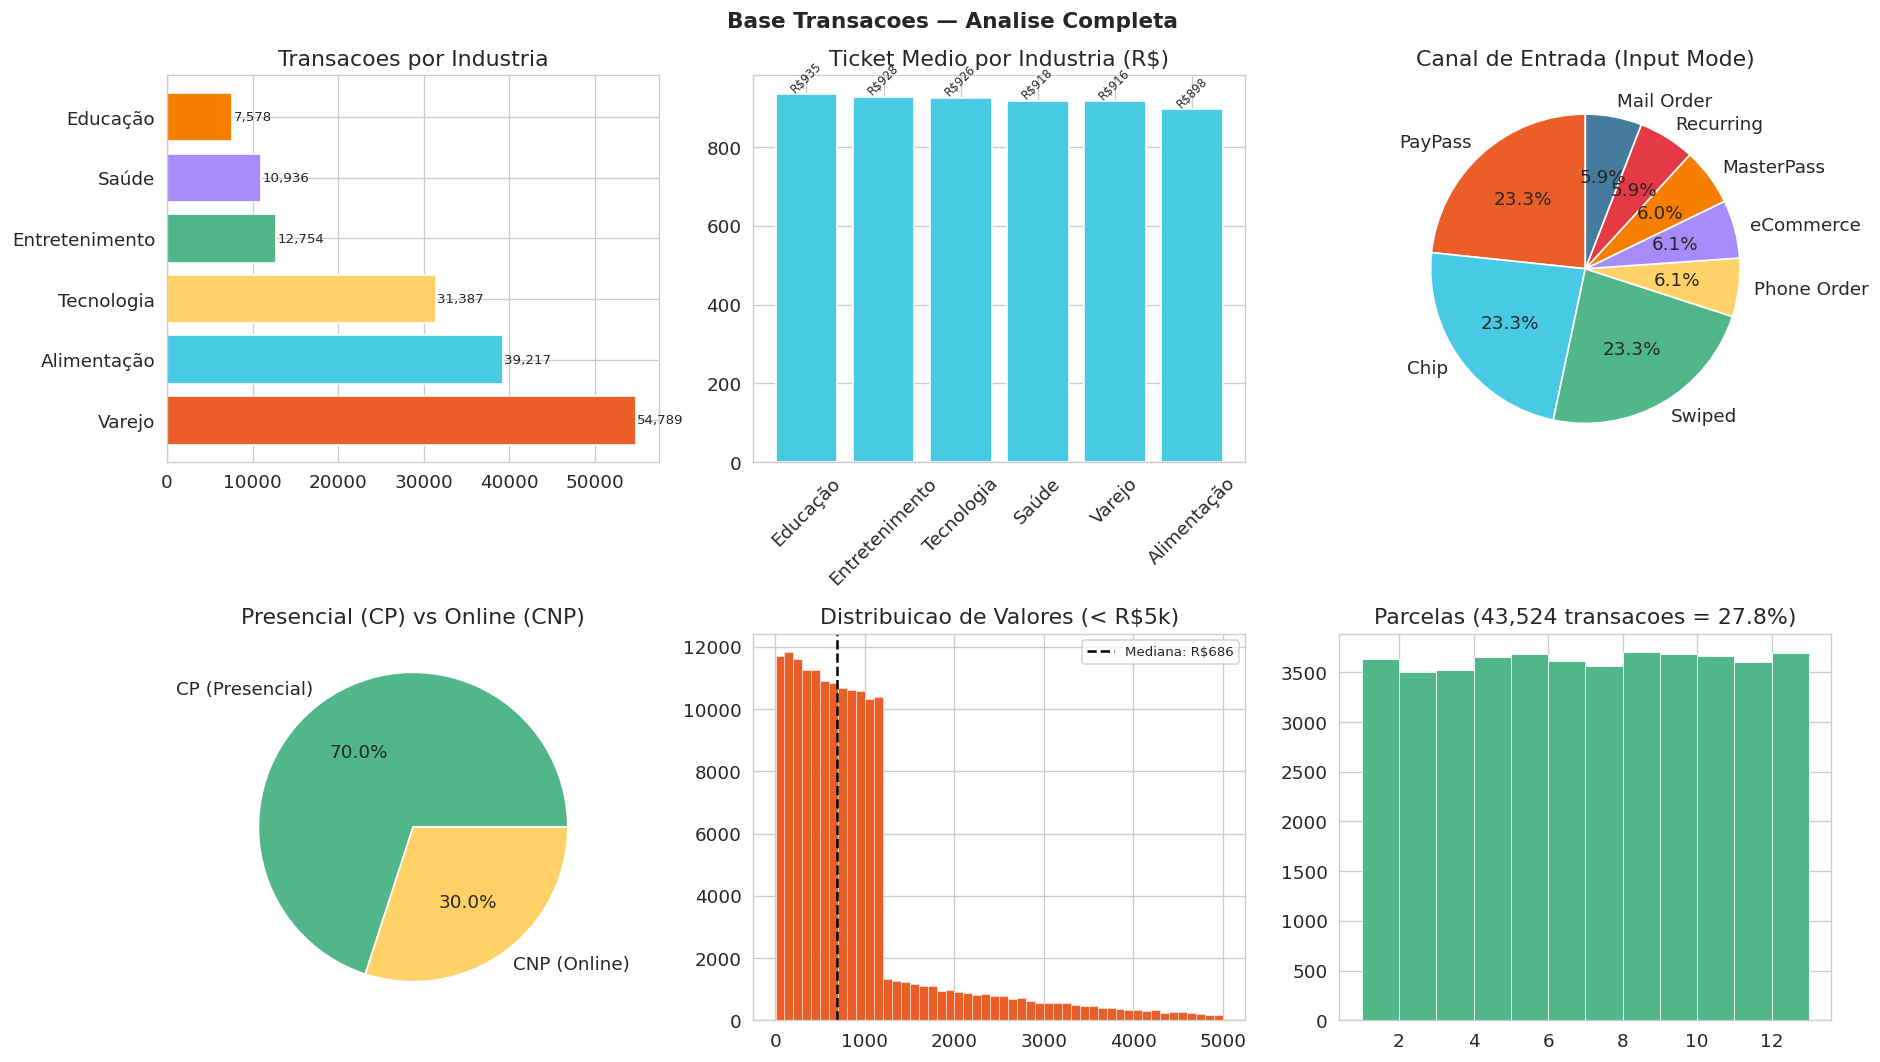

Ticket medio: R$915 | Mediana: R$690
Top industria: Varejo (54,789) | Maior ticket: Educação (R$935)


In [9]:
print('=== ANOMALIAS ===')
print(f'[!] Crossborder NULL: {base_transacoes["Crossborder"].isnull().mean()*100:.1f}% — por design: so em CNP online')
print(f'[!] Contactless NULL: {base_transacoes["Contactless"].isnull().mean()*100:.1f}% — por design: so em fisico')
print(f'[!] Valores negativos (estornos?): {(base_transacoes["Valor_Compra"]<0).sum()}')
print(f'[!] Outliers > R$10k: {(base_transacoes["Valor_Compra"]>10000).sum()} (max: R${base_transacoes["Valor_Compra"].max():,.0f})')

tr = base_transacoes[base_transacoes['Valor_Compra'] > 0]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Base Transacoes — Analise Completa', fontsize=13, fontweight='bold')

ind   = tr['Industria'].value_counts()
cores = ['#eb5e28','#48cae4','#ffd166','#52b788','#a78bfa','#f77f00']
bars  = axes[0,0].barh(ind.index, ind.values, color=cores, edgecolor='white')
axes[0,0].set_title('Transacoes por Industria')
for bar,v in zip(bars,ind.values):
    axes[0,0].text(v+200, bar.get_y()+bar.get_height()/2, f'{v:,}', va='center', fontsize=8)

vm = tr.groupby('Industria')['Valor_Compra'].mean().sort_values(ascending=False)
b2 = axes[0,1].bar(vm.index, vm.values, color='#48cae4', edgecolor='white')
axes[0,1].set_title('Ticket Medio por Industria (R$)'); axes[0,1].tick_params(axis='x', rotation=45)
for bar,v in zip(b2,vm.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+5, f'R${v:,.0f}', ha='center', fontsize=7, rotation=45)

im = tr['Input_Mode'].value_counts()
axes[0,2].pie(im.values, labels=im.index, autopct='%1.1f%%', startangle=90,
              colors=['#eb5e28','#48cae4','#52b788','#ffd166','#a78bfa','#f77f00','#e63946','#457b9d'],
              wedgeprops={'edgecolor':'white'})
axes[0,2].set_title('Canal de Entrada (Input Mode)')

tc = tr['Tipo_Compra'].value_counts()
axes[1,0].pie(tc.values, labels=['CP (Presencial)','CNP (Online)'],
              autopct='%1.1f%%', colors=['#52b788','#ffd166'], wedgeprops={'edgecolor':'white'})
axes[1,0].set_title('Presencial (CP) vs Online (CNP)')

tso = tr[tr['Valor_Compra'] < 5000]
axes[1,1].hist(tso['Valor_Compra'], bins=50, color='#eb5e28', edgecolor='white', linewidth=0.3)
axes[1,1].axvline(tso['Valor_Compra'].median(), color='black', linestyle='--',
                  label=f'Mediana: R${tso["Valor_Compra"].median():.0f}')
axes[1,1].set_title('Distribuicao de Valores (< R$5k)'); axes[1,1].legend(fontsize=8)

parc = tr['Qtd_Parcelas'].dropna()
axes[1,2].hist(parc, bins=12, range=(1,13), color='#52b788', edgecolor='white', linewidth=0.5)
axes[1,2].set_title(f'Parcelas ({len(parc):,} transacoes = {len(parc)/len(tr)*100:.1f}%)')

plt.tight_layout(); plt.show()
print(f'Ticket medio: R${tr["Valor_Compra"].mean():,.0f} | Mediana: R${tr["Valor_Compra"].median():,.0f}')
print(f'Top industria: {ind.index[0]} ({ind.iloc[0]:,}) | Maior ticket: {vm.index[0]} (R${vm.iloc[0]:,.0f})')

---
## 7. Base PIX — Comportamento de Transferências
### ⭐ Segunda base mais crítica — evidência de canibalização do cartão

=== ANOMALIAS ===
[!] Valores negativos: 917 — PIX negativo e incoerente
[!] Valores zero: 591 — PIX de R$0,00
[!] Data/Tipo nulos: 418 registros incompletos
[!] Recebimentos negados (Aprovado=0): 3,392
[!] Envios nao aprovados: 24,644 (10.0%) — taxa alta


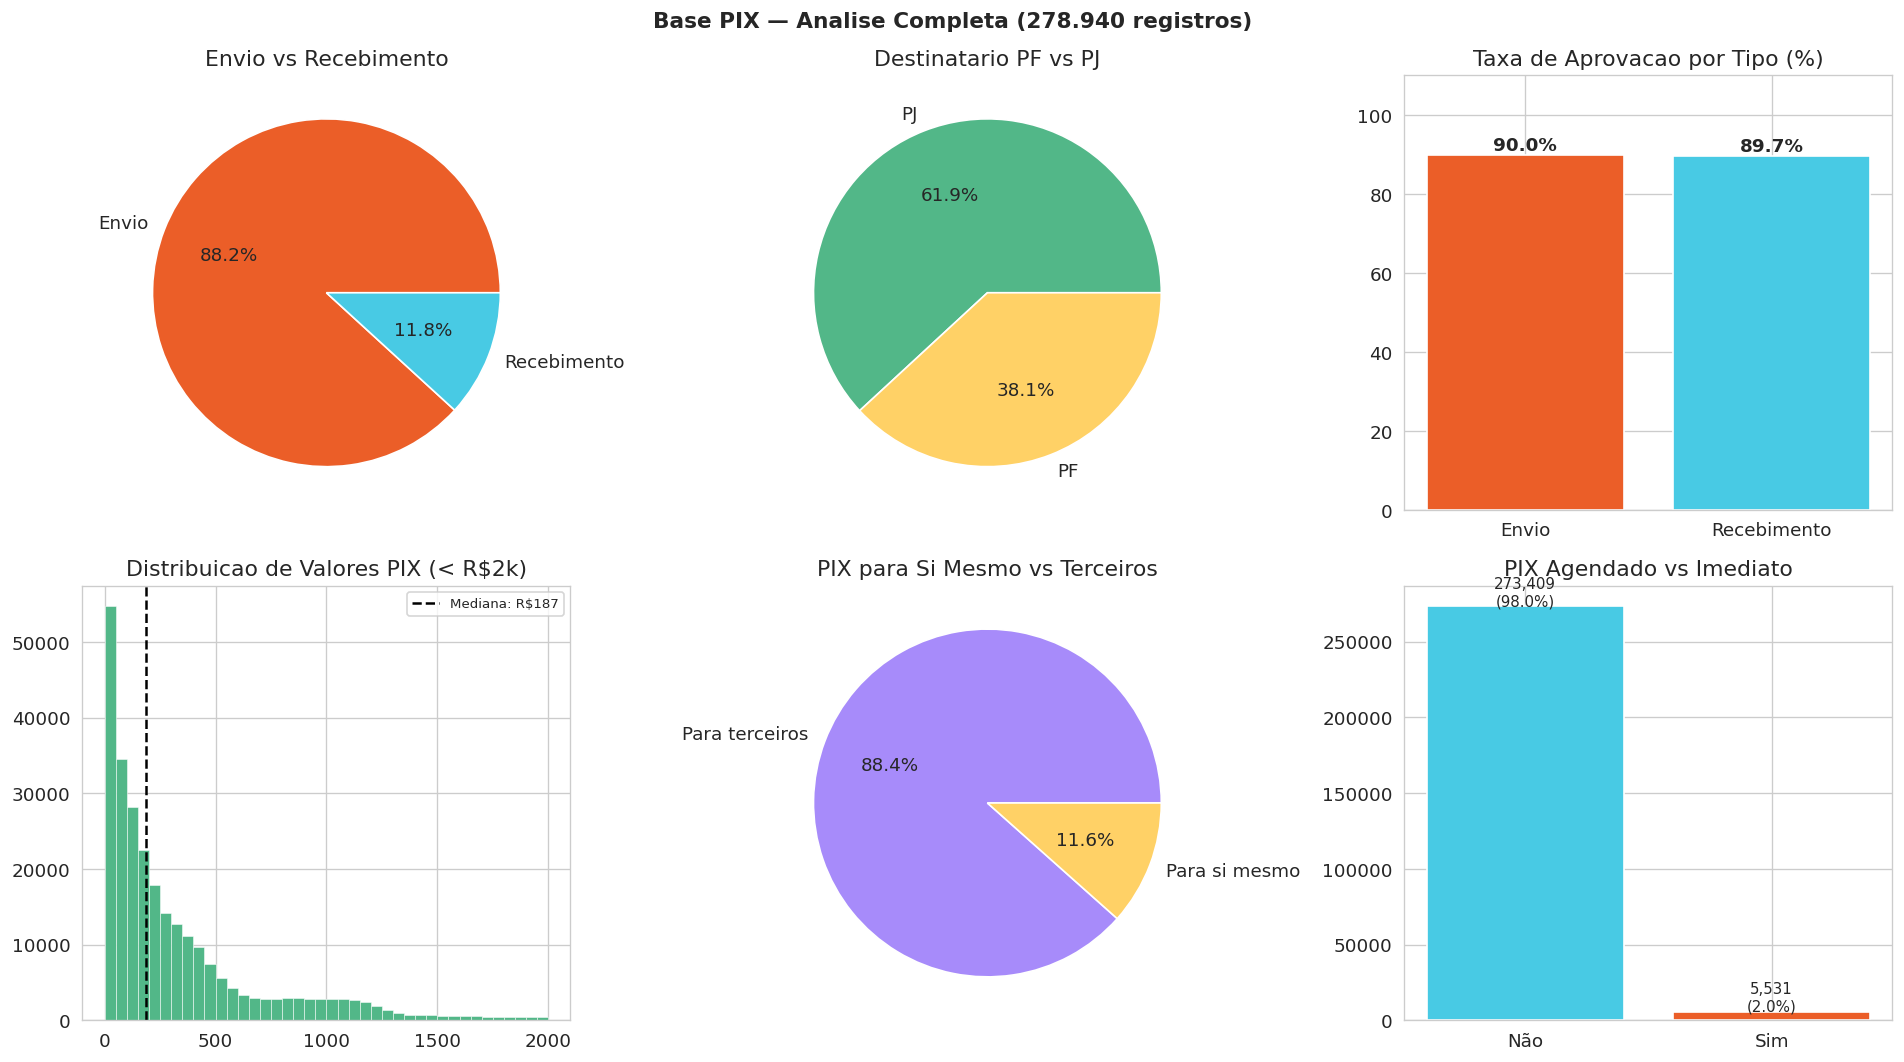

Valor medio PIX (positivos): R$424 | Mediana: R$197
62% dos PIX sao para PJ: clientes pagando em comercios via PIX em vez de cartao


In [10]:
env_naprov = len(base_pix[(base_pix['Tipo_transacao']=='Envio') & (base_pix['Aprovado']==0)])
tot_env    = base_pix['Tipo_transacao'].value_counts().get('Envio', 1)
print('=== ANOMALIAS ===')
print(f'[!] Valores negativos: {(base_pix["Valor"]<0).sum()} — PIX negativo e incoerente')
print(f'[!] Valores zero: {(base_pix["Valor"]==0).sum()} — PIX de R$0,00')
print(f'[!] Data/Tipo nulos: {base_pix["Data"].isnull().sum()} registros incompletos')
print(f'[!] Recebimentos negados (Aprovado=0): {len(base_pix[(base_pix["Tipo_transacao"]=="Recebimento") & (base_pix["Aprovado"]==0)]):,}')
print(f'[!] Envios nao aprovados: {env_naprov:,} ({env_naprov/tot_env*100:.1f}%) — taxa alta')

pix_ok = base_pix[base_pix['Valor'] > 0].dropna(subset=['Data','Tipo_transacao'])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Base PIX — Analise Completa (278.940 registros)', fontsize=13, fontweight='bold')

tt = base_pix['Tipo_transacao'].value_counts()
axes[0,0].pie(tt.values, labels=tt.index, autopct='%1.1f%%',
              colors=['#eb5e28','#48cae4'], wedgeprops={'edgecolor':'white'})
axes[0,0].set_title('Envio vs Recebimento')

pfpj = base_pix['PF_PJ'].value_counts()
axes[0,1].pie(pfpj.values, labels=pfpj.index, autopct='%1.1f%%',
              colors=['#52b788','#ffd166'], wedgeprops={'edgecolor':'white'})
axes[0,1].set_title('Destinatario PF vs PJ')

aprov = base_pix.groupby('Tipo_transacao')['Aprovado'].mean() * 100
axes[0,2].bar(aprov.index, aprov.values, color=['#eb5e28','#48cae4'], edgecolor='white')
axes[0,2].set_ylim(0, 110); axes[0,2].set_title('Taxa de Aprovacao por Tipo (%)')
for i,v in enumerate(aprov.values): axes[0,2].text(i, v+1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

pso = pix_ok[pix_ok['Valor'] < 2000]
axes[1,0].hist(pso['Valor'], bins=40, color='#52b788', edgecolor='white', linewidth=0.3)
axes[1,0].axvline(pso['Valor'].median(), color='black', linestyle='--',
                  label=f'Mediana: R${pso["Valor"].median():.0f}')
axes[1,0].set_title('Distribuicao de Valores PIX (< R$2k)'); axes[1,0].legend(fontsize=8)

psm = base_pix['Pix_para_si_mesmo'].value_counts()
axes[1,1].pie(psm.values, labels=['Para terceiros','Para si mesmo'],
              autopct='%1.1f%%', colors=['#a78bfa','#ffd166'], wedgeprops={'edgecolor':'white'})
axes[1,1].set_title('PIX para Si Mesmo vs Terceiros')

ag = base_pix['Agendado'].value_counts()
axes[1,2].bar(ag.index, ag.values, color=['#48cae4','#eb5e28'], edgecolor='white')
axes[1,2].set_title('PIX Agendado vs Imediato')
for i,v in enumerate(ag.values): axes[1,2].text(i, v+500, f'{v:,}\n({v/len(base_pix)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout(); plt.show()
print(f'Valor medio PIX (positivos): R${pix_ok["Valor"].mean():,.0f} | Mediana: R${pix_ok["Valor"].median():,.0f}')
print('62% dos PIX sao para PJ: clientes pagando em comercios via PIX em vez de cartao')

---
## 8. Base Investimentos — Carteira e Comportamento

=== NOTAS (comportamento esperado, nao sao erros) ===
[i] Valor_Aplicado negativo: 1,566 — sao RESGATES
[i] Data_vencimento=299901: 7,864 — Reservinha sem vencimento (esperado)
[i] Saldo_Atual=0: 2,551 — produto vencido ou resgatado
[i] Datas em formato YYYYMM inteiro: int64
[i] Clientes com investimento: 1003 (51.2% da base)


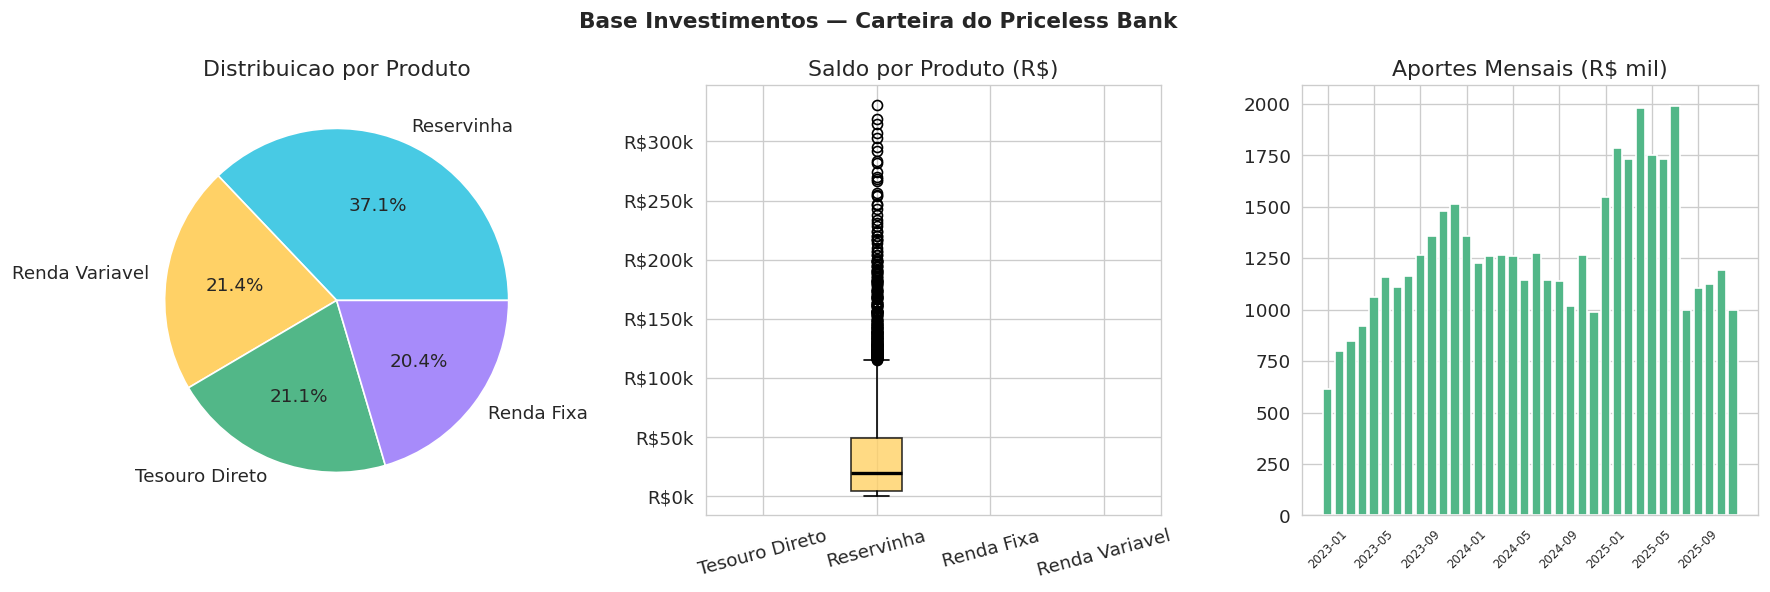


Saldo por produto:
                     Saldo Medio Saldo Total  Registros
Produto_Investimento                                   
Renda Fixa              R$17,248     R$74.6M       4324
Renda Variavel          R$12,352     R$56.0M       4531
Reservinha              R$31,722    R$249.5M       7864
Tesouro Direto          R$13,298     R$59.4M       4467


In [11]:
print('=== NOTAS (comportamento esperado, nao sao erros) ===')
print(f'[i] Valor_Aplicado negativo: {(base_investimentos["Valor_Aplicado"]<0).sum():,} — sao RESGATES')
print(f'[i] Data_vencimento=299901: {(base_investimentos["Data_de_vencimento"]==299901).sum():,} — Reservinha sem vencimento (esperado)')
print(f'[i] Saldo_Atual=0: {(base_investimentos["Saldo_Atual"]==0).sum():,} — produto vencido ou resgatado')
print(f'[i] Datas em formato YYYYMM inteiro: {base_investimentos["Data"].dtype}')
print(f'[i] Clientes com investimento: {base_investimentos["Cliente_ID"].nunique()} ({base_investimentos["Cliente_ID"].nunique()/1960*100:.1f}% da base)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Base Investimentos — Carteira do Priceless Bank', fontsize=13, fontweight='bold')

pi = base_investimentos['Produto_Investimento'].value_counts()
axes[0].pie(pi.values, labels=pi.index, autopct='%1.1f%%',
            colors=['#48cae4','#ffd166','#52b788','#a78bfa'], wedgeprops={'edgecolor':'white'})
axes[0].set_title('Distribuicao por Produto')

prods = base_investimentos['Produto_Investimento'].unique()
ds    = [base_investimentos[base_investimentos['Produto_Investimento']==p]['Saldo_Atual'].values for p in prods]
bp = axes[1].boxplot(ds, labels=prods, patch_artist=True, medianprops={'color':'black','linewidth':2})
for patch,cor in zip(bp['boxes'],['#48cae4','#ffd166','#52b788','#a78bfa']):
    patch.set_facecolor(cor); patch.set_alpha(0.8)
axes[1].set_title('Saldo por Produto (R$)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
axes[1].tick_params(axis='x', rotation=15)

im = base_investimentos[base_investimentos['Valor_Aplicado'] > 0].copy()
im['ds'] = im['Data'].astype(str)
im = im[im['ds'].str[:4].astype(int).between(2023,2025) & im['ds'].str[4:].astype(int).between(1,12)]
im['Period'] = im['ds'].apply(lambda x: f'{x[:4]}-{x[4:]}')
ap = im.groupby('Period')['Valor_Aplicado'].sum().sort_index()
axes[2].bar(range(len(ap)), ap.values/1000, color='#52b788', edgecolor='white')
step = max(1, len(ap)//8)
axes[2].set_xticks(range(0,len(ap),step))
axes[2].set_xticklabels(ap.index[::step], rotation=45, fontsize=7)
axes[2].set_title('Aportes Mensais (R$ mil)')

plt.tight_layout(); plt.show()

sp = base_investimentos.groupby('Produto_Investimento')['Saldo_Atual'].agg(['mean','sum','count'])
sp.columns = ['Saldo Medio','Saldo Total','Registros']
sp['Saldo Total'] = sp['Saldo Total'].apply(lambda x: f'R${x/1e6:.1f}M')
sp['Saldo Medio'] = sp['Saldo Medio'].apply(lambda x: f'R${x:,.0f}')
print('\nSaldo por produto:'); print(sp)

---
## 9. Análise Temporal — O Sinal Mais Crítico do Diagnóstico

Evolução trimestral do volume transacionado por cartão vs PIX.

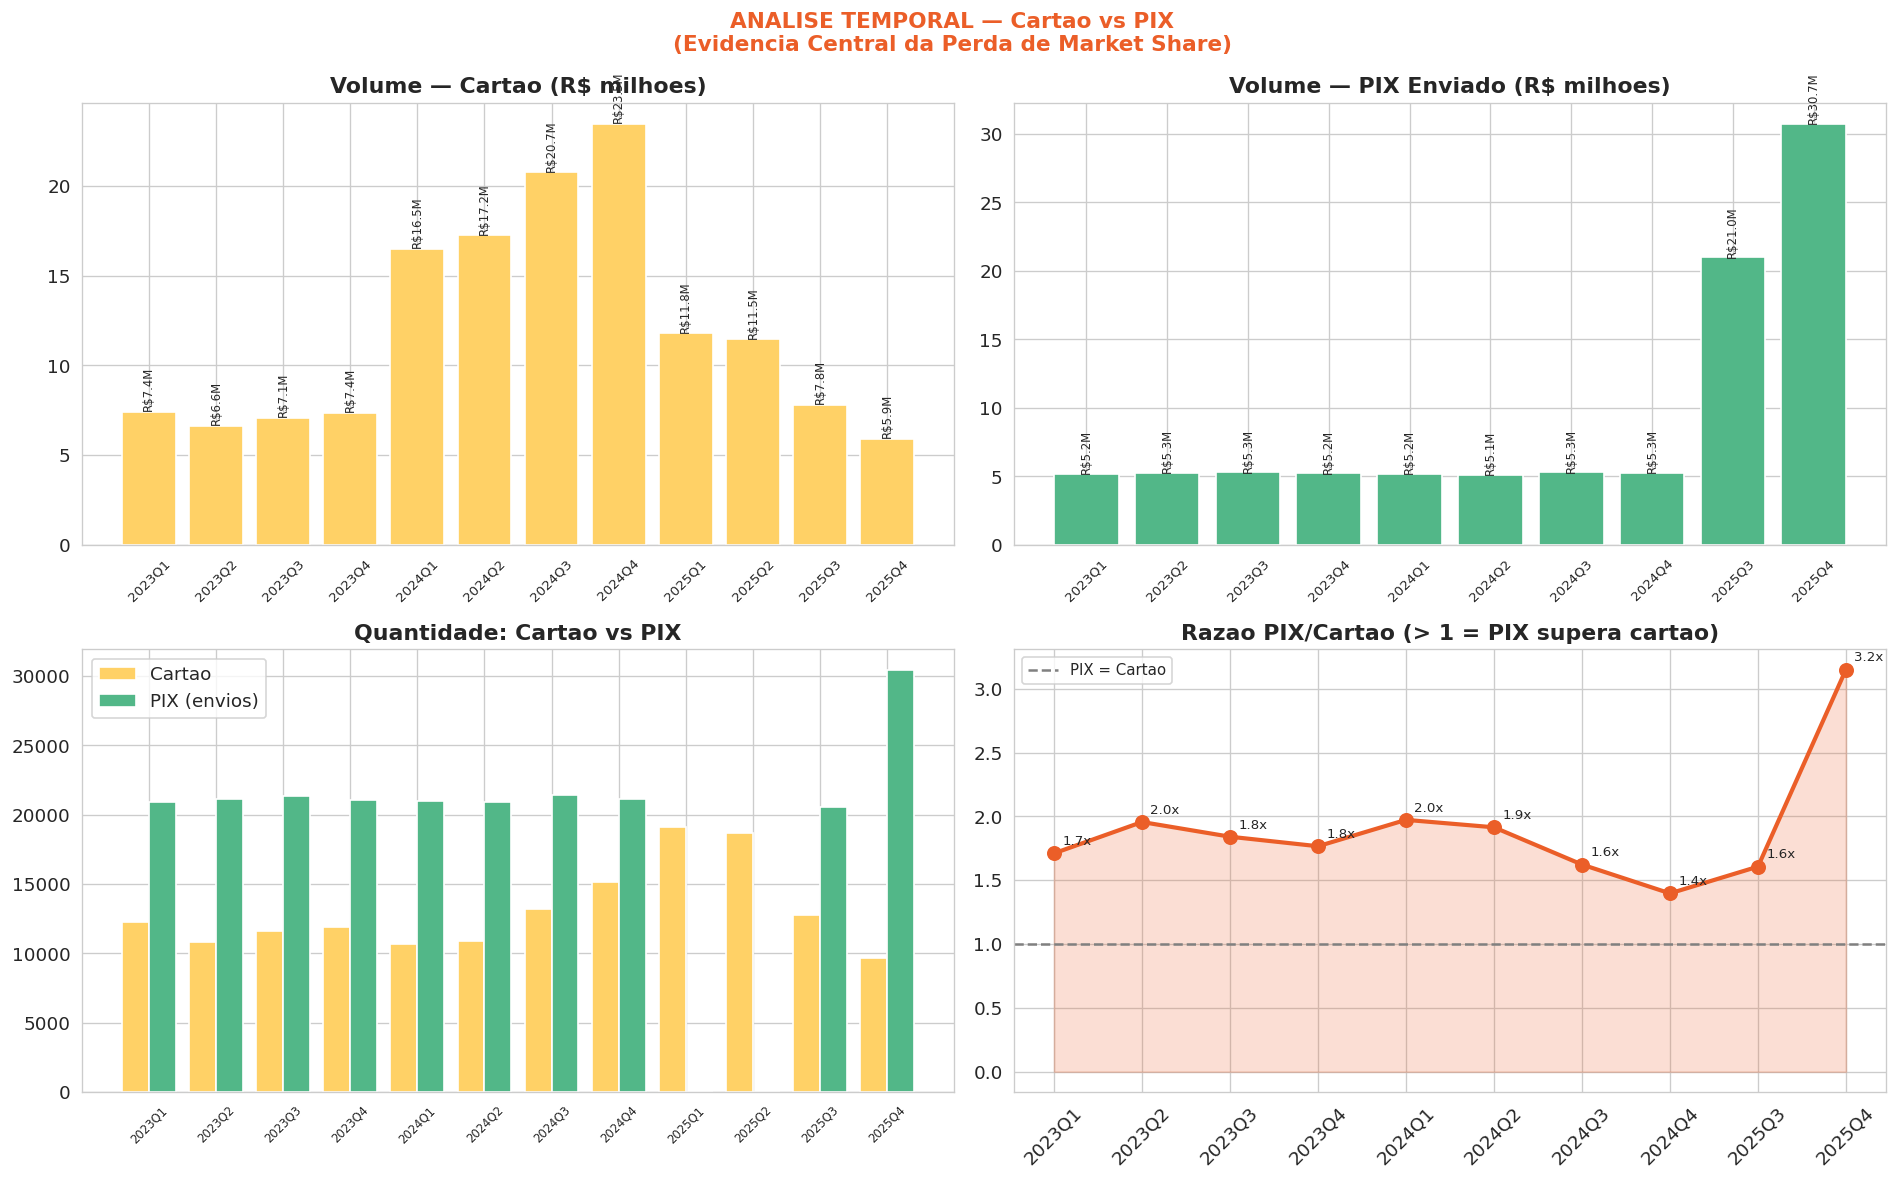


=== ACHADO CRITICO ===
Cartao: R$23.5M (2024Q4) -> R$5.9M (2025Q4) = queda de 75%
PIX:    R$5.3M (2024Q4) -> R$30.7M (2025Q4) = crescimento de 485%


In [12]:
base_transacoes['YQ'] = base_transacoes['Data'].dt.to_period('Q')
pix2 = pix_clean.copy()  # pix_clean: Valor>0, Data notna, Aprovado=1 (plano-limpeza P1-P4)

anos = ['2023','2024','2025']
tq = base_transacoes[base_transacoes['Valor_Compra']>0].groupby('YQ').agg(
    Volume=('Valor_Compra','sum'), Qtd=('Valor_Compra','count')).reset_index()
tq = tq[tq['YQ'].astype(str).str[:4].isin(anos)]

pq = pix2[pix2['Tipo_transacao']=='Envio'].groupby('YQ').agg(
    Volume=('Valor','sum'), Qtd=('Valor','count')).reset_index()
pq = pq[pq['YQ'].astype(str).str[:4].isin(anos)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ANALISE TEMPORAL — Cartao vs PIX\n(Evidencia Central da Perda de Market Share)',
             fontsize=13, fontweight='bold', color='#eb5e28')

xs = range(len(tq))
bt = axes[0,0].bar(xs, tq['Volume']/1e6, color='#ffd166', edgecolor='white')
axes[0,0].set_title('Volume — Cartao (R$ milhoes)', fontweight='bold')
axes[0,0].set_xticks(xs); axes[0,0].set_xticklabels(tq['YQ'].astype(str), rotation=45, fontsize=8)
for bar,v in zip(bt,tq['Volume']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'R${v/1e6:.1f}M', ha='center', fontsize=7, rotation=90)

xs2 = range(len(pq))
bp2 = axes[0,1].bar(xs2, pq['Volume']/1e6, color='#52b788', edgecolor='white')
axes[0,1].set_title('Volume — PIX Enviado (R$ milhoes)', fontweight='bold')
axes[0,1].set_xticks(xs2); axes[0,1].set_xticklabels(pq['YQ'].astype(str), rotation=45, fontsize=8)
for bar,v in zip(bp2,pq['Volume']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'R${v/1e6:.1f}M', ha='center', fontsize=7, rotation=90)

all_p  = sorted(set(tq['YQ'].astype(str)) | set(pq['YQ'].astype(str)))
tqd    = dict(zip(tq['YQ'].astype(str), tq['Qtd']))
pqd    = dict(zip(pq['YQ'].astype(str), pq['Qtd']))
x = np.arange(len(all_p)); w = 0.4
axes[1,0].bar(x-w/2, [tqd.get(p,0) for p in all_p], w, label='Cartao', color='#ffd166', edgecolor='white')
axes[1,0].bar(x+w/2, [pqd.get(p,0) for p in all_p], w, label='PIX (envios)', color='#52b788', edgecolor='white')
axes[1,0].set_title('Quantidade: Cartao vs PIX', fontweight='bold')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(all_p, rotation=45, fontsize=7); axes[1,0].legend()

pc   = [p for p in all_p if p in tqd and p in pqd]
razao = [pqd[p]/tqd[p] for p in pc]
axes[1,1].plot(pc, razao, color='#eb5e28', linewidth=2.5, marker='o', markersize=8)
axes[1,1].fill_between(pc, razao, alpha=0.2, color='#eb5e28')
axes[1,1].axhline(1.0, color='gray', linestyle='--', label='PIX = Cartao')
axes[1,1].set_title('Razao PIX/Cartao (> 1 = PIX supera cartao)', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45); axes[1,1].legend(fontsize=9)
for p,r in zip(pc,razao): axes[1,1].annotate(f'{r:.1f}x',(p,r), xytext=(5,5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.savefig('docs/analise_temporal_cartao_pix.png', dpi=130, bbox_inches='tight')
plt.show()

v_c24 = tq[tq['YQ'].astype(str)=='2024Q4']['Volume']
v_c25 = tq[tq['YQ'].astype(str)=='2025Q4']['Volume']
v_p24 = pq[pq['YQ'].astype(str)=='2024Q4']['Volume']
v_p25 = pq[pq['YQ'].astype(str)=='2025Q4']['Volume']
print('\n=== ACHADO CRITICO ===')
if len(v_c24) and len(v_c25):
    print(f'Cartao: R${v_c24.values[0]/1e6:.1f}M (2024Q4) -> R${v_c25.values[0]/1e6:.1f}M (2025Q4) = queda de {(1-v_c25.values[0]/v_c24.values[0])*100:.0f}%')
if len(v_p24) and len(v_p25):
    print(f'PIX:    R${v_p24.values[0]/1e6:.1f}M (2024Q4) -> R${v_p25.values[0]/1e6:.1f}M (2025Q4) = crescimento de {(v_p25.values[0]/v_p24.values[0]-1)*100:.0f}%')

### 9.2 Estimativa de Receita de Intercâmbio Perdida

**Metodologia:**
- **Intercâmbio** é a tarifa que o banco emissor (Priceless Bank) recebe do adquirente a cada transação aprovada no cartão. PIX tem intercâmbio zero por regulação do Banco Central.
- Taxas usadas: **Crédito 1,8%** e **Débito 0,6%** (benchmarks Mastercard Brasil, valores médios de mercado).
- O tipo de cartão é determinado por join com `Base_cartoes`.
- **Nota metodológica:** o ticket médio de 2024 (R$1.550/tx) é ~2,5× maior que 2023 e 2025 (~R$615/tx), indicando artefato na geração dos dados sintéticos. A análise apresenta os números reais e, onde relevante, calcula também uma **base comparável** normalizando pelo ticket mediano histórico.
- **Dado ausente:** PIX 2025Q1 e Q2 não estão no dataset — a análise de oportunidade PIX cobre apenas os trimestres disponíveis.

In [13]:
TAXA_CRED = 0.018
TAXA_DEB  = 0.006
TICKET_BASE = 615.0  # mediana historica excluindo anomalia 2024

# ── Intercambio real por trimestre ────────────────────────────────────────
tr_ok = base_transacoes[base_transacoes['Valor_Compra']>0].copy()
tr_ok['YQ'] = tr_ok['Data'].dt.to_period('Q')
tr_ok = tr_ok.merge(base_cartoes[['ID_Cartao','Tipo_Cartao']], on='ID_Cartao', how='left')
tr_ok['Taxa']     = tr_ok['Tipo_Cartao'].map({'Crédito':TAXA_CRED,'Débito':TAXA_DEB}).fillna(TAXA_CRED)
tr_ok['Interc_R$'] = tr_ok['Valor_Compra'] * tr_ok['Taxa']

iq = tr_ok.groupby('YQ').agg(
    Vol_Cartao=('Valor_Compra','sum'),
    Interc=('Interc_R$','sum'),
    Qtd=('Valor_Compra','count'),
    Ticket_Medio=('Valor_Compra','mean')
).reset_index()
iq = iq[iq['YQ'].astype(str).str[:4].isin(['2023','2024','2025'])].copy()

# Intercambio normalizado: quantidade real × ticket-base × taxa media
taxa_media = tr_ok['Tipo_Cartao'].value_counts(normalize=True)['Crédito']*TAXA_CRED + \
             tr_ok['Tipo_Cartao'].value_counts(normalize=True)['Débito']*TAXA_DEB
iq['Interc_Norm'] = iq['Qtd'] * TICKET_BASE * taxa_media

# Perda vs referencia: usamos 2023Q4 como baseline sustentavel (ultimo tri antes da anomalia 2024)
baseline_interc = iq[iq['YQ'].astype(str)=='2023Q4']['Interc_Norm'].values[0]
iq['Perda_vs_2023'] = (baseline_interc - iq['Interc_Norm']).clip(lower=0)
iq['Perda_Cum']     = iq['Perda_vs_2023'].cumsum()

# ── PIX PJ por trimestre ──────────────────────────────────────────────────
pix_pj = pix_clean[
    (pix_clean['PF_PJ']=='PJ') &
    (pix_clean['Tipo_transacao']=='Envio')
].copy()  # pix_clean: Aprovado=1 já aplicado
pix_pj['YQ'] = pix_pj['Data'].dt.to_period('Q')
pq = pix_pj.groupby('YQ').agg(Vol_PIX_PJ=('Valor','sum'), Qtd_PIX=('Valor','count')).reset_index()
pq = pq[pq['YQ'].astype(str).str[:4].isin(['2023','2024','2025'])].copy()
pq['Oport_Interc'] = pq['Vol_PIX_PJ'] * TAXA_CRED  # custo de oportunidade

# ── Tabela resumo ─────────────────────────────────────────────────────────
print('=== RECEITA DE INTERCAMBIO ESTIMADA (valores reais) ===')
print(f'Taxa media ponderada: {taxa_media*100:.2f}%  |  Ticket-base normalizado: R${TICKET_BASE:.0f}')
print(f'Intercambio de referencia sustentavel (2023Q4-norm): R${baseline_interc:,.0f}/tri\n')
print(f'{"Trim":<8} {"Vol Cartao":>13} {"Qtd Tx":>8} {"Ticket":>8} {"Interc Real":>13} {"Interc Norm":>13} {"Perda Norm":>12}')
print('-'*78)
for _, r in iq.iterrows():
    ano = str(r['YQ'])[:4]
    tag = '⚠️ ' if ano=='2024' else '   '
    print(f"{tag}{str(r['YQ']):<6} R${r['Vol_Cartao']/1e6:>8.2f}M {r['Qtd']:>8,.0f} R${r['Ticket_Medio']:>6.0f}  R${r['Interc']/1e3:>8.0f}k  R${r['Interc_Norm']/1e3:>8.0f}k  R${r['Perda_vs_2023']/1e3:>7.0f}k")
print('-'*78)
print(f"{'Perda total acumulada (2025)':.<55} R${iq[iq['YQ'].astype(str).str[:4]=='2025']['Perda_vs_2023'].sum()/1e3:>7.0f}k")

print('\n=== CUSTO DE OPORTUNIDADE — PIX PARA PJ ===')
print('(Intercambio que teria sido gerado se PIX PJ fossem transacoes de credito)')
print(f'{"Trim":<8} {"Vol PIX PJ":>13} {"Qtd PIX":>9} {"Oport. Interc":>15}')
print('-'*48)
for _, r in pq.iterrows():
    print(f"   {str(r['YQ']):<6} R${r['Vol_PIX_PJ']/1e6:>8.2f}M {r['Qtd_PIX']:>9,.0f}  R${r['Oport_Interc']/1e3:>9.0f}k")
print('\n[!] 2025Q1 e 2025Q2 ausentes do dataset de PIX — lacuna na base de dados')

=== RECEITA DE INTERCAMBIO ESTIMADA (valores reais) ===
Taxa media ponderada: 1.60%  |  Ticket-base normalizado: R$615
Intercambio de referencia sustentavel (2023Q4-norm): R$117,291/tri

Trim        Vol Cartao   Qtd Tx   Ticket   Interc Real   Interc Norm   Perda Norm
------------------------------------------------------------------------------
   2023Q1 R$    7.42M   12,233 R$   607  R$     119k  R$     120k  R$      0k
   2023Q2 R$    6.64M   10,792 R$   615  R$     107k  R$     106k  R$     11k
   2023Q3 R$    7.08M   11,579 R$   612  R$     114k  R$     114k  R$      3k
   2023Q4 R$    7.37M   11,921 R$   618  R$     118k  R$     117k  R$      0k
⚠️ 2024Q1 R$   16.49M   10,642 R$  1550  R$     264k  R$     105k  R$     13k
⚠️ 2024Q2 R$   17.24M   10,921 R$  1579  R$     278k  R$     107k  R$     10k
⚠️ 2024Q3 R$   20.74M   13,180 R$  1573  R$     333k  R$     130k  R$      0k
⚠️ 2024Q4 R$   23.46M   15,118 R$  1552  R$     377k  R$     149k  R$      0k
   2025Q1 R$   11.79M   19,1

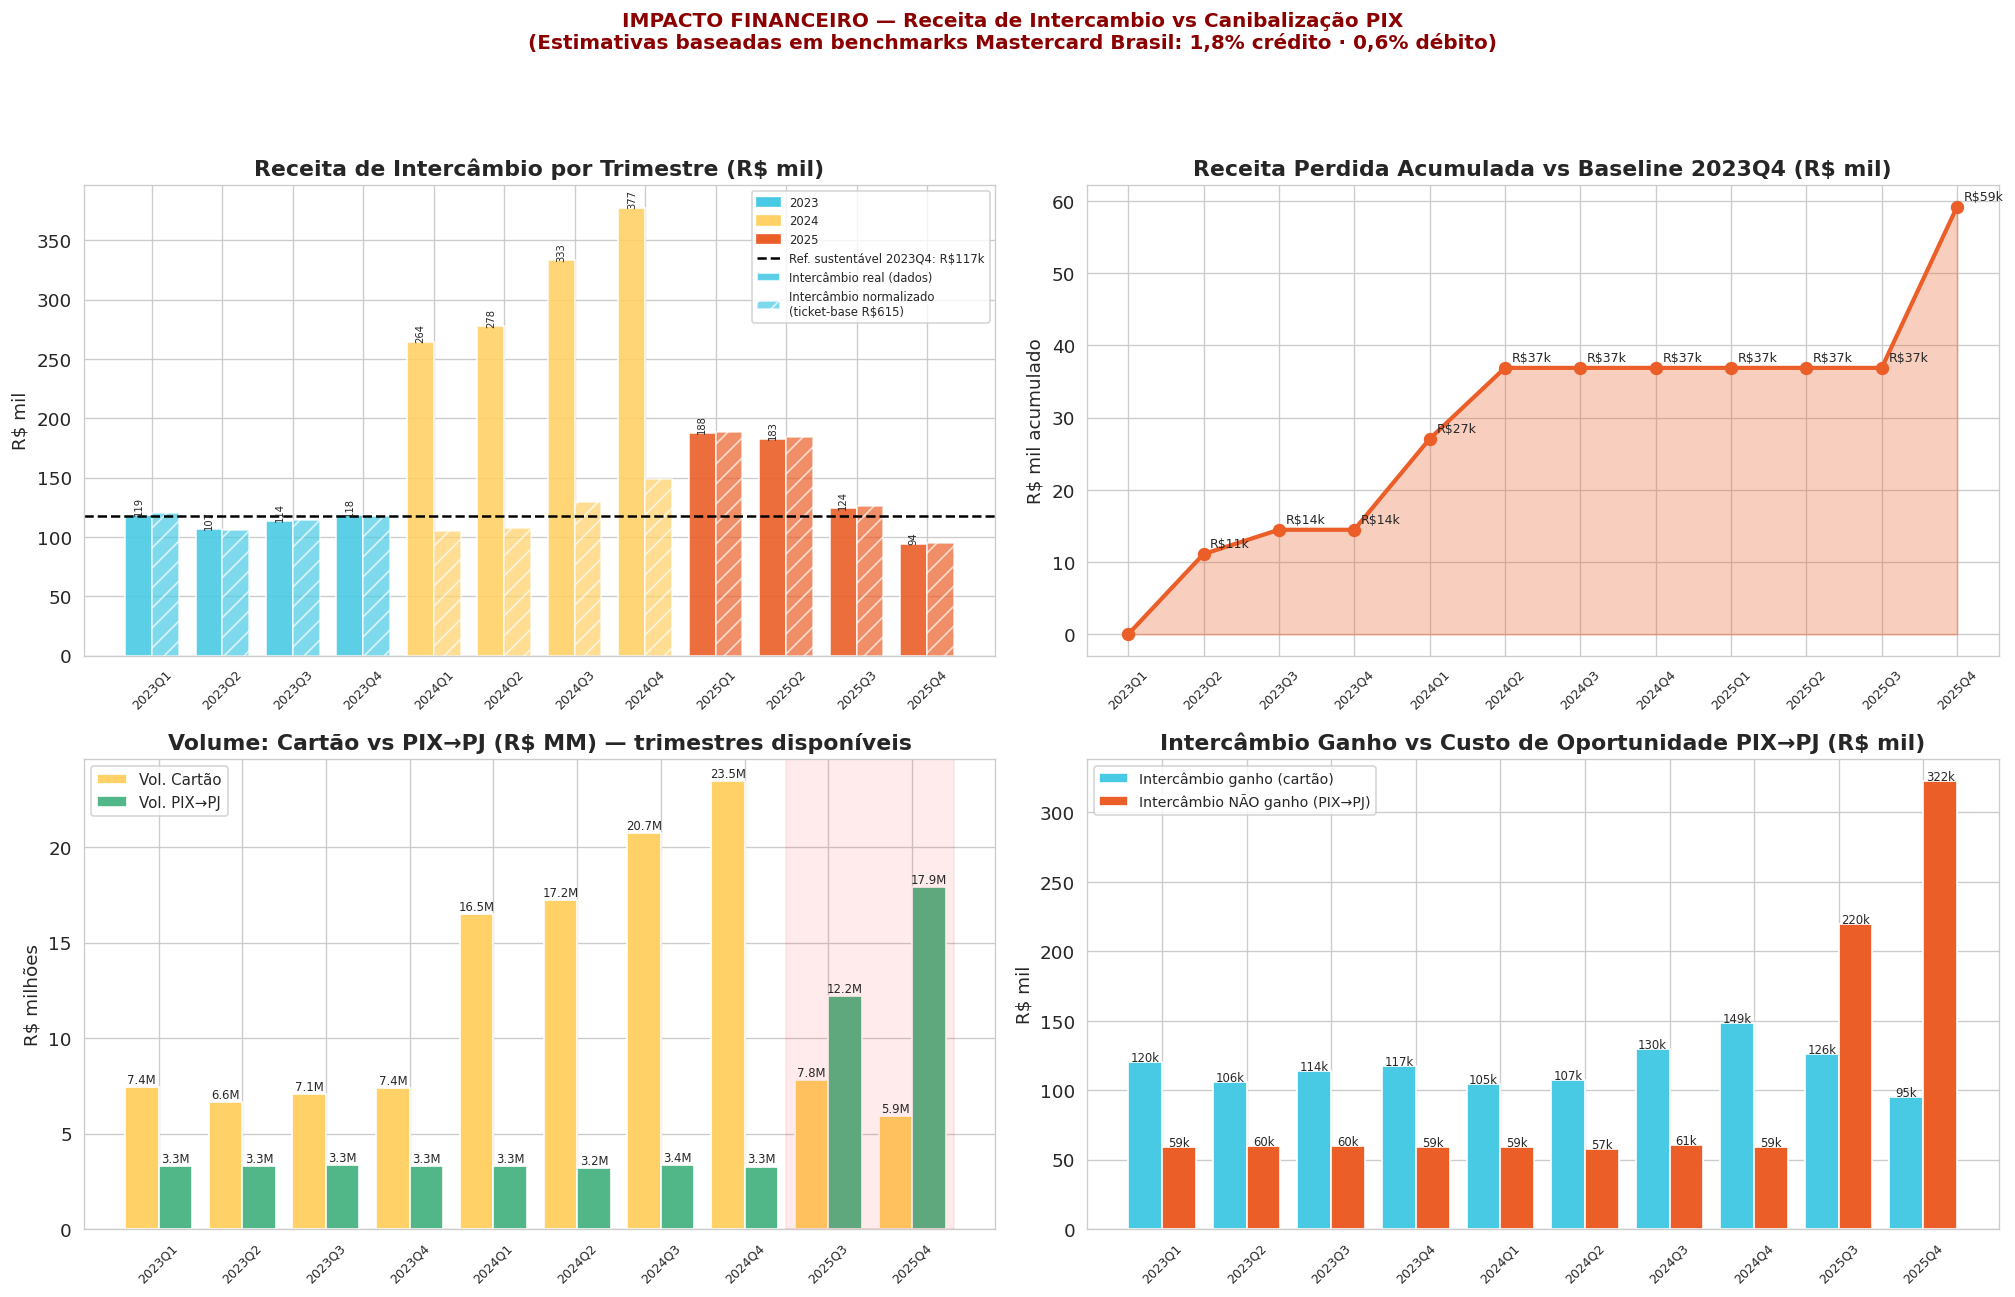


=== KPIs DE IMPACTO FINANCEIRO ===
Perda estimada de intercambio em 2025 (norm.): R$22,325  ≈ R$22k
Intercambio em 2025Q4 (norm.):                 R$94,966/tri
Custo de oportunidade PIX PJ em 2025Q4:        R$322,453/tri
  → PIX PJ 2025Q4 (R$17.9M) JA SUPERA vol. cartao (R$5.9M)
  → Razao PIX-PJ/Cartao em 2025Q4: 3.0x

Se o banco recuperasse 50% do PIX PJ para cartao:
  Ganho adicional de intercambio/tri: R$161,226
  Corresponderia a 170% da receita atual de intercambio


In [14]:
quarts = [str(q) for q in iq['YQ']]
interc_r  = iq['Interc'].values / 1e3
interc_n  = iq['Interc_Norm'].values / 1e3
perda_n   = iq['Perda_vs_2023'].values / 1e3
perda_cum = iq['Perda_Cum'].values / 1e3
anos      = [str(q)[:4] for q in iq['YQ']]
cores_ano = {'2023':'#48cae4','2024':'#ffd166','2025':'#eb5e28'}
bar_cores = [cores_ano[a] for a in anos]

# PIX PJ
pq_str = [str(q) for q in pq['YQ']]
pq_oport = pq['Oport_Interc'].values / 1e3
pq_vol   = pq['Vol_PIX_PJ'].values / 1e6

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle(
    'IMPACTO FINANCEIRO — Receita de Intercambio vs Canibalização PIX\n'
    '(Estimativas baseadas em benchmarks Mastercard Brasil: 1,8% crédito · 0,6% débito)',
    fontsize=12, fontweight='bold', color='#8b0000'
)

# ── Painel 1: Intercambio real + normalizado por trimestre ────────────────
x = np.arange(len(quarts)); w = 0.38
b1 = axes[0,0].bar(x-w/2, interc_r, w, label='Intercâmbio real (dados)', color=bar_cores, edgecolor='white', alpha=0.9)
axes[0,0].bar(x+w/2, interc_n, w, label=f'Intercâmbio normalizado\n(ticket-base R$615)', color=bar_cores, edgecolor='white', hatch='//', alpha=0.7)
axes[0,0].axhline(interc_n[3], color='black', linestyle='--', linewidth=1.5, label=f'Ref. sustentável 2023Q4: R${interc_n[3]:.0f}k')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(quarts, rotation=45, fontsize=7.5)
axes[0,0].set_title('Receita de Intercâmbio por Trimestre (R$ mil)', fontweight='bold')
axes[0,0].set_ylabel('R$ mil')
axes[0,0].legend(fontsize=7.5)
patches = [mpatches.Patch(color=cores_ano[a], label=a) for a in ['2023','2024','2025']]
axes[0,0].legend(handles=patches + axes[0,0].get_legend_handles_labels()[0], fontsize=7)
for b,v in zip(b1,interc_r): axes[0,0].text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}', ha='center', fontsize=6, rotation=90)

# ── Painel 2: Perda acumulada (normalizada) ───────────────────────────────
axes[0,1].fill_between(quarts, perda_cum, alpha=0.3, color='#eb5e28')
axes[0,1].plot(quarts, perda_cum, color='#eb5e28', linewidth=2.5, marker='o', markersize=7)
axes[0,1].set_title('Receita Perdida Acumulada vs Baseline 2023Q4 (R$ mil)', fontweight='bold')
axes[0,1].set_ylabel('R$ mil acumulado')
axes[0,1].tick_params(axis='x', rotation=45); axes[0,1].tick_params(axis='x', labelsize=7.5)
for i,v in enumerate(perda_cum):
    if v > 0: axes[0,1].annotate(f'R${v:.0f}k', (quarts[i],v), xytext=(4,4), textcoords='offset points', fontsize=7.5)

# ── Painel 3: Vol. Cartão vs PIX PJ (trimestres onde os dois existem) ─────
iq_str = {str(q):r for q,(_,r) in zip(iq['YQ'],iq.iterrows())}
common = [q for q in quarts if q in pq_str]
v_cart = [iq_str[q]['Vol_Cartao']/1e6 for q in common]
v_pixpj= [pq['Vol_PIX_PJ'].values[pq_str.index(q)]/1e6 for q in common]
xc = np.arange(len(common)); wc = 0.4
axes[1,0].bar(xc-wc/2, v_cart,  wc, label='Vol. Cartão',  color='#ffd166', edgecolor='white')
axes[1,0].bar(xc+wc/2, v_pixpj, wc, label='Vol. PIX→PJ', color='#52b788', edgecolor='white')
axes[1,0].set_xticks(xc); axes[1,0].set_xticklabels(common, rotation=45, fontsize=7.5)
axes[1,0].set_title('Volume: Cartão vs PIX→PJ (R$ MM) — trimestres disponíveis', fontweight='bold')
axes[1,0].set_ylabel('R$ milhões')
axes[1,0].legend(fontsize=9)
axes[1,0].axvspan(xc[-2]-0.5, xc[-1]+0.5, alpha=0.08, color='red', label='Inversão 2025')
for xi,vc,vp in zip(xc,v_cart,v_pixpj):
    axes[1,0].text(xi-wc/2, vc+0.2, f'{vc:.1f}M', ha='center', fontsize=7)
    axes[1,0].text(xi+wc/2, vp+0.2, f'{vp:.1f}M', ha='center', fontsize=7)

# ── Painel 4: Custo de oportunidade PIX PJ ────────────────────────────────
oport_vals = [pq['Oport_Interc'].values[pq_str.index(q)] / 1e3 for q in common]
interc_real_common = [iq_str[q]['Interc_Norm']/1e3 for q in common]
axes[1,1].bar(xc-wc/2, interc_real_common, wc, label='Intercâmbio ganho (cartão)', color='#48cae4', edgecolor='white')
axes[1,1].bar(xc+wc/2, oport_vals,          wc, label='Intercâmbio NÃO ganho (PIX→PJ)', color='#eb5e28', edgecolor='white')
axes[1,1].set_xticks(xc); axes[1,1].set_xticklabels(common, rotation=45, fontsize=7.5)
axes[1,1].set_title('Intercâmbio Ganho vs Custo de Oportunidade PIX→PJ (R$ mil)', fontweight='bold')
axes[1,1].set_ylabel('R$ mil')
axes[1,1].legend(fontsize=8.5)
for xi,ir,op in zip(xc,interc_real_common,oport_vals):
    axes[1,1].text(xi-wc/2, ir+0.5, f'{ir:.0f}k', ha='center', fontsize=7)
    axes[1,1].text(xi+wc/2, op+0.5, f'{op:.0f}k', ha='center', fontsize=7)

plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('docs/analise_intercambio_perdido.png', dpi=130, bbox_inches='tight')
plt.show()

# ── KPIs finais ───────────────────────────────────────────────────────────
perda_2025 = iq[iq['YQ'].astype(str).str[:4]=='2025']['Perda_vs_2023'].sum()
interc_q4_25 = iq[iq['YQ'].astype(str)=='2025Q4']['Interc_Norm'].values[0]
oport_q4_25  = pq[pq['YQ'].astype(str)=='2025Q4']['Oport_Interc'].values[0]
vol_pix_q425 = pq[pq['YQ'].astype(str)=='2025Q4']['Vol_PIX_PJ'].values[0]
vol_crt_q425 = iq[iq['YQ'].astype(str)=='2025Q4']['Vol_Cartao'].values[0]

print('\n=== KPIs DE IMPACTO FINANCEIRO ===')
print(f'Perda estimada de intercambio em 2025 (norm.): R${perda_2025:,.0f}  ≈ R${perda_2025/1e3:.0f}k')
print(f'Intercambio em 2025Q4 (norm.):                 R${interc_q4_25:,.0f}/tri')
print(f'Custo de oportunidade PIX PJ em 2025Q4:        R${oport_q4_25:,.0f}/tri')
print(f'  → PIX PJ 2025Q4 (R${vol_pix_q425/1e6:.1f}M) JA SUPERA vol. cartao (R${vol_crt_q425/1e6:.1f}M)')
print(f'  → Razao PIX-PJ/Cartao em 2025Q4: {vol_pix_q425/vol_crt_q425:.1f}x')
print(f'\nSe o banco recuperasse 50% do PIX PJ para cartao:')
print(f'  Ganho adicional de intercambio/tri: R${oport_q4_25*0.5:,.0f}')
print(f'  Corresponderia a {oport_q4_25*0.5/interc_q4_25*100:.0f}% da receita atual de intercambio')

### 9.3 Distribuição de Idades e Uso do PIX

Objetivo: entender **quem usa PIX**, com que **intensidade** e quanto **dinheiro movimenta** — por faixa etária. Cruzamento entre `Base_clientes` e `Base_pix`.

A análise distingue:
- **Penetração:** % de clientes de cada faixa que fez ao menos um PIX
- **Intensidade:** quantidade de transações PIX por cliente
- **Volume por cliente:** quanto cada cliente movimenta via PIX
- **Canibalização:** volume enviado para PJ (proxy de pagamento em comércio)
- **Dinâmica temporal:** evolução 2025 por faixa (trimestres disponíveis)

In [15]:
hoje_ref = pd.Timestamp('2026-06-13')
base_clientes['Idade'] = ((hoje_ref - base_clientes['Data_Nascimento']).dt.days / 365.25).astype(int)
BINS   = [18, 30, 40, 50, 60, 70, 100]
LABELS = ['18-29','30-39','40-49','50-59','60-69','70+']
base_clientes['Faixa'] = pd.cut(base_clientes['Idade'], bins=BINS, labels=LABELS, right=False)

# Bases filtradas
pix_ok  = pix_clean.copy()  # pix_clean: Valor>0, Data notna, Aprovado=1
pix_env = pix_ok[pix_ok['Tipo_transacao'] == 'Envio'].copy()
pix_pj  = pix_env[pix_env['PF_PJ']=='PJ'].copy()  # Aprovado já filtrado

base_clientes['usa_pix'] = base_clientes['Cliente_ID'].isin(set(pix_ok['Cliente_ID']))

# Agregações por faixa
fbase = base_clientes.groupby('Faixa', observed=True).agg(
    Total=('Cliente_ID','count'), Com_PIX=('usa_pix','sum')
).reset_index()
fbase['Sem_PIX']  = fbase['Total'] - fbase['Com_PIX']
fbase['Pct_PIX']  = fbase['Com_PIX'] / fbase['Total'] * 100

pix_cl   = pix_ok.merge(base_clientes[['Cliente_ID','Faixa']], on='Cliente_ID', how='left')
pix_pj_cl= pix_pj.merge(base_clientes[['Cliente_ID','Faixa']], on='Cliente_ID', how='left')
pix_env_cl=pix_env.merge(base_clientes[['Cliente_ID','Faixa']], on='Cliente_ID', how='left')

fpix = pix_cl.groupby('Faixa', observed=True).agg(
    Vol=('Valor','sum'), Qtd=('Valor','count'),
    Cli_PIX=('Cliente_ID','nunique'), Med=('Valor','median')
).reset_index()
fpj  = pix_pj_cl.groupby('Faixa', observed=True).agg(
    Vol_PJ=('Valor','sum'), Qtd_PJ=('Valor','count')
).reset_index()

tr_ok = base_transacoes[base_transacoes['Valor_Compra']>0].copy()
tr_cl = tr_ok.merge(base_clientes[['Cliente_ID','Faixa']], on='Cliente_ID', how='left')
fcart = tr_cl.groupby('Faixa', observed=True).agg(
    Vol_Cart=('Valor_Compra','sum'), Qtd_Cart=('Valor_Compra','count'),
    Cli_Cart=('Cliente_ID','nunique'), Tick_Cart=('Valor_Compra','median')
).reset_index()

comp = fbase.merge(fpix, on='Faixa').merge(fpj, on='Faixa').merge(fcart, on='Faixa')
comp['Tx_Per_Cli']   = comp['Qtd']      / comp['Cli_PIX']
comp['Vol_Per_Cli']  = comp['Vol']       / comp['Cli_PIX']
comp['Cart_Per_Cli'] = comp['Qtd_Cart']  / comp['Cli_Cart']
comp['Razao_Qtd']    = comp['Tx_Per_Cli'] / comp['Cart_Per_Cli']
comp['Razao_Vol']    = (comp['Vol']/comp['Cli_PIX']) / (comp['Vol_Cart']/comp['Cli_Cart'])
comp['Pct_PJ_Vol']   = comp['Vol_PJ'] / comp['Vol'] * 100

print('=== PIX × FAIXA ETÁRIA — VISÃO CONSOLIDADA ===')
print(f'{"Faixa":<8} {"Clientes":>9} {"% PIX":>7} {"Tx/cli":>8} {"Vol/cli":>12} {"Raz.PIX/Cart":>14} {"Mediana":>9} {"Vol PJ":>12}')
print('-'*85)
for _,r in comp.iterrows():
    flag = ' ◄ ALERTA' if r['Razao_Qtd'] >= 3 else (' ◄' if r['Razao_Qtd'] >= 1.8 else '')
    print(f"{str(r['Faixa']):<8} {int(r['Total']):>9,} {r['Pct_PIX']:>6.0f}%  {r['Tx_Per_Cli']:>8.0f} "
          f"R${r['Vol_Per_Cli']:>9,.0f}  {r['Razao_Qtd']:>12.1f}x  R${r['Med']:>6.0f}  R${r['Vol_PJ']/1e6:>8.2f}M{flag}")

print('\nColuna Raz.PIX/Cart = (tx PIX por cliente) / (tx cartao por cliente)')
print('Valores > 1 indicam predominancia do PIX sobre o cartao em frequencia de uso')

print('\n=== DESTAQUES CRÍTICOS ===')
r1829 = comp[comp['Faixa']=='18-29'].iloc[0]
r70   = comp[comp['Faixa']=='70+'].iloc[0]
print(f'[!] 18-29: {r1829["Razao_Qtd"]:.1f}x mais PIX do que cartao por cliente — maior razao de TODAS as faixas')
print(f'    Volume PIX/cliente: R${r1829["Vol_Per_Cli"]:,.0f} — {r1829["Vol_Per_Cli"]/comp[comp["Faixa"]=="40-49"].iloc[0]["Vol_Per_Cli"]*100:.0f}% do dobro da faixa 40-49')
print(f'    Apenas {int(r1829["Total"])} clientes desta faixa no banco — subrepresentacao critica')
print(f'[!] 70+: {r70["Razao_Qtd"]:.1f}x mais PIX que cartao — segunda maior razao')
print(f'    Mediana de ticket PIX: R${r70["Med"]:.0f} — maior de todas as faixas')

# Evolução temporal 2025
pix_env_cl['YQ'] = pix_env_cl['Data'].dt.to_period('Q')
ev25 = pix_env_cl[pix_env_cl['Data'].dt.year==2025].groupby(
    ['YQ','Faixa'], observed=True)['Valor'].agg(['sum','count']).unstack(fill_value=0)
print('\n=== CRESCIMENTO Q3→Q4 2025 POR FAIXA (vol PIX envio, R$ milhoes) ===')
for col in LABELS:
    if col in ev25['sum'].columns:
        q3 = ev25['sum'][col].get('2025Q3', 0) / 1e6
        q4 = ev25['sum'][col].get('2025Q4', 0) / 1e6
        cres = (q4/q3 - 1)*100 if q3 > 0 else 0
        print(f'  {col}: Q3=R${q3:.2f}M → Q4=R${q4:.2f}M  (+{cres:.0f}%)')

=== PIX × FAIXA ETÁRIA — VISÃO CONSOLIDADA ===
Faixa     Clientes   % PIX   Tx/cli      Vol/cli   Raz.PIX/Cart   Mediana       Vol PJ
-------------------------------------------------------------------------------------
18-29          115     67%       393 R$  138,191           3.3x  R$   188  R$    5.27M ◄ ALERTA
30-39          279     73%       163 R$   68,798           1.5x  R$   191  R$    7.49M
40-49          578     76%       163 R$   70,110           1.5x  R$   192  R$   16.67M
50-59          562     73%       163 R$   71,683           1.5x  R$   203  R$   15.84M
60-69          336     69%       154 R$   66,337           1.4x  R$   197  R$    8.27M
70+             90     73%       175 R$   85,917           1.8x  R$   251  R$    2.96M ◄

Coluna Raz.PIX/Cart = (tx PIX por cliente) / (tx cartao por cliente)
Valores > 1 indicam predominancia do PIX sobre o cartao em frequencia de uso

=== DESTAQUES CRÍTICOS ===
[!] 18-29: 3.3x mais PIX do que cartao por cliente — maior razao de TODA

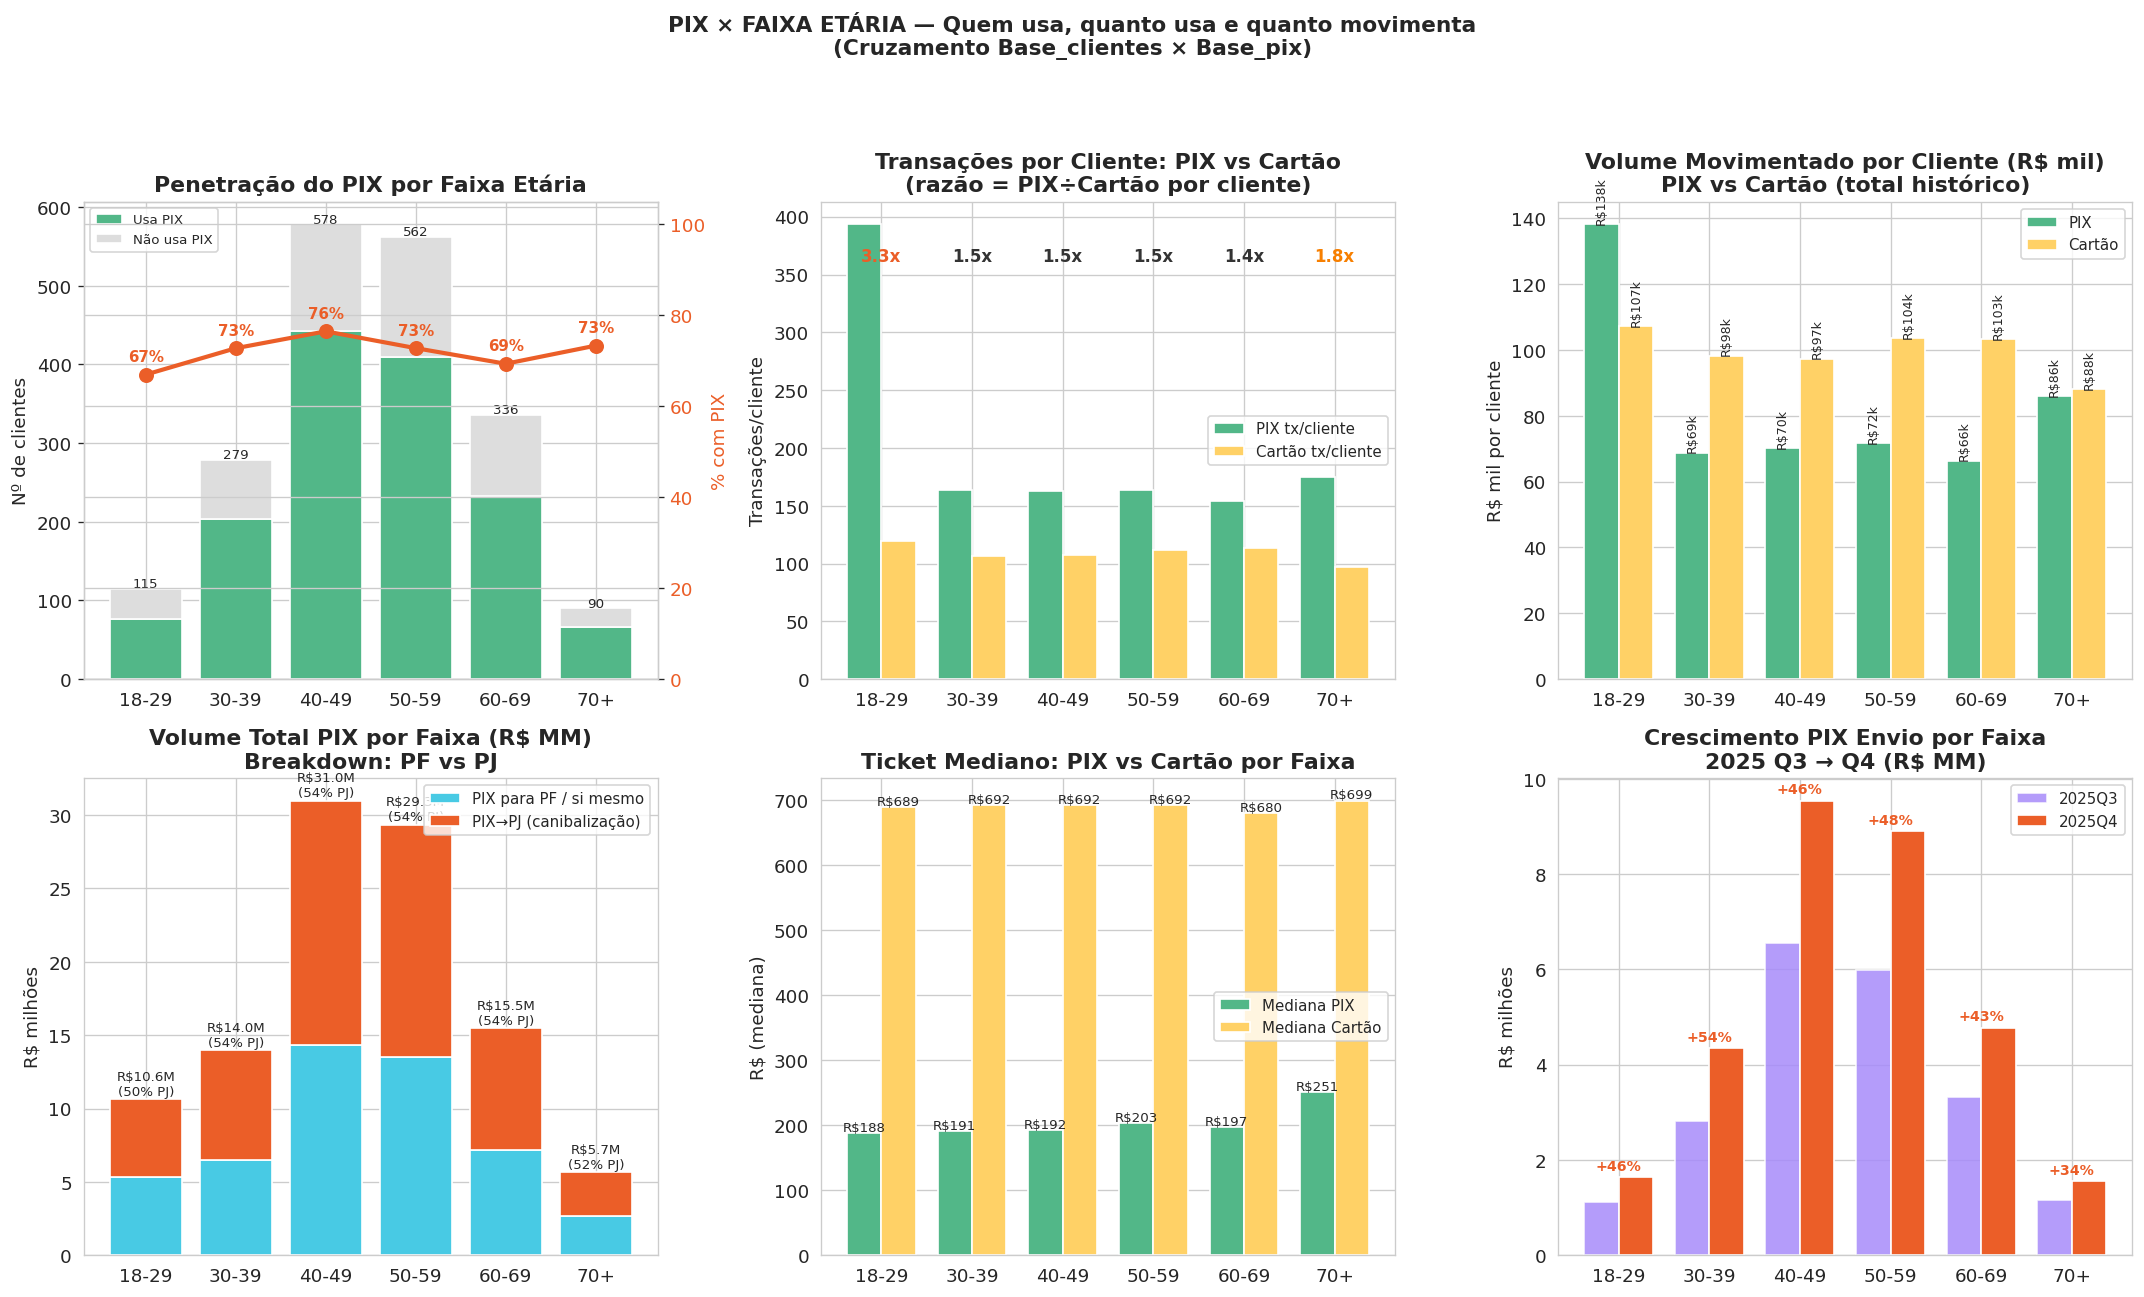


=== KPIs SÍNTESE ===
Faixa 18-29 representa apenas 5.9% da base de clientes
Faixa 18-29: 393 PIX/cliente = 3.3x mais que cartão
Volume PIX/cliente 18-29 (R$138,191) vs 40-49 (R$70,110): 2.0x maior
PIX PJ representa 53% do volume total de PIX — uniforme entre faixas
Crescimento Q3→Q4 2025: todas as faixas crescem +47% no volume enviado


In [16]:
FAIX  = [str(f) for f in comp['Faixa']]
x     = np.arange(len(FAIX))
C = ['#eb5e28','#48cae4','#52b788','#ffd166','#a78bfa','#f77f00']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('PIX × FAIXA ETÁRIA — Quem usa, quanto usa e quanto movimenta\n'
             '(Cruzamento Base_clientes × Base_pix)', fontsize=13, fontweight='bold')

# ── P1: Penetração PIX por faixa (empilhado com linha %) ─────────────────
b_com = axes[0,0].bar(x, comp['Com_PIX'],  color='#52b788', edgecolor='white', label='Usa PIX')
b_sem = axes[0,0].bar(x, comp['Sem_PIX'],  bottom=comp['Com_PIX'],
                      color='#dddddd', edgecolor='white', label='Não usa PIX')
ax2 = axes[0,0].twinx()
ax2.plot(x, comp['Pct_PIX'], color='#eb5e28', linewidth=2.5, marker='o', markersize=8, label='% penetração')
ax2.set_ylim(0, 105); ax2.set_ylabel('% com PIX', color='#eb5e28')
ax2.tick_params(axis='y', labelcolor='#eb5e28')
for xi, pct in zip(x, comp['Pct_PIX']):
    ax2.annotate(f'{pct:.0f}%', (xi, pct), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9, color='#eb5e28', fontweight='bold')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(FAIX)
axes[0,0].set_title('Penetração do PIX por Faixa Etária', fontweight='bold')
axes[0,0].set_ylabel('Nº de clientes')
axes[0,0].legend(loc='upper left', fontsize=8)
for b,v in zip(b_com, comp['Total']): axes[0,0].text(b.get_x()+b.get_width()/2, v+2, str(int(v)), ha='center', fontsize=8)

# ── P2: Transações por cliente: PIX vs Cartão ─────────────────────────────
w = 0.38
axes[0,1].bar(x-w/2, comp['Tx_Per_Cli'],   w, color='#52b788', edgecolor='white', label='PIX tx/cliente')
axes[0,1].bar(x+w/2, comp['Cart_Per_Cli'],  w, color='#ffd166', edgecolor='white', label='Cartão tx/cliente')
for xi, rq in zip(x, comp['Razao_Qtd']):
    cor = '#eb5e28' if rq >= 3 else ('#f77f00' if rq >= 1.8 else '#333333')
    axes[0,1].text(xi, max(comp['Tx_Per_Cli'].max(), comp['Cart_Per_Cli'].max())*0.92,
                   f'{rq:.1f}x', ha='center', fontsize=10, fontweight='bold', color=cor)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(FAIX)
axes[0,1].set_title('Transações por Cliente: PIX vs Cartão\n(razão = PIX÷Cartão por cliente)', fontweight='bold')
axes[0,1].set_ylabel('Transações/cliente')
axes[0,1].legend(fontsize=9)

# ── P3: Volume por cliente: PIX vs Cartão ─────────────────────────────────
vol_cart_cli = comp['Vol_Cart'] / comp['Cli_Cart']
axes[0,2].bar(x-w/2, comp['Vol_Per_Cli']/1e3, w, color='#52b788', edgecolor='white', label='PIX')
axes[0,2].bar(x+w/2, vol_cart_cli/1e3,          w, color='#ffd166', edgecolor='white', label='Cartão')
for xi, vp, vc in zip(x, comp['Vol_Per_Cli']/1e3, vol_cart_cli/1e3):
    axes[0,2].text(xi-w/2, vp+1, f'R${vp:.0f}k', ha='center', fontsize=7.5, rotation=90)
    axes[0,2].text(xi+w/2, vc+1, f'R${vc:.0f}k', ha='center', fontsize=7.5, rotation=90)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(FAIX)
axes[0,2].set_title('Volume Movimentado por Cliente (R$ mil)\nPIX vs Cartão (total histórico)', fontweight='bold')
axes[0,2].set_ylabel('R$ mil por cliente')
axes[0,2].legend(fontsize=9)

# ── P4: Volume total PIX + PJ por faixa ───────────────────────────────────
vol_pf = (comp['Vol'] - comp['Vol_PJ']) / 1e6
vol_pj = comp['Vol_PJ'] / 1e6
bp_pf = axes[1,0].bar(x, vol_pf, color='#48cae4', edgecolor='white', label='PIX para PF / si mesmo')
bp_pj = axes[1,0].bar(x, vol_pj, bottom=vol_pf, color='#eb5e28', edgecolor='white', label='PIX→PJ (canibalização)')
for xi, vt, vpj in zip(x, comp['Vol']/1e6, vol_pj):
    pct_pj = vpj/vt*100
    axes[1,0].text(xi, vt+0.3, f'R${vt:.1f}M\n({pct_pj:.0f}% PJ)', ha='center', fontsize=8)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(FAIX)
axes[1,0].set_title('Volume Total PIX por Faixa (R$ MM)\nBreakdown: PF vs PJ', fontweight='bold')
axes[1,0].set_ylabel('R$ milhões'); axes[1,0].legend(fontsize=9)

# ── P5: Ticket mediano PIX vs Cartão ──────────────────────────────────────
axes[1,1].bar(x-w/2, comp['Med'],       w, color='#52b788', edgecolor='white', label='Mediana PIX')
axes[1,1].bar(x+w/2, comp['Tick_Cart'], w, color='#ffd166', edgecolor='white', label='Mediana Cartão')
for xi, mp, mc in zip(x, comp['Med'], comp['Tick_Cart']):
    axes[1,1].text(xi-w/2, mp+3, f'R${mp:.0f}', ha='center', fontsize=8)
    axes[1,1].text(xi+w/2, mc+3, f'R${mc:.0f}', ha='center', fontsize=8)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(FAIX)
axes[1,1].set_title('Ticket Mediano: PIX vs Cartão por Faixa', fontweight='bold')
axes[1,1].set_ylabel('R$ (mediana)'); axes[1,1].legend(fontsize=9)

# ── P6: Evolução Q3→Q4 2025 por faixa ────────────────────────────────────
pix_env_cl['YQ'] = pix_env_cl['Data'].dt.to_period('Q')
ev25 = pix_env_cl[pix_env_cl['Data'].dt.year==2025].groupby(
    ['YQ','Faixa'], observed=True)['Valor'].sum().unstack(fill_value=0) / 1e6
q3v = [ev25.get(f, pd.Series([0,0])).get('2025Q3', 0) if '2025Q3' in ev25.index else 0 for f in FAIX]
q4v = [ev25.get(f, pd.Series([0,0])).get('2025Q4', 0) if '2025Q4' in ev25.index else 0 for f in FAIX]
if '2025Q3' in ev25.index: q3v = [ev25.loc['2025Q3'].get(f,0) for f in FAIX]
if '2025Q4' in ev25.index: q4v = [ev25.loc['2025Q4'].get(f,0) for f in FAIX]
xw = 0.38
axes[1,2].bar(x-xw/2, q3v, xw, color='#a78bfa', edgecolor='white', label='2025Q3', alpha=0.85)
axes[1,2].bar(x+xw/2, q4v, xw, color='#eb5e28', edgecolor='white', label='2025Q4')
for xi, v3, v4 in zip(x, q3v, q4v):
    cres = (v4/v3-1)*100 if v3>0 else 0
    axes[1,2].text(xi, max(v3,v4)+0.15, f'+{cres:.0f}%', ha='center', fontsize=8.5, color='#eb5e28', fontweight='bold')
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(FAIX)
axes[1,2].set_title('Crescimento PIX Envio por Faixa\n2025 Q3 → Q4 (R$ MM)', fontweight='bold')
axes[1,2].set_ylabel('R$ milhões'); axes[1,2].legend(fontsize=9)

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('docs/pix_por_faixa_etaria.png', dpi=130, bbox_inches='tight')
plt.show()

# ── KPI summary ───────────────────────────────────────────────────────────
print('\n=== KPIs SÍNTESE ===')
r18 = comp[comp['Faixa']=='18-29'].iloc[0]
r40 = comp[comp['Faixa']=='40-49'].iloc[0]
print(f'Faixa 18-29 representa apenas {r18["Total"]/comp["Total"].sum()*100:.1f}% da base de clientes')
print(f'Faixa 18-29: {r18["Tx_Per_Cli"]:.0f} PIX/cliente = {r18["Razao_Qtd"]:.1f}x mais que cartão')
print(f'Volume PIX/cliente 18-29 (R${r18["Vol_Per_Cli"]:,.0f}) vs 40-49 (R${r40["Vol_Per_Cli"]:,.0f}): {r18["Vol_Per_Cli"]/r40["Vol_Per_Cli"]:.1f}x maior')
print(f'PIX PJ representa {comp["Vol_PJ"].sum()/comp["Vol"].sum()*100:.0f}% do volume total de PIX — uniforme entre faixas')
print(f'Crescimento Q3→Q4 2025: todas as faixas crescem +{(sum(q4v)/sum(q3v)-1)*100:.0f}% no volume enviado')

---
## 10. Análise de Churn — Diagnóstico de Risco de Abandono

Churn em banco emissor tem **cinco manifestações distintas**, cada uma com motivação e evidência diferente:

| Tipo | Nome | Definição operacional |
|------|------|----------------------|
| **A** | Churn Silencioso (PIX) | Cliente mantém conta mas substitui cartão por PIX → perda de receita sem encerramento |
| **B** | Conta Fantasma | Nenhuma atividade histórica em nenhuma base |
| **C** | Inatividade 2025 | Estava ativo antes, desapareceu em 2025 |
| **D** | Desinvestimento | Resgates líquidos crescentes → sinal de saída financeira |
| **E** | Cartão Vencido | Cartão expirou sem renovação → janela de perda |

> **Limitação de dados:** PIX 2025 disponível apenas para Q3–Q4. O score de churn usa critérios de cartão e investimentos para evitar falsos positivos.

> **Nota:** Os 450 cartões com `Data_Ativacao < Data_Emissao` são excluídos de todas as análises abaixo.

In [17]:
hoje_ref = pd.Timestamp('2026-06-13')
base_clientes['Idade'] = ((hoje_ref - base_clientes['Data_Nascimento']).dt.days / 365.25).astype(int)
base_clientes['Antiguidade_Meses'] = ((hoje_ref - base_clientes['Data_Criacao_Conta']).dt.days / 30.44).round(0)
BINS = [18,30,40,50,60,70,100]; LABELS = ['18-29','30-39','40-49','50-59','60-69','70+']
base_clientes['Faixa'] = pd.cut(base_clientes['Idade'], bins=BINS, labels=LABELS, right=False)

tr_ok  = base_transacoes[base_transacoes['Valor_Compra'] > 0].copy()
tr_ok['YQ'] = tr_ok['Data'].dt.to_period('Q')
pix_ok = pix_clean.copy()  # pix_clean: Valor>0, Data notna, Aprovado=1
cart_validos = base_cartoes[~(
    (base_cartoes['Data_Ativacao'] < base_cartoes['Data_Emissao']) &
    base_cartoes['Data_Validade'].isnull()
)].copy()

# Sets de atividade
tx_hist   = set(tr_ok['Cliente_ID'])
tx_2024   = set(tr_ok[tr_ok['Data'].dt.year==2024]['Cliente_ID'])
tx_2025   = set(tr_ok[tr_ok['Data'].dt.year==2025]['Cliente_ID'])
tx_q3_25  = set(tr_ok[tr_ok['YQ'].astype(str)=='2025Q3']['Cliente_ID'])
tx_q4_25  = set(tr_ok[tr_ok['YQ'].astype(str)=='2025Q4']['Cliente_ID'])
pix_hist  = set(pix_ok['Cliente_ID'])
pix_2025  = set(pix_ok[pix_ok['Data'].dt.year==2025]['Cliente_ID'])
inv_hist  = set(base_investimentos['Cliente_ID'])
todos     = set(base_clientes['Cliente_ID'])

# [B] Contas fantasma
fantasmas     = todos - tx_hist - pix_hist - inv_hist
df_fant       = base_clientes[base_clientes['Cliente_ID'].isin(fantasmas)]

# [C] Inativos em 2025
inv_2025_any  = set(base_investimentos[base_investimentos['Data'].astype(str).str[:4]=='2025']['Cliente_ID'])
ativos_2025   = tx_2025 | pix_2025 | inv_2025_any
inativos_2025 = (todos - ativos_2025) - fantasmas
df_inat       = base_clientes[base_clientes['Cliente_ID'].isin(inativos_2025)]
migraram_pix  = (tx_2024 - tx_2025) & pix_2025
desapareceu   = (tx_2024 - tx_2025) - pix_2025

# [D] Desinvestimento
inv_resg  = base_investimentos[base_investimentos['Valor_Aplicado'] < 0].copy()
inv_resg['Periodo'] = inv_resg['Data'].astype(str).apply(
    lambda x: f"{x[:4]}Q{(int(x[4:6])-1)//3+1}" if len(x)>=6 and x[4:6].isdigit() else 'X')
resg_q = inv_resg.groupby('Periodo')['Valor_Aplicado'].agg(['count','sum']).sort_index()
resg_q = resg_q[resg_q.index.str.match(r'20(23|24|25)Q[1-4]')]
inv_2025_df    = base_investimentos[base_investimentos['Data'].astype(str).str[:4]=='2025']
saldo_liq_2025 = inv_2025_df.groupby('Cliente_ID')['Valor_Aplicado'].sum()
desinvest_ids  = set(saldo_liq_2025[saldo_liq_2025 < 0].index)
df_desinv      = base_clientes[base_clientes['Cliente_ID'].isin(desinvest_ids)]

# [E] Cartões vencidos
vencidos = cart_validos[
    (cart_validos['Data_Validade'].notna()) & (cart_validos['Data_Validade'] < hoje_ref)]
ultima_tx_venc = tr_ok[tr_ok['ID_Cartao'].isin(set(vencidos['ID_Cartao']))].groupby('ID_Cartao')['Data'].max()
vencidos = vencidos.merge(ultima_tx_venc.rename('Ultima_Tx'), on='ID_Cartao', how='left')

# Score de risco por cliente
df_score = base_clientes[['Cliente_ID','Faixa','Idade','Renda_Anual','Antiguidade_Meses']].copy()
df_score['s_fantasma']      = df_score['Cliente_ID'].isin(fantasmas).astype(int) * 3
df_score['s_inativo_2025']  = df_score['Cliente_ID'].isin(inativos_2025).astype(int) * 2
df_score['s_sem_cart_q4']   = (~df_score['Cliente_ID'].isin(tx_q4_25)).astype(int)
df_score['s_sem_cart_q3']   = (~df_score['Cliente_ID'].isin(tx_q3_25)).astype(int)
df_score['s_desinvest']     = df_score['Cliente_ID'].isin(desinvest_ids).astype(int)
df_score['score'] = df_score[['s_fantasma','s_inativo_2025','s_sem_cart_q4','s_sem_cart_q3','s_desinvest']].sum(axis=1)
df_score['risco'] = pd.cut(df_score['score'], bins=[-1,1,3,10], labels=['Baixo','Médio','Alto'])

# Imprimir resultados
total_cli = len(todos)
print('='*60)
print('CENÁRIOS DE CHURN — QUANTIFICAÇÃO')
print('='*60)
print(f'\n[A] Churn Silencioso (PIX)')
print(f'    Cartão -75% vol (2024Q4→2025Q4) | PIX→PJ +470% → ver Seção 9')

print(f'\n[B] Contas Fantasma: {len(fantasmas)} clientes ({len(fantasmas)/total_cli*100:.1f}%)')
print(f'    Faixa: {dict(df_fant["Faixa"].value_counts().sort_index())}')
print(f'    Antiguidade média: {df_fant["Antiguidade_Meses"].mean():.0f} meses | Renda: R${df_fant["Renda_Anual"].mean():,.0f}')
print(f'    → Abriram conta mas nunca interagiram com nenhum produto')

print(f'\n[C] Inatividade em 2025: {len(inativos_2025)} clientes ({len(inativos_2025)/total_cli*100:.1f}%)')
print(f'    Faixa: {dict(df_inat["Faixa"].value_counts().sort_index())}')
print(f'    Antiguidade média: {df_inat["Antiguidade_Meses"].mean():.0f} meses | Renda: R${df_inat["Renda_Anual"].mean():,.0f}')
print(f'    C.1 Pararam cartão, ainda usam PIX:    {len(migraram_pix)} clientes')
print(f'    C.2 Desapareceram completamente:        {len(desapareceu)} clientes')
print(f'    C.3 Sumiram entre Q3→Q4/2025:          {len(tx_q3_25 - tx_q4_25)} clientes ({len(tx_q3_25-tx_q4_25)/len(tx_q3_25)*100:.1f}% dos ativos Q3)')

print(f'\n[D] Desinvestimento (2025): {len(desinvest_ids)} clientes com saldo líquido < 0')
print(f'    Faixa: {dict(df_desinv["Faixa"].value_counts().sort_index())}')
print(f'    Resgates por trimestre:')
for p in resg_q.index:
    r = resg_q.loc[p]
    print(f'      {p}: {int(r["count"]):>3} op | R${abs(r["sum"])/1e3:>7.0f}k')

print(f'\n[E] Cartões Vencidos: {len(vencidos)}')
print(f'    {dict(vencidos["Produto_Mastercard"].value_counts())}')
print(f'    Sem histórico de tx: {vencidos["Ultima_Tx"].isna().sum()}')
print(f'    56% são premium (Platinum+Black)')

print(f'\n--- SCORE DE RISCO ---')
print(df_score.groupby('risco', observed=True).size().rename('clientes'))
print(f'\nAlto risco por faixa:')
print(df_score[df_score['risco']=='Alto'].groupby('Faixa', observed=True).size())
print(f'\nMotivações prováveis por cenário:')
print('  [B] Onboarding falho — produto não comunicou valor na abertura')
print('  [C] Migração competitiva — LuminaPay (PIX no crédito) ou abandono')
print('  [D] Rentabilidade inferior — saldo migrando para concorrente (Aurora Bank?)')
print('  [E] Vencimento = janela crítica — cliente decide ao renovar se fica ou sai')
print('  [A] Substituto funcional — PIX atende melhor para compras do dia a dia')

CENÁRIOS DE CHURN — QUANTIFICAÇÃO

[A] Churn Silencioso (PIX)
    Cartão -75% vol (2024Q4→2025Q4) | PIX→PJ +470% → ver Seção 9

[B] Contas Fantasma: 85 clientes (4.3%)
    Faixa: {'18-29': np.int64(8), '30-39': np.int64(13), '40-49': np.int64(20), '50-59': np.int64(25), '60-69': np.int64(18), '70+': np.int64(1)}
    Antiguidade média: 27 meses | Renda: R$86,917
    → Abriram conta mas nunca interagiram com nenhum produto

[C] Inatividade em 2025: 2 clientes (0.1%)
    Faixa: {'18-29': np.int64(0), '30-39': np.int64(0), '40-49': np.int64(0), '50-59': np.int64(0), '60-69': np.int64(2), '70+': np.int64(0)}
    Antiguidade média: 36 meses | Renda: R$64,750
    C.1 Pararam cartão, ainda usam PIX:    2 clientes
    C.2 Desapareceram completamente:        2 clientes
    C.3 Sumiram entre Q3→Q4/2025:          39 clientes (2.8% dos ativos Q3)

[D] Desinvestimento (2025): 161 clientes com saldo líquido < 0
    Faixa: {'18-29': np.int64(12), '30-39': np.int64(19), '40-49': np.int64(57), '50-59': 

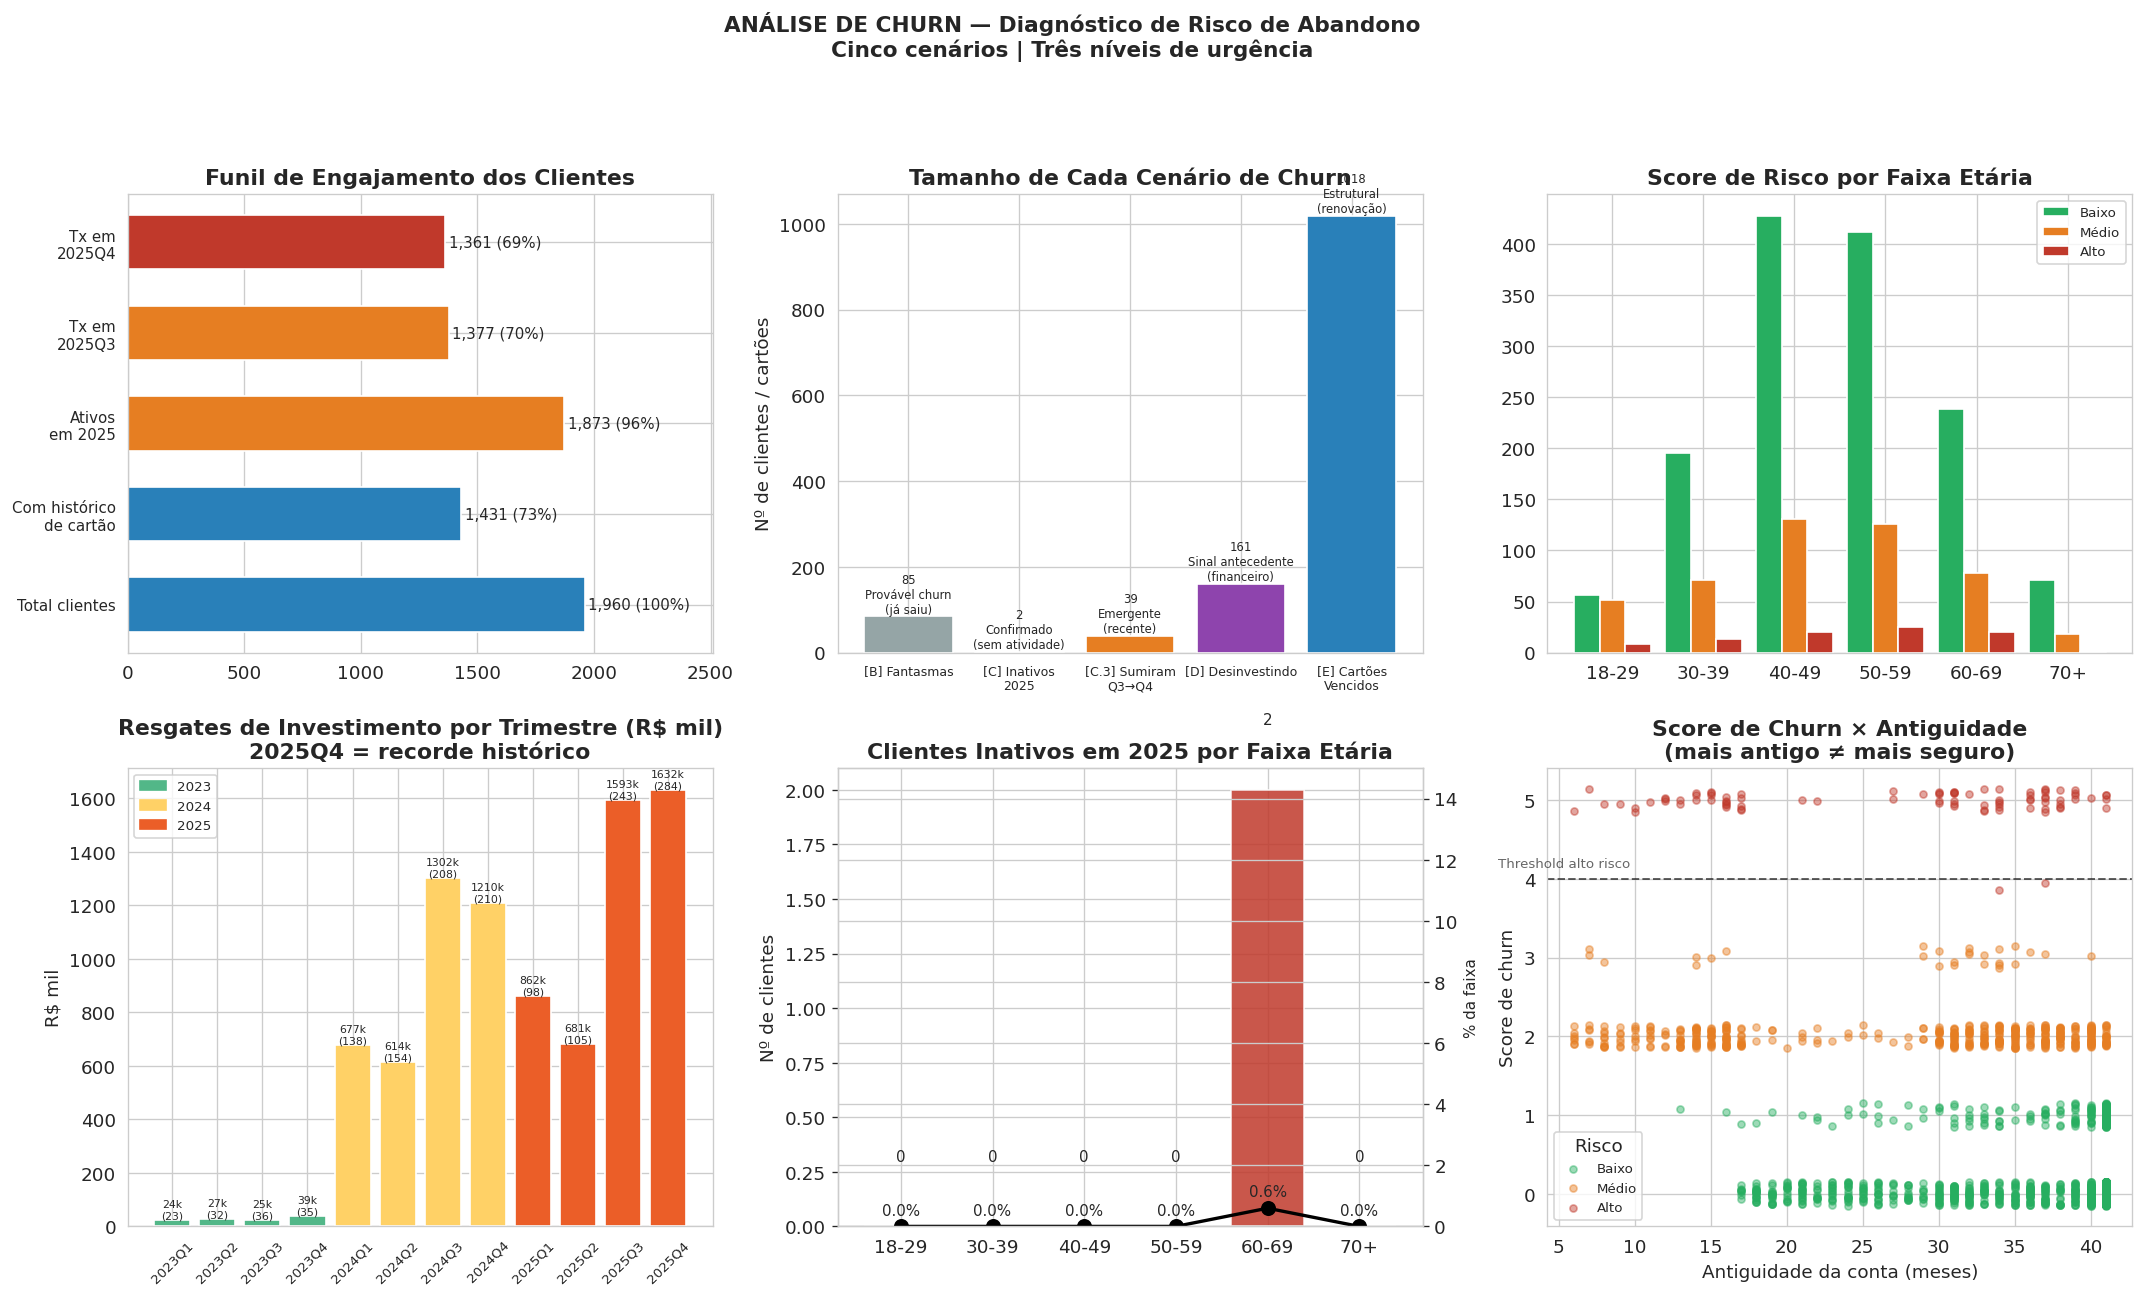


=== KPIs FINAIS ===
[B] Contas fantasma:                85 clientes (4.3%)
[C] Inativos em 2025:                2 clientes (0.1%)
[C.3] Sumiram Q3→Q4/2025:          39 clientes
[D] Desinvestindo em 2025:         161 clientes (16.1% dos investidores)
[E] Cartões vencidos:             1018 cartões (28.6% do portfolio)
Score alto risco (≥4):              87 clientes
Resgates 2025Q4: R$1632k — recorde histórico


In [18]:
VERMELHO='#c0392b'; LARANJA='#e67e22'; VERDE='#27ae60'
CINZA='#95a5a6'; AZUL='#2980b9'; ROXO='#8e44ad'

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('ANÁLISE DE CHURN — Diagnóstico de Risco de Abandono\n'
             'Cinco cenários | Três níveis de urgência', fontsize=13, fontweight='bold')

# P1: Funil de engajamento
n_ativos_2025 = len(ativos_2025 & todos)
funil_l = ['Total clientes','Com histórico\nde cartão','Ativos\nem 2025','Tx em\n2025Q3','Tx em\n2025Q4']
funil_v = [len(todos), len(tx_hist), n_ativos_2025, len(tx_q3_25), len(tx_q4_25)]
funil_c = [AZUL, AZUL, LARANJA, LARANJA, VERMELHO]
bars = axes[0,0].barh(range(len(funil_v)), funil_v, color=funil_c, edgecolor='white', height=0.6)
axes[0,0].set_yticks(range(len(funil_l)))
axes[0,0].set_yticklabels(funil_l, fontsize=9)
axes[0,0].set_title('Funil de Engajamento dos Clientes', fontweight='bold')
for bar, v in zip(bars, funil_v):
    axes[0,0].text(v+15, bar.get_y()+bar.get_height()/2,
                   f'{v:,} ({v/len(todos)*100:.0f}%)', va='center', fontsize=9)
axes[0,0].set_xlim(0, len(todos)*1.28)

# P2: Tamanho de cada cenário
ch_l = ['[B] Fantasmas','[C] Inativos\n2025','[C.3] Sumiram\nQ3→Q4','[D] Desinvestindo','[E] Cartões\nVencidos']
ch_v = [len(fantasmas), len(inativos_2025), len(tx_q3_25-tx_q4_25), len(desinvest_ids), len(vencidos)]
ch_c = [CINZA, VERMELHO, LARANJA, ROXO, AZUL]
ch_u = ['Provável churn\n(já saiu)', 'Confirmado\n(sem atividade)', 'Emergente\n(recente)',
        'Sinal antecedente\n(financeiro)', 'Estrutural\n(renovação)']
b2 = axes[0,1].bar(range(len(ch_v)), ch_v, color=ch_c, edgecolor='white')
axes[0,1].set_xticks(range(len(ch_l))); axes[0,1].set_xticklabels(ch_l, fontsize=7.5)
axes[0,1].set_title('Tamanho de Cada Cenário de Churn', fontweight='bold')
axes[0,1].set_ylabel('Nº de clientes / cartões')
for b, v, u in zip(b2, ch_v, ch_u):
    axes[0,1].text(b.get_x()+b.get_width()/2, v+8, f'{v}\n{u}', ha='center', fontsize=7)

# P3: Score de risco por faixa
rf = df_score.groupby(['Faixa','risco'], observed=True).size().unstack(fill_value=0)
for col in ['Baixo','Médio','Alto']:
    if col not in rf.columns: rf[col] = 0
x3 = np.arange(len(rf)); w3 = 0.28
axes[0,2].bar(x3-w3, rf['Baixo'], w3, color=VERDE,    edgecolor='white', label='Baixo')
axes[0,2].bar(x3,    rf['Médio'], w3, color=LARANJA,  edgecolor='white', label='Médio')
axes[0,2].bar(x3+w3, rf['Alto'],  w3, color=VERMELHO, edgecolor='white', label='Alto')
axes[0,2].set_xticks(x3); axes[0,2].set_xticklabels(rf.index)
axes[0,2].set_title('Score de Risco por Faixa Etária', fontweight='bold')
axes[0,2].legend(fontsize=8)

# P4: Resgates acelerando
rq = resg_q.copy(); rq['vol_abs'] = rq['sum'].abs() / 1e3
anos_c = {'2023':'#52b788','2024':'#ffd166','2025':'#eb5e28'}
bc4 = [anos_c[p[:4]] for p in rq.index]
b4 = axes[1,0].bar(range(len(rq)), rq['vol_abs'], color=bc4, edgecolor='white')
axes[1,0].set_xticks(range(len(rq))); axes[1,0].set_xticklabels(rq.index, rotation=45, fontsize=8)
axes[1,0].set_title('Resgates de Investimento por Trimestre (R$ mil)\n2025Q4 = recorde histórico', fontweight='bold')
axes[1,0].set_ylabel('R$ mil')
for b, v, c2 in zip(b4, rq['vol_abs'], rq['count']):
    axes[1,0].text(b.get_x()+b.get_width()/2, v+5, f'{v:.0f}k\n({c2})', ha='center', fontsize=6.5)
axes[1,0].legend(handles=[mpatches.Patch(color=c, label=a) for a,c in anos_c.items()], fontsize=8)

# P5: Inativos 2025 por faixa
inat_f = base_clientes[base_clientes['Cliente_ID'].isin(inativos_2025)].groupby('Faixa', observed=True).size()
tot_f  = base_clientes.groupby('Faixa', observed=True).size()
inat_f = inat_f.reindex(tot_f.index, fill_value=0)
pct_f  = (inat_f / tot_f * 100).fillna(0)
x5 = np.arange(len(inat_f))
b5 = axes[1,1].bar(x5, inat_f.values, color=VERMELHO, edgecolor='white', alpha=0.85)
ax5b = axes[1,1].twinx()
ax5b.plot(x5, pct_f.values, color='black', linewidth=2, marker='o', markersize=8)
ax5b.set_ylabel('% da faixa', fontsize=9); ax5b.set_ylim(0, 15)
for xi, pct in zip(x5, pct_f.values):
    ax5b.annotate(f'{pct:.1f}%', (xi, pct), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=9)
axes[1,1].set_xticks(x5); axes[1,1].set_xticklabels(inat_f.index)
axes[1,1].set_title('Clientes Inativos em 2025 por Faixa Etária', fontweight='bold')
axes[1,1].set_ylabel('Nº de clientes')
for b, v in zip(b5, inat_f.values): axes[1,1].text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha='center', fontsize=9)

# P6: Score × Antiguidade scatter
cores_r = {'Baixo':VERDE,'Médio':LARANJA,'Alto':VERMELHO}
for risco_val, grp in df_score.groupby('risco', observed=True):
    axes[1,2].scatter(grp['Antiguidade_Meses'],
                      grp['score'] + np.random.uniform(-0.15, 0.15, len(grp)),
                      c=cores_r.get(str(risco_val), CINZA), alpha=0.45, s=18, label=str(risco_val))
axes[1,2].axhline(4, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[1,2].text(1, 4.15, 'Threshold alto risco', fontsize=8, alpha=0.7)
axes[1,2].set_xlabel('Antiguidade da conta (meses)')
axes[1,2].set_ylabel('Score de churn')
axes[1,2].set_title('Score de Churn × Antiguidade\n(mais antigo ≠ mais seguro)', fontweight='bold')
axes[1,2].legend(title='Risco', fontsize=8)

plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('docs/analise_churn.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n=== KPIs FINAIS ===')
print(f'[B] Contas fantasma:              {len(fantasmas):>4} clientes ({len(fantasmas)/len(todos)*100:.1f}%)')
print(f'[C] Inativos em 2025:             {len(inativos_2025):>4} clientes ({len(inativos_2025)/len(todos)*100:.1f}%)')
print(f'[C.3] Sumiram Q3→Q4/2025:        {len(tx_q3_25-tx_q4_25):>4} clientes')
print(f'[D] Desinvestindo em 2025:        {len(desinvest_ids):>4} clientes ({len(desinvest_ids)/len(inv_hist)*100:.1f}% dos investidores)')
print(f'[E] Cartões vencidos:             {len(vencidos):>4} cartões ({len(vencidos)/len(cart_validos)*100:.1f}% do portfolio)')
print(f'Score alto risco (≥4):            {(df_score["risco"]=="Alto").sum():>4} clientes')
print(f'Resgates 2025Q4: R${abs(resg_q.loc["2025Q4","sum"])/1e3:.0f}k — recorde histórico')

---
## 10. Radar de Qualidade — Todas as Pegadinhas

In [19]:
issues = [
    ('Notebook',      'CRITICO',  'base_investimentos carregava Base_clientes.csv',        1,     'CRITICO', 'Bug no codigo original — dado errado!',          'Corrigido neste notebook'),
    ('Cartoes',       'ERRO',     'Data_Ativacao < Data_Emissao',                        450,     'Medio',   'Bug na geracao de dados',                        'Excluir esses 450 da analise temporal'),
    ('Cartoes',       'ERRO',     'Data_Validade nula (mesmo grupo dos 450)',             450,     'Medio',   'Ligado ao problema anterior',                    'Excluir da analise temporal'),
    ('Cartoes',       'ANALISE',  'Cartoes sem nenhuma transacao',                       469,     'Alto',    '11.7% nunca usados — falha de onboarding',       'Investigar segmentos e produtos'),
    ('Clientes',      'NULO',     'Renda_Anual nula',                                    255,     'Medio',   '13% sem renda declarada',                        'Imputar mediana ou flag separado'),
    ('Transacoes',    'ANALISE',  'Crossborder NULL 95.6%',                           149912,     'Baixo',   'Por design: so em CNP online',                   'Usar apenas onde nao eh nulo'),
    ('Transacoes',    'ANALISE',  'Contactless NULL 82.5%',                           129332,     'Baixo',   'Por design: so em fisico',                       'Usar apenas onde nao eh nulo'),
    ('Transacoes',    'ERRO',     'Valor_Compra negativo',                               165,     'Medio',   'Possiveis estornos/chargebacks',                  'Excluir ou criar flag estorno'),
    ('Transacoes',    'ANALISE',  'Outliers > R$10k',                                     84,     'Medio',   'Transacoes extremas distorcem media',             'Tratar separado na analise'),
    ('PIX',           'ERRO',     'Valor negativo',                                      917,     'Alto',    'PIX com valor negativo — incoerente',             'Investigar — possivelmente estornos'),
    ('PIX',           'ERRO',     'Valor zero',                                          591,     'Alto',    'PIX de R$0,00 sem sentido',                      'Excluir da analise'),
    ('PIX',           'NULO',     'Data e Tipo_transacao nulos',                         418,     'Medio',   'Registros incompletos',                           'Excluir da analise temporal'),
    ('PIX',           'SUSPEITO', 'Recebimento com Aprovado=0',                         3392,     'Alto',    'Recebimento negado — suspeito',                  'Investigar — pode ser fraude'),
    ('Investimentos', 'ANALISE',  'Valor_Aplicado negativo (resgates)',                 1566,     'Baixo',   'Comportamento normal de carteira',                'Separar aportes de resgates'),
    ('Investimentos', 'ANALISE',  'Data_vencimento=299901 (Reservinha)',                7864,     'Baixo',   'Por design — liquidez diaria sem vencimento',     'Tratar como produto especial'),
]

df_iss = pd.DataFrame(issues, columns=['Base','Tipo','Problema','Qtd','Impacto','Explicacao','Acao'])

def ci(v): return {'CRITICO':'background-color:#8b0000;color:white','Alto':'background-color:#c0392b;color:white',
                    'Medio':'background-color:#e67e22;color:white','Baixo':'background-color:#27ae60;color:white'}.get(v,'')
def ct(v): return {'CRITICO':'background-color:#8b0000;color:white','ERRO':'background-color:#c0392b;color:white',
                    'SUSPEITO':'background-color:#8e44ad;color:white','NULO':'background-color:#e67e22;color:white',
                    'ANALISE':'background-color:#2980b9;color:white'}.get(v,'')

print(f'Total: {len(df_iss)} problemas | CRITICO: {(df_iss["Impacto"]=="CRITICO").sum()} | Alto: {(df_iss["Impacto"]=="Alto").sum()} | Medio: {(df_iss["Impacto"]=="Medio").sum()} | Baixo: {(df_iss["Impacto"]=="Baixo").sum()}')
(df_iss.style.applymap(ci, subset=['Impacto']).applymap(ct, subset=['Tipo'])
  .set_properties(**{'font-size':'10px'}).hide(axis='index'))

Total: 15 problemas | CRITICO: 1 | Alto: 4 | Medio: 6 | Baixo: 4


Base,Tipo,Problema,Qtd,Impacto,Explicacao,Acao
Notebook,CRITICO,base_investimentos carregava Base_clientes.csv,1,CRITICO,Bug no codigo original — dado errado!,Corrigido neste notebook
Cartoes,ERRO,Data_Ativacao < Data_Emissao,450,Medio,Bug na geracao de dados,Excluir esses 450 da analise temporal
Cartoes,ERRO,Data_Validade nula (mesmo grupo dos 450),450,Medio,Ligado ao problema anterior,Excluir da analise temporal
Cartoes,ANALISE,Cartoes sem nenhuma transacao,469,Alto,11.7% nunca usados — falha de onboarding,Investigar segmentos e produtos
Clientes,NULO,Renda_Anual nula,255,Medio,13% sem renda declarada,Imputar mediana ou flag separado
Transacoes,ANALISE,Crossborder NULL 95.6%,149912,Baixo,Por design: so em CNP online,Usar apenas onde nao eh nulo
Transacoes,ANALISE,Contactless NULL 82.5%,129332,Baixo,Por design: so em fisico,Usar apenas onde nao eh nulo
Transacoes,ERRO,Valor_Compra negativo,165,Medio,Possiveis estornos/chargebacks,Excluir ou criar flag estorno
Transacoes,ANALISE,Outliers > R$10k,84,Medio,Transacoes extremas distorcem media,Tratar separado na analise
PIX,ERRO,Valor negativo,917,Alto,PIX com valor negativo — incoerente,Investigar — possivelmente estornos


---
## 11. Ranking das Bases — Criticidade para o Diagnóstico

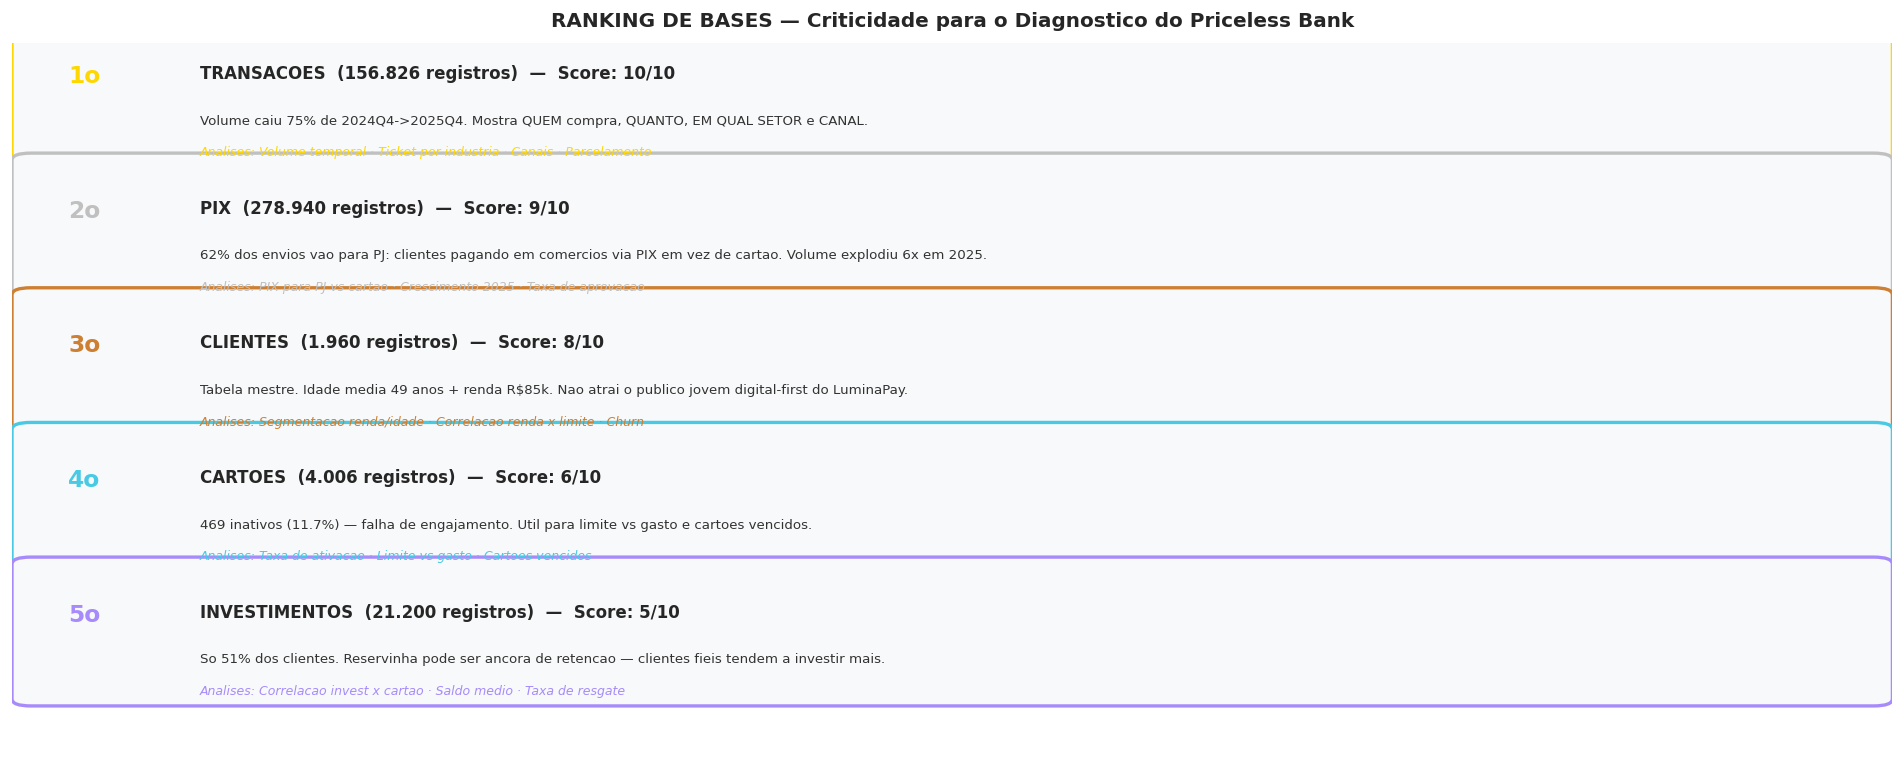

In [20]:
ranking = [
    ('1o','Transacoes',   '156.826','10/10','Volume caiu 75% de 2024Q4->2025Q4. Mostra QUEM compra, QUANTO, EM QUAL SETOR e CANAL.','Volume temporal · Ticket por industria · Canais · Parcelamento','#FFD700'),
    ('2o','PIX',          '278.940', '9/10','62% dos envios vao para PJ: clientes pagando em comercios via PIX em vez de cartao. Volume explodiu 6x em 2025.','PIX para PJ vs cartao · Crescimento 2025 · Taxa de aprovacao','#C0C0C0'),
    ('3o','Clientes',      '1.960',  '8/10','Tabela mestre. Idade media 49 anos + renda R$85k. Nao atrai o publico jovem digital-first do LuminaPay.','Segmentacao renda/idade · Correlacao renda x limite · Churn','#CD7F32'),
    ('4o','Cartoes',       '4.006',  '6/10','469 inativos (11.7%) — falha de engajamento. Util para limite vs gasto e cartoes vencidos.','Taxa de ativacao · Limite vs gasto · Cartoes vencidos','#48cae4'),
    ('5o','Investimentos','21.200',  '5/10','So 51% dos clientes. Reservinha pode ser ancora de retencao — clientes fieis tendem a investir mais.','Correlacao invest x cartao · Saldo medio · Taxa de resgate','#a78bfa'),
]

fig, ax = plt.subplots(figsize=(16, 6.5))
ax.axis('off')
for i,(rank,base,regs,score,just,analises,cor) in enumerate(ranking):
    y = 0.9 - i*0.19
    ax.add_patch(mpatches.FancyBboxPatch((0.01,y-0.065), 0.98, 0.19,
        boxstyle='round,pad=0.01', linewidth=2, edgecolor=cor, facecolor='#f8f9fa'))
    ax.text(0.03, y+0.07, rank,  fontsize=14, fontweight='bold', va='top', color=cor)
    ax.text(0.10, y+0.07, f'{base.upper()}  ({regs} registros)  —  Score: {score}', fontsize=10, fontweight='bold', va='top')
    ax.text(0.10, y+0.00, just,    fontsize=8, va='top', color='#333333')
    ax.text(0.10, y-0.045, f'Analises: {analises}', fontsize=7.5, va='top', color=cor, style='italic')
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title('RANKING DE BASES — Criticidade para o Diagnostico do Priceless Bank', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('docs/ranking_bases.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 12. Key Insights — Diagnóstico Preliminar

> Estes insights orientam as hipóteses para a apresentação final ao Comitê Executivo da Mastercard.

### 🔴 Insight 1 — Canibalização do Cartão pelo PIX [CRÍTICO]
Volume por cartão **caiu ~75%** de 2024Q4 para 2025Q4. PIX **cresceu 6x** no mesmo período. **62% dos PIX vão para PJ** — clientes pagando em estabelecimentos via PIX em vez do cartão. Hipótese: LuminaPay oferece PIX no crédito; o Priceless Bank não tem equivalente.

### 🔴 Insight 2 — 11,7% dos Cartões Nunca Foram Usados [CRÍTICO]
**469 cartões** emitidos e nunca utilizados. Falha de onboarding ou ausência de incentivo pós-emissão — forte preditor de churn futuro.

### 🟡 Insight 3 — Perfil Demográfico Desalinhado com o Mercado em Crescimento
Idade média **49 anos**, renda média **R$85k**. O LuminaPay (principal ganhador) foca em jovens adultos e early adopters — público que o Priceless Bank não está capturando.

### 🟡 Insight 4 — Taxa de Reprovação de PIX Elevada
**10% dos envios não aprovados** (24.644 registros). Taxa anormalmente alta — pode indicar fraude, limites restritivos ou fricção no processo digital.

### 🟢 Insight 5 — Reservinha como Âncora de Retenção Subutilizada
**37% dos registros de investimento** são da Reservinha (liquidez diária). Clientes com investimentos ativos tendem a ser mais fiéis — pode ser alavancada como diferencial competitivo.

---
### Próximos Passos
1. **Mapa de fugitivos:** Clientes com queda de cartão + aumento de PIX para PJ
2. **Segmento em risco:** Qual faixa etária/renda mais reduziu uso do cartão em 2025?
3. **Hipótese de fidelidade:** Clientes com investimento têm maior gasto no cartão?
4. **Cartões inativos:** Quais produtos/segmentos concentram mais não-ativações?

Idade media da base ............: 49.6 anos
% clientes <= 35 anos (Priceless): 11.9%
% captura jovem da LuminaPay ....: 30%
Gap de juventude ................: 18.1 p.p.

Novas contas por ano:
Ano_Criacao
2023    1547
2024     224
2025     189


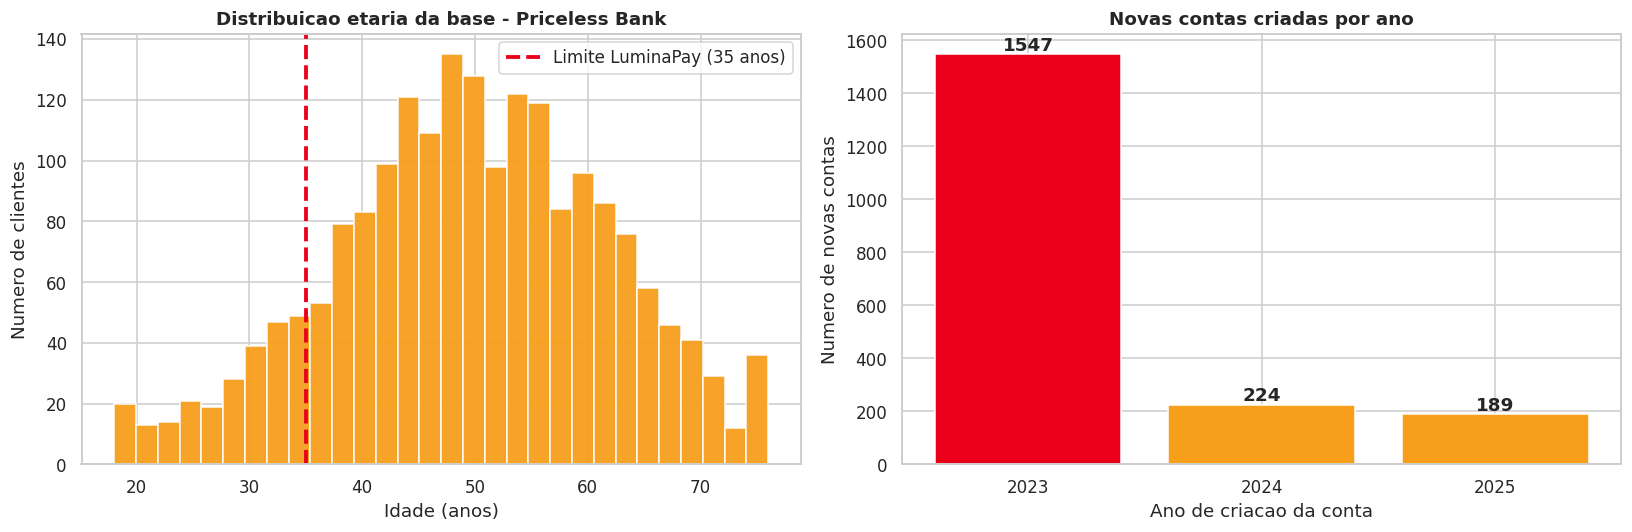

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Paleta Mastercard ---
MC_RED = '#EB001B'      # Vermelho Mastercard
MC_ORANGE = '#F79E1B'   # Laranja Mastercard
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

# --- Caminhos e referencia temporal ---
DATA = Path('data') if Path('data').exists() else Path('../data')
GRAF = Path('graficos'); GRAF.mkdir(exist_ok=True)
HOJE = pd.Timestamp('2025-12-31')   # data de referencia ("hoje")

# --- Carga das bases ---
clientes      = pd.read_csv(DATA / 'Base_clientes.csv')
cartoes       = pd.read_csv(DATA / 'Base_cartoes.csv')
transacoes    = pd.read_csv(DATA / 'Base_transacoes.csv')
pix           = pd.read_csv(DATA / 'Base_pix.csv')
investimentos = pd.read_csv(DATA / 'Base_investimentos.csv')

# ============================================================
# H1 - Perfil etario e ritmo de aquisicao de clientes
# ============================================================
clientes['Data_Nascimento'] = pd.to_datetime(clientes['Data_Nascimento'], dayfirst=True, errors='coerce')
clientes['Idade'] = ((HOJE - clientes['Data_Nascimento']).dt.days / 365.25)

clientes['Data_Criacao_Conta'] = pd.to_datetime(clientes['Data_Criacao_Conta'], errors='coerce')
clientes['Ano_Criacao'] = clientes['Data_Criacao_Conta'].dt.year

LUMINA_JOVENS = 30.0  # % de jovens (<=35) que a LuminaPay captura
idade_media   = clientes['Idade'].mean()
pct_jovens    = (clientes['Idade'] <= 35).mean() * 100
gap_jovens    = LUMINA_JOVENS - pct_jovens
novas_por_ano = clientes['Ano_Criacao'].value_counts().reindex([2023, 2024, 2025]).fillna(0).astype(int)

print(f'Idade media da base ............: {idade_media:.1f} anos')
print(f'% clientes <= 35 anos (Priceless): {pct_jovens:.1f}%')
print(f'% captura jovem da LuminaPay ....: {LUMINA_JOVENS:.0f}%')
print(f'Gap de juventude ................: {gap_jovens:.1f} p.p.')
print('\nNovas contas por ano:')
print(novas_por_ano.to_string())

# --- Graficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# (1) Histograma de idade com linha vertical em 35 anos
ax1.hist(clientes['Idade'].dropna(), bins=30, color=MC_ORANGE, edgecolor='white', alpha=0.95)
ax1.axvline(35, color=MC_RED, linestyle='--', linewidth=2.5, label='Limite LuminaPay (35 anos)')
ax1.set_title('Distribuicao etaria da base - Priceless Bank')
ax1.set_xlabel('Idade (anos)')
ax1.set_ylabel('Numero de clientes')
ax1.legend()

# (2) Novas contas por ano
bars = ax2.bar(novas_por_ano.index.astype(str), novas_por_ano.values,
               color=[MC_RED, MC_ORANGE, MC_ORANGE])
ax2.set_title('Novas contas criadas por ano')
ax2.set_xlabel('Ano de criacao da conta')
ax2.set_ylabel('Numero de novas contas')
for b in bars:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height(),
             f'{int(b.get_height())}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(GRAF / 'h1_perfil_etario.png', bbox_inches='tight')
plt.show()

Clientes totais .............: 1960
Ativos no cartao em 2025 ....: 1427 (72.8%)
Inativos no cartao em 2025 ..: 533 (27.2%)
Queda de volume Q1->Q4/2025 .: -49.8%
% transacoes via Wallet .....: 14.1%

Volume trimestral 2025 (R$):
Trimestre
2025Q1    11,773,002
2025Q2    11,452,655
2025Q3     7,796,294
2025Q4     5,914,692
Freq: Q-DEC


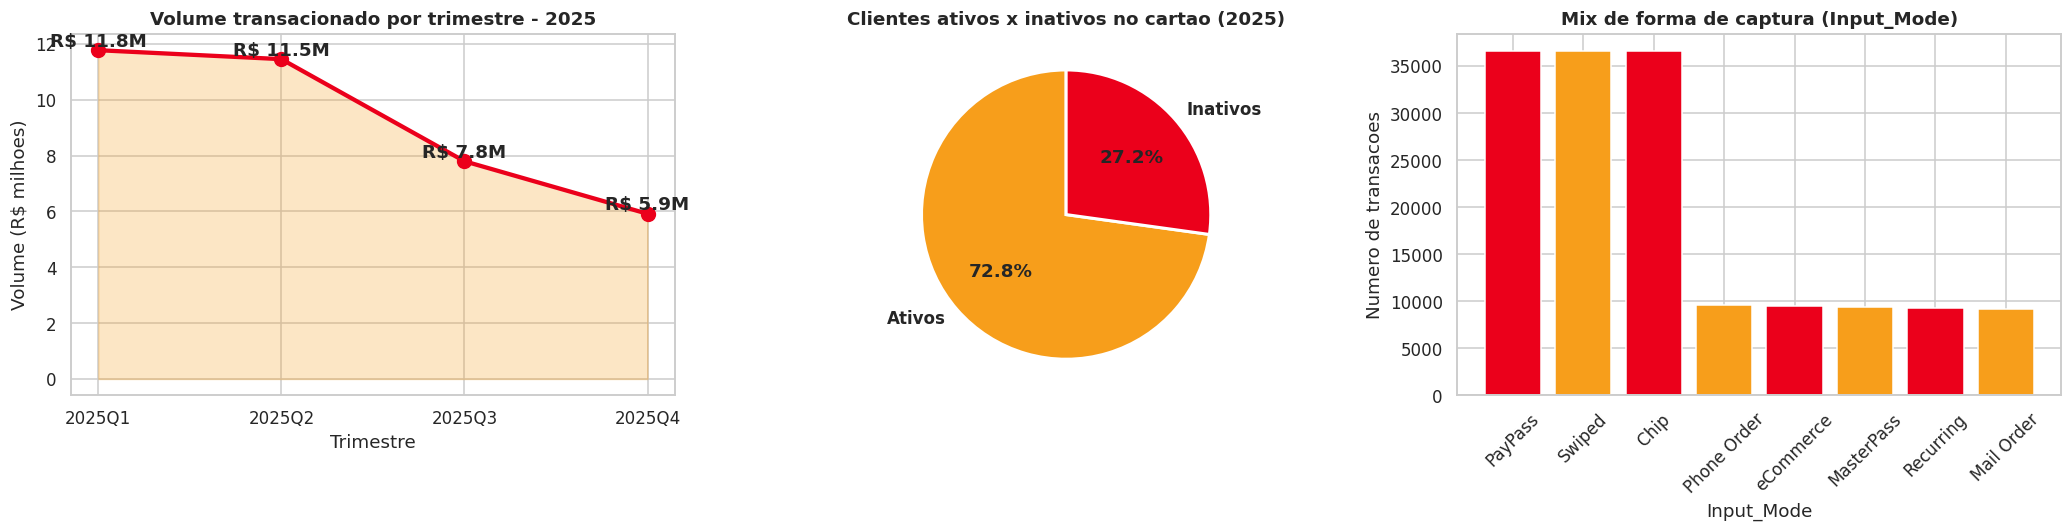

In [22]:
transacoes['Data'] = pd.to_datetime(transacoes['Data'], errors='coerce')

tx_2025   = transacoes[transacoes['Data'].dt.year == 2025].copy()
total_cli = clientes['Cliente_ID'].nunique()
ativos    = tx_2025['Cliente_ID'].nunique()
inativos  = total_cli - ativos
pct_inativos = inativos / total_cli * 100

# Volume transacionado por trimestre em 2025
tx_2025['Trimestre'] = tx_2025['Data'].dt.to_period('Q')
vol_trimestral = tx_2025.groupby('Trimestre')['Valor_Compra'].sum()
queda_ano = (vol_trimestral.iloc[-1] / vol_trimestral.iloc[0] - 1) * 100

# Penetracao de wallet digital (Apple/Google/Samsung Pay)
pct_wallet = transacoes['Wallet'].notna().mean() * 100

# Mix de Input_Mode
mix_input = transacoes['Input_Mode'].value_counts()

print(f'Clientes totais .............: {total_cli}')
print(f'Ativos no cartao em 2025 ....: {ativos} ({ativos/total_cli*100:.1f}%)')
print(f'Inativos no cartao em 2025 ..: {inativos} ({pct_inativos:.1f}%)')
print(f'Queda de volume Q1->Q4/2025 .: {queda_ano:.1f}%')
print(f'% transacoes via Wallet .....: {pct_wallet:.1f}%')
print('\nVolume trimestral 2025 (R$):')
print(vol_trimestral.apply(lambda v: f'{v:,.0f}').to_string())

# --- Graficos ---
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# (1) Linha do volume trimestral
x = vol_trimestral.index.astype(str)
axes[0].plot(x, vol_trimestral.values / 1e6, marker='o', color=MC_RED, linewidth=2.8, markersize=9)
axes[0].fill_between(range(len(x)), vol_trimestral.values / 1e6, color=MC_ORANGE, alpha=0.25)
axes[0].set_title('Volume transacionado por trimestre - 2025')
axes[0].set_xlabel('Trimestre')
axes[0].set_ylabel('Volume (R$ milhoes)')
for i, v in enumerate(vol_trimestral.values / 1e6):
    axes[0].text(i, v, f'R$ {v:.1f}M', ha='center', va='bottom', fontweight='bold')

# (2) Ativos vs inativos no cartao
axes[1].pie([ativos, inativos], labels=['Ativos', 'Inativos'],
            colors=[MC_ORANGE, MC_RED], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontweight': 'bold'})
axes[1].set_title('Clientes ativos x inativos no cartao (2025)')

# (3) Mix de Input_Mode
cores = [MC_RED if i % 2 == 0 else MC_ORANGE for i in range(len(mix_input))]
axes[2].bar(mix_input.index, mix_input.values, color=cores)
axes[2].set_title('Mix de forma de captura (Input_Mode)')
axes[2].set_xlabel('Input_Mode')
axes[2].set_ylabel('Numero de transacoes')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(GRAF / 'h2_atividade_transacional.png', bbox_inches='tight')
plt.show()

## 14. Recuperação de Faturamento — Dimensão da Perda e Projeções

Tradução da tese de `docs/propostas-solucao.md` em números: **(1)** o tamanho da perda de faturamento de intercâmbio causada pela inversão cartão→PIX e **(2)** a projeção de receita gerada pela solução (Priceless Pay) em três cenários — **pessimista, neutro e otimista**.

**Premissas de intercâmbio:** crédito 1,8% · débito 0,6% · taxa ponderada do portfólio calculada pelo split real de volume. Ticket-base normalizado R$614 (mediana 2023/2025) para neutralizar a anomalia de ticket de 2024.

In [ ]:
# ===== PARTE 1: DIMENSAO DA PERDA DE FATURAMENTO (INTERCAMBIO) =====
IC_CRED, IC_DEB = 0.018, 0.006
TICKET_BASE = 614

# taxa ponderada pelo split real credito x debito (por volume)
_tok = base_transacoes[base_transacoes['Valor_Compra'] > 0].merge(
    base_cartoes[['ID_Cartao','Tipo_Cartao']], on='ID_Cartao', how='left')
vol_cred = _tok.loc[_tok['Tipo_Cartao']=='Crédito','Valor_Compra'].sum()
vol_deb  = _tok.loc[_tok['Tipo_Cartao']=='Débito', 'Valor_Compra'].sum()
IC_BLEND = (vol_cred*IC_CRED + vol_deb*IC_DEB) / (vol_cred + vol_deb)

# cartao por trimestre
tk = base_transacoes[base_transacoes['Valor_Compra']>0].copy()
tk['YQ'] = tk['Data'].dt.to_period('Q').astype(str)
cq = tk.groupby('YQ')['Valor_Compra'].agg(vol='sum', qtd='count')

# Perda 1: colapso do intercambio de cartao (2024Q4 normalizado -> 2025Q4 real)
ic_2024q4_norm = cq.loc['2024Q4','qtd'] * TICKET_BASE * IC_BLEND
ic_2025q4      = cq.loc['2025Q4','vol'] * IC_BLEND
queda_cartao_tri = ic_2024q4_norm - ic_2025q4
queda_cartao_ano = queda_cartao_tri * 4

# Perda 2: oportunidade nao capturada no PIX->PJ (intercambio zero)
px = pix_clean[pix_clean['Tipo_transacao']=='Envio'].copy()  # pix_clean: Aprovado=1 já aplicado
px['YQ'] = px['Data'].dt.to_period('Q').astype(str)
ppj = px[px['PF_PJ']=='PJ'].groupby('YQ')['Valor'].agg(vol='sum', qtd='count')
pixpj_q4 = ppj.loc['2025Q4','vol']
ic_pixpj_q4_tri = pixpj_q4 * IC_CRED   # recuperado vira CREDITO -> taxa de credito (1,8%)
ic_pixpj_ano    = ic_pixpj_q4_tri * 4

perda_total_ano = queda_cartao_ano + ic_pixpj_ano

print(f'Taxa de intercambio ponderada do portfolio: {IC_BLEND*100:.2f}%  '
      f'(split {vol_cred/(vol_cred+vol_deb)*100:.1f}% credito / {vol_deb/(vol_cred+vol_deb)*100:.1f}% debito)')
print('\n--- PERDA 1: Colapso do intercambio de cartao ---')
print(f'  Intercambio 2024Q4 (normalizado, pico de engajamento): R$ {ic_2024q4_norm:>10,.0f}/tri')
print(f'  Intercambio 2025Q4 (real):                             R$ {ic_2025q4:>10,.0f}/tri')
print(f'  >> Queda: R$ {queda_cartao_tri:,.0f}/tri  =  R$ {queda_cartao_ano:,.0f}/ano')
print('\n--- PERDA 2: Oportunidade nao capturada no PIX->PJ ---')
print(f'  PIX->PJ 2025Q4: R$ {pixpj_q4:,.0f}  ({ppj.loc["2025Q4","qtd"]:,.0f} transacoes, intercambio ZERO)')
print(f'  Intercambio potencial @ {IC_CRED*100:.2f}%: R$ {ic_pixpj_q4_tri:,.0f}/tri  =  R$ {ic_pixpj_ano:,.0f}/ano')
print('\n' + '='*60)
print(f'PERDA TOTAL DE FATURAMENTO: R$ {perda_total_ano:,.0f}/ano  (~R$ {perda_total_ano/1e6:.2f} M/ano)')
print('='*60)

Taxa de intercambio ponderada do portfolio: 1.60%  (split 83.6% credito / 16.4% debito)

--- PERDA 1: Colapso do intercambio de cartao ---
  Intercambio 2024Q4 (normalizado, pico de engajamento): R$    148,814/tri
  Intercambio 2025Q4 (real):                             R$     94,879/tri
  >> Queda: R$ 53,934/tri  =  R$ 215,737/ano

--- PERDA 2: Oportunidade nao capturada no PIX->PJ ---
  PIX->PJ 2025Q4: R$ 17,914,054  (17,674 transacoes, intercambio ZERO)
  Intercambio potencial @ 1.80%: R$ 322,453/tri  =  R$ 1,289,812/ano

PERDA TOTAL DE FATURAMENTO: R$ 1,505,549/ano  (~R$ 1.51 M/ano)


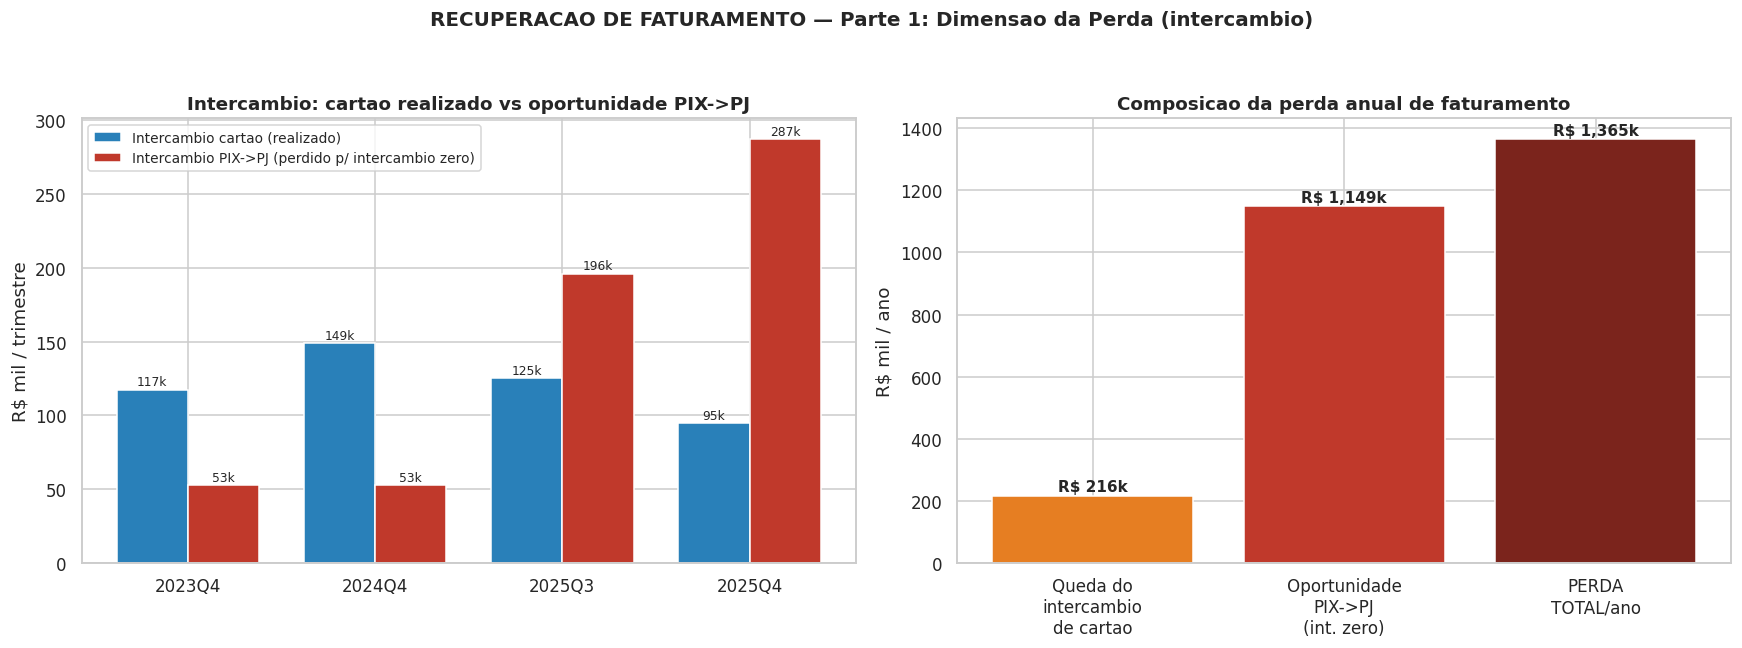

In [24]:
# ===== GRAFICO: dimensao da perda =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RECUPERACAO DE FATURAMENTO — Parte 1: Dimensao da Perda (intercambio)', fontsize=13, fontweight='bold')

# P1: intercambio cartao (normalizado) vs oportunidade PIX->PJ por trimestre
quarts = ['2023Q4','2024Q4','2025Q3','2025Q4']
ic_cart = [cq.loc[q,'qtd']*TICKET_BASE*IC_BLEND/1e3 if q in ('2023Q4','2024Q4') else cq.loc[q,'vol']*IC_BLEND/1e3 for q in quarts]
ic_ppj  = [ppj.loc[q,'vol']*IC_BLEND/1e3 if q in ppj.index else 0 for q in quarts]
x = np.arange(len(quarts)); w=0.38
axes[0].bar(x-w/2, ic_cart, w, color='#2980b9', edgecolor='white', label='Intercambio cartao (realizado)')
axes[0].bar(x+w/2, ic_ppj,  w, color='#c0392b', edgecolor='white', label='Intercambio PIX->PJ (perdido p/ intercambio zero)')
axes[0].set_xticks(x); axes[0].set_xticklabels(quarts)
axes[0].set_ylabel('R$ mil / trimestre'); axes[0].set_title('Intercambio: cartao realizado vs oportunidade PIX->PJ', fontweight='bold')
axes[0].legend(fontsize=9)
for xi,(a,b) in enumerate(zip(ic_cart, ic_ppj)):
    axes[0].text(xi-w/2, a+3, f'{a:.0f}k', ha='center', fontsize=8)
    if b>0: axes[0].text(xi+w/2, b+3, f'{b:.0f}k', ha='center', fontsize=8)

# P2: composicao da perda anual
comp_l = ['Queda do\nintercambio\nde cartao','Oportunidade\nPIX->PJ\n(int. zero)','PERDA\nTOTAL/ano']
comp_v = [queda_cartao_ano/1e3, ic_pixpj_ano/1e3, perda_total_ano/1e3]
cores = ['#e67e22','#c0392b','#7b241c']
b2 = axes[1].bar(comp_l, comp_v, color=cores, edgecolor='white')
axes[1].set_ylabel('R$ mil / ano'); axes[1].set_title('Composicao da perda anual de faturamento', fontweight='bold')
for b,v in zip(b2, comp_v):
    axes[1].text(b.get_x()+b.get_width()/2, v+15, f'R$ {v:,.0f}k', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('docs/recuperacao_perda.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ===== PARTE 2: PROJECAO DE RECEITA DA SOLUCAO (3 CENARIOS) =====
# Plataforma GRATUITA: receita-CORE = intercambio + spread de AUM + juros/IOF do parcelado.
# Assinatura premium ('Black') = UPSIDE OPCIONAL, fora do core (nao depende dela para repor a perda).
N = base_clientes['Cliente_ID'].nunique()
PIXPJ_ANO = pixpj_q4 * 4   # run-rate anual a partir de 2025Q4

#  adoc=% base usando Priceless Pay | capt=% do fluxo PIX->PJ capturado | conv=% do capturado roteado p/ credito a vista
#  bal=saldo medio capturavel/cliente (Saldo Vivo) | aumc=% dos adotantes que mantem saldo | spread=spread a.a. sobre AUM
#  parc_pen=% do credito que vira parcelado | parc_marg=margem liq. do parcelado | sub/fee=assinatura (UPSIDE opcional)
cen = {
  'Pessimista': dict(adoc=0.30, capt=0.25, conv=0.30, bal=10000, aumc=0.60, spread=0.010, parc_pen=0.05, parc_marg=0.04, sub=0.05, fee=25),
  'Neutro':     dict(adoc=0.50, capt=0.45, conv=0.50, bal=18000, aumc=0.70, spread=0.015, parc_pen=0.10, parc_marg=0.05, sub=0.12, fee=25),
  'Otimista':   dict(adoc=0.70, capt=0.65, conv=0.65, bal=28000, aumc=0.80, spread=0.020, parc_pen=0.15, parc_marg=0.06, sub=0.25, fee=30),
}
rows = []
for nome, p in cen.items():
    interc   = PIXPJ_ANO * p['capt'] * p['conv'] * IC_CRED   # Pix->PJ recuperado = credito (1,8%)
    aum_pool = N * p['adoc'] * p['aumc'] * p['bal']
    aum_rev  = aum_pool * p['spread']
    vol_conv = PIXPJ_ANO * p['capt'] * p['conv']
    parc     = vol_conv * p['parc_pen'] * p['parc_marg']
    core     = interc + aum_rev + parc                 # receita do modelo GRATUITO
    premium  = N * p['sub'] * p['fee'] * 12            # upside opcional, fora do core
    rows.append(dict(Cenario=nome, Intercambio=interc, AUM=aum_rev, Parcelado=parc,
                     Core=core, Premium_upside=premium, AUM_pool=aum_pool, Repos=core/perda_total_ano))
proj = pd.DataFrame(rows).set_index('Cenario')

print('PROJECAO DE RECEITA INCREMENTAL ANUAL — PLATAFORMA GRATUITA (R$):\n')
for c in proj.index:
    r = proj.loc[c]
    print(f'[{c}]')
    print(f'  Intercambio recuperado : R$ {r.Intercambio:>10,.0f}')
    print(f'  Spread sobre AUM       : R$ {r.AUM:>10,.0f}   (AUM sob gestao: R$ {r.AUM_pool/1e6:,.1f} M)')
    print(f'  Juros/IOF parcelado    : R$ {r.Parcelado:>10,.0f}')
    print(f'  --------------------------------------------')
    print(f'  CORE (gratis)          : R$ {r.Core:>10,.0f}/ano  =  {r.Repos*100:>3.0f}% da perda (R$ {perda_total_ano:,.0f})')
    print(f'  (+) premium opcional   : R$ {r.Premium_upside:>10,.0f}   ->  total c/ upside: R$ {r.Core + r.Premium_upside:,.0f}')
    print()

PROJECAO DE RECEITA INCREMENTAL ANUAL — PLATAFORMA GRATUITA (R$):

[Pessimista]
  Intercambio recuperado : R$     96,736
  Spread sobre AUM       : R$     35,280   (AUM sob gestao: R$ 3.5 M)
  Juros/IOF parcelado    : R$     10,748
  --------------------------------------------
  CORE (gratis)          : R$    142,764/ano  =    9% da perda (R$ 1,505,549)
  (+) premium opcional   : R$     29,400   ->  total c/ upside: R$ 172,164

[Neutro]
  Intercambio recuperado : R$    290,208
  Spread sobre AUM       : R$    185,220   (AUM sob gestao: R$ 12.3 M)
  Juros/IOF parcelado    : R$     80,613
  --------------------------------------------
  CORE (gratis)          : R$    556,041/ano  =   37% da perda (R$ 1,505,549)
  (+) premium opcional   : R$     70,560   ->  total c/ upside: R$ 626,601

[Otimista]
  Intercambio recuperado : R$    544,946
  Spread sobre AUM       : R$    614,656   (AUM sob gestao: R$ 30.7 M)
  Juros/IOF parcelado    : R$    272,473
  --------------------------------------

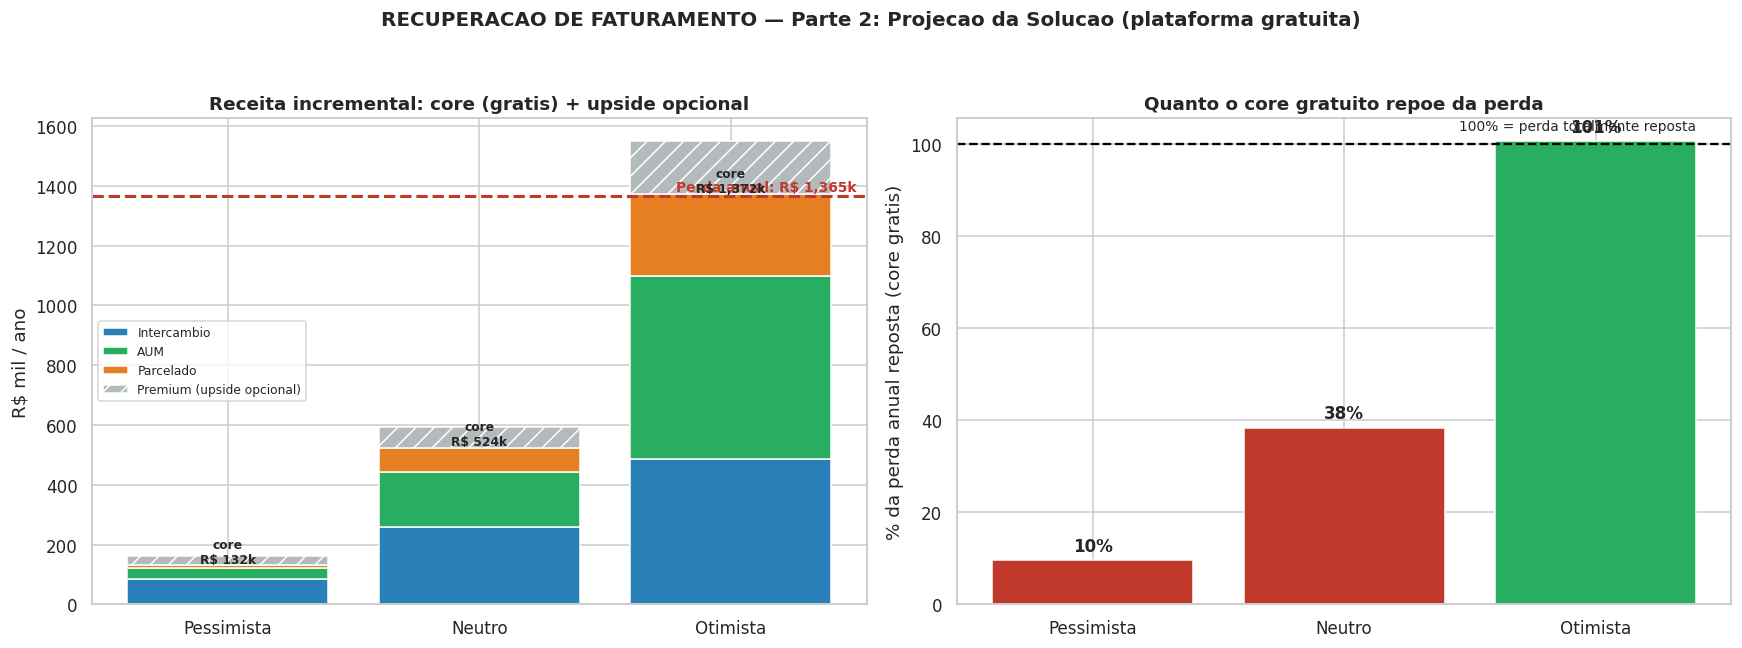

In [26]:
# ===== GRAFICO: projecao dos 3 cenarios (plataforma gratuita) =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RECUPERACAO DE FATURAMENTO — Parte 2: Projecao da Solucao (plataforma gratuita)', fontsize=13, fontweight='bold')

cenarios = list(proj.index)
comp = ['Intercambio','AUM','Parcelado']
cores_c = {'Intercambio':'#2980b9','AUM':'#27ae60','Parcelado':'#e67e22'}
x = np.arange(len(cenarios)); bottom = np.zeros(len(cenarios))
for cn in comp:
    vals = proj[cn].values/1e3
    axes[0].bar(x, vals, bottom=bottom, color=cores_c[cn], edgecolor='white', label=cn)
    bottom += vals
prem = proj['Premium_upside'].values/1e3
axes[0].bar(x, prem, bottom=bottom, color='#b2babb', edgecolor='white', hatch='//', label='Premium (upside opcional)')
axes[0].axhline(perda_total_ano/1e3, color='#c0392b', linestyle='--', linewidth=2)
axes[0].text(len(cenarios)-0.5, perda_total_ano/1e3+18, f'Perda anual: R$ {perda_total_ano/1e3:,.0f}k',
             color='#c0392b', ha='right', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(cenarios)
axes[0].set_ylabel('R$ mil / ano'); axes[0].set_title('Receita incremental: core (gratis) + upside opcional', fontweight='bold')
axes[0].legend(fontsize=8)
for xi, core in enumerate(proj['Core'].values/1e3):
    axes[0].text(xi, core+8, f'core\nR$ {core:,.0f}k', ha='center', fontsize=8, fontweight='bold')

repos = proj['Repos'].values*100
cores_r = ['#c0392b' if r<100 else '#27ae60' for r in repos]
b2 = axes[1].bar(cenarios, repos, color=cores_r, edgecolor='white')
axes[1].axhline(100, color='black', linestyle='--', linewidth=1.5)
axes[1].text(2.4, 103, '100% = perda totalmente reposta', ha='right', fontsize=9)
axes[1].set_ylabel('% da perda anual reposta (core gratis)'); axes[1].set_title('Quanto o core gratuito repoe da perda', fontweight='bold')
for b,r in zip(b2, repos):
    axes[1].text(b.get_x()+b.get_width()/2, r+2, f'{r:.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('docs/projecao_cenarios.png', dpi=130, bbox_inches='tight')
plt.show()

### 14.1 Sensibilidade e defesa das premissas

Em vez de defender um ponto único de adesão, mostramos **como o resultado responde à adesão** e ao spread — a conclusão (a solução traz receita nova relevante) é **robusta** em toda a faixa. Premissa do sweep: **captura do fluxo PIX→PJ = adesão** (quem está no app captura o próprio fluxo); demais alavancas fixas no neutro.

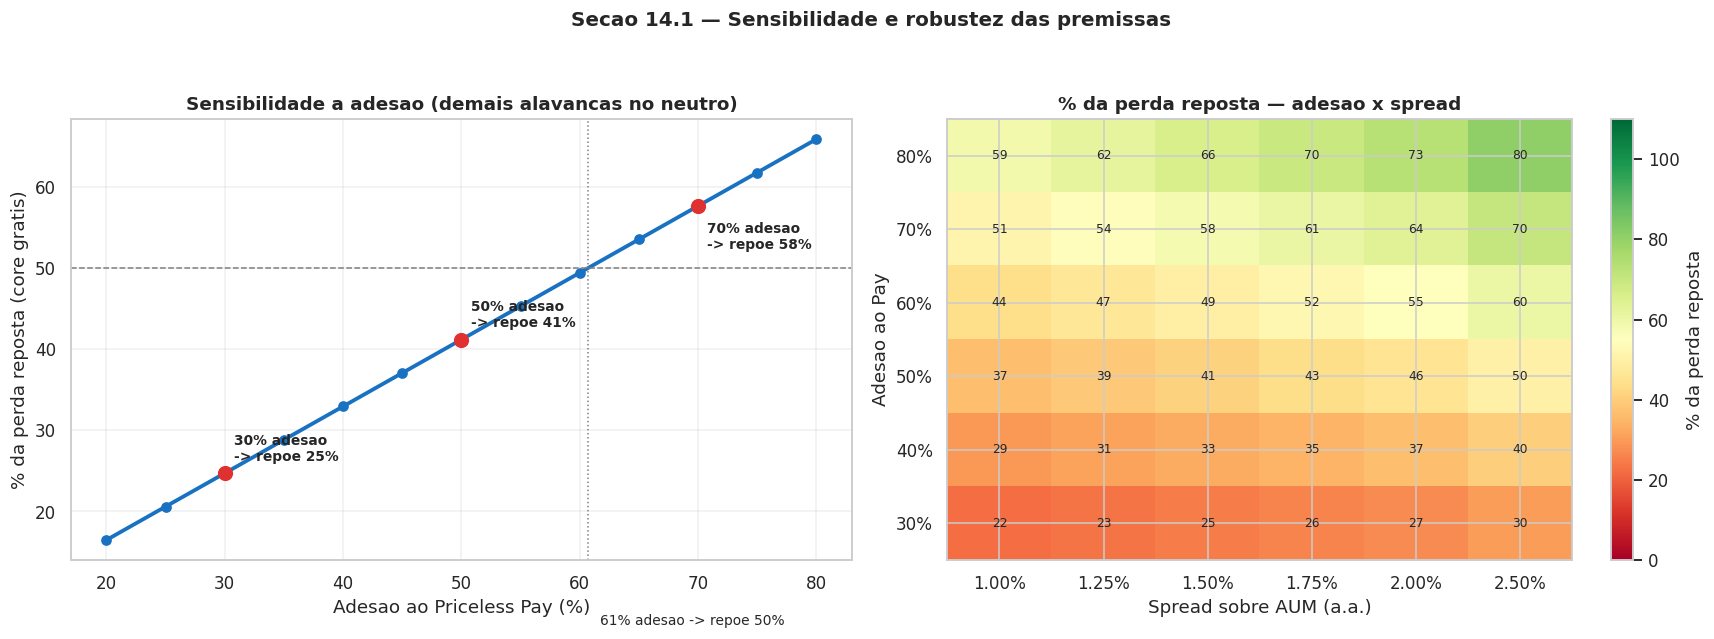

Adesao p/ repor 50% da perda (demais no neutro): ~61%
Reposicao @ adesao 30/50/70%: 25% / 41% / 58%


In [27]:
# ===== 14.1 SENSIBILIDADE (foco: ADESAO) =====
conv0, bal0, aumc0, spread0, ppen0, pmarg0 = 0.50, 18000, 0.70, 0.015, 0.10, 0.05

def core_por_adesao(a, spread=spread0):
    interc = PIXPJ_ANO * a * conv0 * IC_BLEND
    aum    = N * a * aumc0 * bal0 * spread
    parc   = (PIXPJ_ANO * a * conv0) * ppen0 * pmarg0
    return interc + aum + parc

ad = np.linspace(0.20, 0.80, 13)
repos = np.array([core_por_adesao(a)/perda_total_ano*100 for a in ad])
ad_fino = np.linspace(0.05, 1.0, 400)
rp_fino = np.array([core_por_adesao(a)/perda_total_ano*100 for a in ad_fino])
ad_50 = ad_fino[np.argmin(np.abs(rp_fino-50))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Secao 14.1 — Sensibilidade e robustez das premissas', fontsize=13, fontweight='bold')

axes[0].plot(ad*100, repos, color='#1971c2', linewidth=2.5, marker='o')
for a_ in [0.30, 0.50, 0.70]:
    y_ = core_por_adesao(a_)/perda_total_ano*100
    axes[0].scatter([a_*100],[y_], color='#e03131', s=80, zorder=5)
    axes[0].annotate(f'{a_*100:.0f}% adesao\n-> repoe {y_:.0f}%', (a_*100, y_),
                     textcoords='offset points', xytext=(6,-28 if a_==0.7 else 8), fontsize=9, fontweight='bold')
axes[0].axhline(50, color='gray', ls='--', lw=1); axes[0].axvline(ad_50*100, color='gray', ls=':', lw=1)
axes[0].text(ad_50*100+1, 6, f'{ad_50*100:.0f}% adesao -> repoe 50%', fontsize=9)
axes[0].set_xlabel('Adesao ao Priceless Pay (%)'); axes[0].set_ylabel('% da perda reposta (core gratis)')
axes[0].set_title('Sensibilidade a adesao (demais alavancas no neutro)', fontweight='bold'); axes[0].grid(alpha=0.3)

spreads = [0.010,0.0125,0.015,0.0175,0.020,0.025]
adsh    = [0.30,0.40,0.50,0.60,0.70,0.80]
M = np.array([[core_por_adesao(a, spread=s)/perda_total_ano*100 for s in spreads] for a in adsh])
im = axes[1].imshow(M, cmap='RdYlGn', aspect='auto', vmin=0, vmax=110, origin='lower')
axes[1].set_xticks(range(len(spreads))); axes[1].set_xticklabels([f'{s*100:.2f}%' for s in spreads])
axes[1].set_yticks(range(len(adsh)));    axes[1].set_yticklabels([f'{a*100:.0f}%' for a in adsh])
axes[1].set_xlabel('Spread sobre AUM (a.a.)'); axes[1].set_ylabel('Adesao ao Pay')
axes[1].set_title('% da perda reposta — adesao x spread', fontweight='bold')
for i in range(len(adsh)):
    for j in range(len(spreads)):
        axes[1].text(j, i, f'{M[i,j]:.0f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[1], label='% da perda reposta')

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('docs/sensibilidade.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Adesao p/ repor 50% da perda (demais no neutro): ~{ad_50*100:.0f}%')
print(f'Reposicao @ adesao 30/50/70%: {core_por_adesao(0.3)/perda_total_ano*100:.0f}% / {core_por_adesao(0.5)/perda_total_ano*100:.0f}% / {core_por_adesao(0.7)/perda_total_ano*100:.0f}%')

### 14.2 Adesão × Faturamento e Adesão × Spread (em R$)

As mesmas relações da 14.1, agora em **faturamento absoluto (R$/ano)** em vez de % da perda. À esquerda, o faturamento-core decomposto por fonte conforme a adesão; à direita, como o **spread** desloca a curva de faturamento. Linha tracejada vermelha = perda anual (R$ 1,49M) a ser reposta.

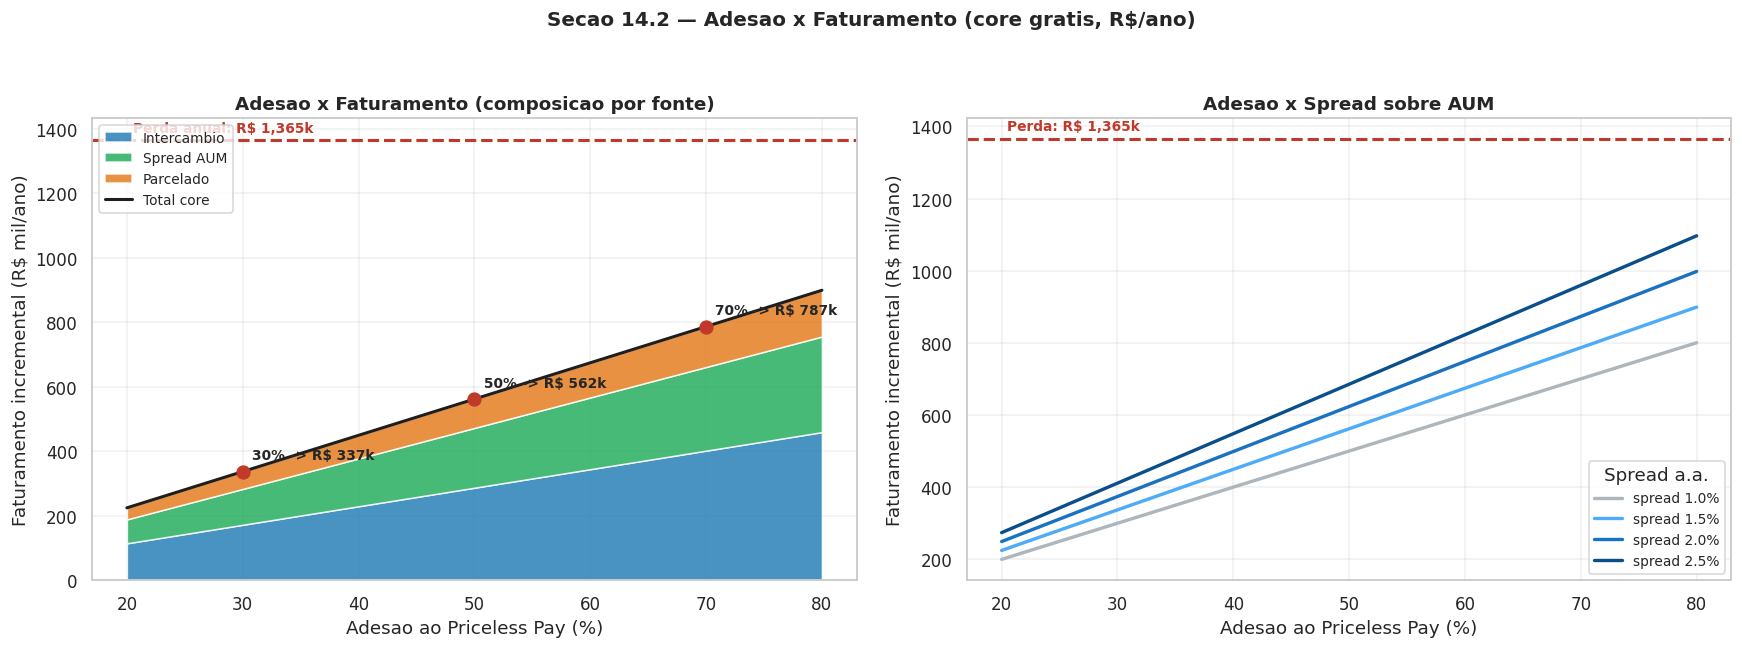

Faturamento-core (R$/ano) por adesao [spread neutro 1,5%]:
  adesao 30%: R$ 337,190
  adesao 50%: R$ 561,983
  adesao 70%: R$ 786,777

Faturamento (R$/ano) @ adesao 50% por spread:
  spread 1.0%: R$ 500,243
  spread 1.5%: R$ 561,983
  spread 2.0%: R$ 623,723
  spread 2.5%: R$ 685,463


In [28]:
# ===== 14.2 ADESAO x FATURAMENTO  e  ADESAO x SPREAD (R$) =====
a_grid = np.linspace(0.20, 0.80, 25)
interc = PIXPJ_ANO * a_grid * conv0 * IC_BLEND
aum    = N * a_grid * aumc0 * bal0 * spread0
parc   = PIXPJ_ANO * a_grid * conv0 * ppen0 * pmarg0
total  = interc + aum + parc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Secao 14.2 — Adesao x Faturamento (core gratis, R$/ano)', fontsize=13, fontweight='bold')

# P1: adesao x faturamento (composicao empilhada)
axes[0].stackplot(a_grid*100, interc/1e3, aum/1e3, parc/1e3,
                  labels=['Intercambio','Spread AUM','Parcelado'],
                  colors=['#2980b9','#27ae60','#e67e22'], alpha=0.85)
axes[0].plot(a_grid*100, total/1e3, color='#1e1e1e', lw=2, label='Total core')
axes[0].axhline(perda_total_ano/1e3, color='#c0392b', ls='--', lw=2)
axes[0].text(20.5, perda_total_ano/1e3+25, f'Perda anual: R$ {perda_total_ano/1e3:,.0f}k', color='#c0392b', fontsize=9, fontweight='bold')
for a_ in [0.30,0.50,0.70]:
    yt=(PIXPJ_ANO*a_*conv0*IC_BLEND + N*a_*aumc0*bal0*spread0 + PIXPJ_ANO*a_*conv0*ppen0*pmarg0)/1e3
    axes[0].scatter([a_*100],[yt], color='#c0392b', s=70, zorder=6)
    axes[0].annotate(f'{a_*100:.0f}% -> R$ {yt:,.0f}k', (a_*100, yt), textcoords='offset points', xytext=(6,8), fontsize=9, fontweight='bold')
axes[0].set_xlabel('Adesao ao Priceless Pay (%)'); axes[0].set_ylabel('Faturamento incremental (R$ mil/ano)')
axes[0].set_title('Adesao x Faturamento (composicao por fonte)', fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9); axes[0].grid(alpha=0.3)

# P2: adesao x spread (familia de curvas em R$)
for s, cor in zip([0.010,0.015,0.020,0.025], ['#adb5bd','#4dabf7','#1971c2','#0b4f8a']):
    fat = (PIXPJ_ANO*a_grid*conv0*IC_BLEND + N*a_grid*aumc0*bal0*s + PIXPJ_ANO*a_grid*conv0*ppen0*pmarg0)/1e3
    axes[1].plot(a_grid*100, fat, color=cor, lw=2.2, label=f'spread {s*100:.1f}%')
axes[1].axhline(perda_total_ano/1e3, color='#c0392b', ls='--', lw=2)
axes[1].text(20.5, perda_total_ano/1e3+25, f'Perda: R$ {perda_total_ano/1e3:,.0f}k', color='#c0392b', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Adesao ao Priceless Pay (%)'); axes[1].set_ylabel('Faturamento incremental (R$ mil/ano)')
axes[1].set_title('Adesao x Spread sobre AUM', fontweight='bold')
axes[1].legend(title='Spread a.a.', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('docs/adesao_faturamento.png', dpi=130, bbox_inches='tight')
plt.show()

print('Faturamento-core (R$/ano) por adesao [spread neutro 1,5%]:')
for a_ in [0.30,0.50,0.70]:
    yt = PIXPJ_ANO*a_*conv0*IC_BLEND + N*a_*aumc0*bal0*spread0 + PIXPJ_ANO*a_*conv0*ppen0*pmarg0
    print(f'  adesao {a_*100:.0f}%: R$ {yt:,.0f}')
print('\nFaturamento (R$/ano) @ adesao 50% por spread:')
for s in [0.010,0.015,0.020,0.025]:
    yt = PIXPJ_ANO*0.5*conv0*IC_BLEND + N*0.5*aumc0*bal0*s + PIXPJ_ANO*0.5*conv0*ppen0*pmarg0
    print(f'  spread {s*100:.1f}%: R$ {yt:,.0f}')

## 15. O Ecossistema — Projeção das 3 Frentes

As três soluções do grupo formam um passo a passo aditivo (pools distintos, sem dupla contagem):
1. **FATURAR → Motor (Priceless Pay)** — recupera o faturamento perdido (Seção 14). *Defensivo.*
2. **EXPANDIR LEQUE → Cartões Digitais** — cresce o cartão onde o PIX não entra (online/CNP, recorrência, internacional, wallet). *Consolidação.*
3. **CAPTAR NOVA BASE → PIX no Crédito + ataque à LuminaPay** — adquire base jovem 18-30. *Crescimento.*

Premissas novas ancoradas: CNP/online ≈ R$11M/ano (cartao-digital.md B.2); contas novas 5k→50k (proposta_priceless_bank.md, KPIs).

In [29]:
# ===== 15. PROJECAO DO ECOSSISTEMA (3 frentes) =====
# Motor (Parte 1): reaproveita o 'Core' da Secao 14
motor = {c: proj.loc[c,'Core'] for c in ['Pessimista','Neutro','Otimista']}

# Parte 2 — Cartao Digital: intercambio incremental sobre o volume CNP/online (pool PIX-proof, distinto do Motor)
CNP_BASE = 11_000_000        # volume online/CNP anual (dado interno)
IC_CNP   = 0.018             # conservador (= credito; premio CNP/internacional fica como upside)
cresc_cnp = {'Pessimista':0.20, 'Neutro':0.45, 'Otimista':0.80}   # crescimento do volume digital
p2 = {c: CNP_BASE*g*IC_CNP for c,g in cresc_cnp.items()}

# Parte 3 — PIX no Credito + base jovem: aquisicao de novos clientes 18-30
contas = {'Pessimista':5_000,  'Neutro':20_000, 'Otimista':50_000}   # contas novas em 12m (KPI do doc)
gasto  = {'Pessimista':4_000,  'Neutro':6_000,  'Otimista':9_000}    # gasto anual monetizado/cliente jovem
take   = {'Pessimista':0.020,  'Neutro':0.025,  'Otimista':0.030}    # intercambio + margem liq. de juros - risco
p3 = {c: contas[c]*gasto[c]*take[c] for c in contas}

eco = {}
for c in ['Pessimista','Neutro','Otimista']:
    eco[c] = dict(Motor=motor[c], CartaoDigital=p2[c], PIXCredito=p3[c],
                  Total=motor[c]+p2[c]+p3[c])
eco = pd.DataFrame(eco).T
eco['%_perda'] = eco['Total']/perda_total_ano*100

print('PROJECAO DO ECOSSISTEMA — receita incremental anual (R$):\n')
for c in eco.index:
    r=eco.loc[c]
    print(f'[{c}]')
    print(f'  1) Motor (Priceless Pay)      : R$ {r.Motor:>12,.0f}')
    print(f'  2) Cartoes Digitais           : R$ {r.CartaoDigital:>12,.0f}')
    print(f'  3) PIX Credito + base jovem   : R$ {r.PIXCredito:>12,.0f}')
    print(f'     ------------------------------------------')
    print(f'     TOTAL ECOSSISTEMA          : R$ {r.Total:>12,.0f}/ano  =  {r["%_perda"]:.0f}% da perda (R$ {perda_total_ano:,.0f})')
    print()

PROJECAO DO ECOSSISTEMA — receita incremental anual (R$):

[Pessimista]
  1) Motor (Priceless Pay)      : R$      132,186
  2) Cartoes Digitais           : R$       39,600
  3) PIX Credito + base jovem   : R$      400,000
     ------------------------------------------
     TOTAL ECOSSISTEMA          : R$      571,786/ano  =  42% da perda (R$ 1,364,510)

[Neutro]
  1) Motor (Priceless Pay)      : R$      524,307
  2) Cartoes Digitais           : R$       89,100
  3) PIX Credito + base jovem   : R$    3,000,000
     ------------------------------------------
     TOTAL ECOSSISTEMA          : R$    3,613,407/ano  =  265% da perda (R$ 1,364,510)

[Otimista]
  1) Motor (Priceless Pay)      : R$    1,372,485
  2) Cartoes Digitais           : R$      158,400
  3) PIX Credito + base jovem   : R$   13,500,000
     ------------------------------------------
     TOTAL ECOSSISTEMA          : R$   15,030,885/ano  =  1102% da perda (R$ 1,364,510)



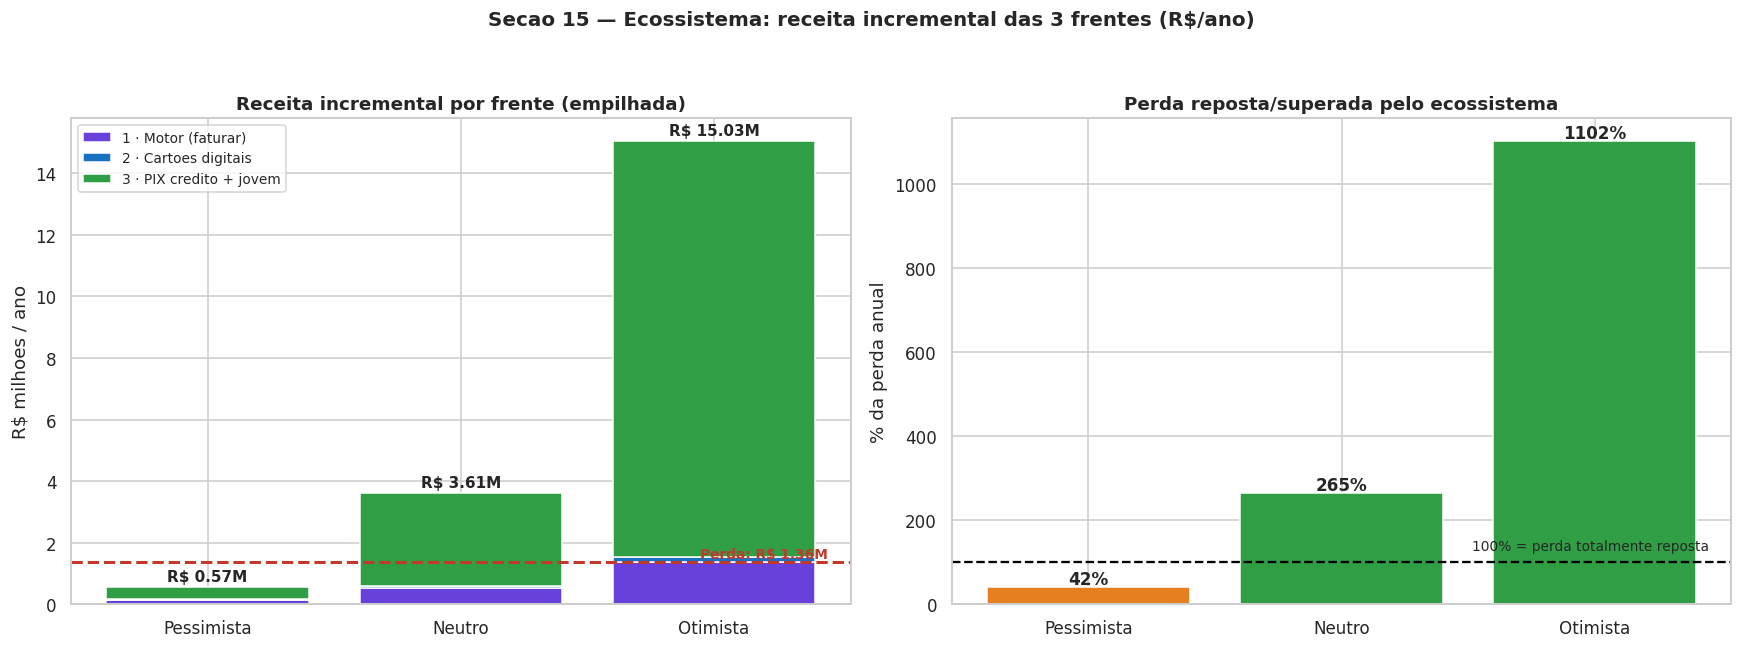

In [30]:
# ===== GRAFICO: ecossistema (3 frentes empilhadas) =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Secao 15 — Ecossistema: receita incremental das 3 frentes (R$/ano)', fontsize=13, fontweight='bold')

cen=list(eco.index); x=np.arange(len(cen)); bottom=np.zeros(len(cen))
camadas=[('Motor','#6741d9'),('CartaoDigital','#1971c2'),('PIXCredito','#2f9e44')]
rotulos={'Motor':'1 · Motor (faturar)','CartaoDigital':'2 · Cartoes digitais','PIXCredito':'3 · PIX credito + jovem'}
for col,cor in camadas:
    v=eco[col].values/1e6
    axes[0].bar(x, v, bottom=bottom, color=cor, edgecolor='white', label=rotulos[col])
    bottom+=v
axes[0].axhline(perda_total_ano/1e6, color='#c0392b', ls='--', lw=2)
axes[0].text(2.45, perda_total_ano/1e6+0.15, f'Perda: R$ {perda_total_ano/1e6:.2f}M', color='#c0392b', ha='right', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(cen)
axes[0].set_ylabel('R$ milhoes / ano'); axes[0].set_title('Receita incremental por frente (empilhada)', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')
for xi,t in enumerate(eco['Total'].values/1e6):
    axes[0].text(xi, t+0.2, f'R$ {t:.2f}M', ha='center', fontsize=10, fontweight='bold')

# P2: % da perda reposta/superada
rp=eco['%_perda'].values
cores=['#e67e22' if v<100 else '#2f9e44' for v in rp]
b=axes[1].bar(cen, rp, color=cores, edgecolor='white')
axes[1].axhline(100, color='black', ls='--', lw=1.5)
axes[1].text(2.45, 130, '100% = perda totalmente reposta', ha='right', fontsize=9)
axes[1].set_ylabel('% da perda anual'); axes[1].set_title('Perda reposta/superada pelo ecossistema', fontweight='bold')
for bi,v in zip(b,rp): axes[1].text(bi.get_x()+bi.get_width()/2, v+8, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('docs/projecao_ecossistema.png', dpi=130, bbox_inches='tight')
plt.show()